In [ ]:
# [CELL 0]
# LastWave-style plotting utilities — now imported from wtmm package
from wtmm.colormaps import lastwave_colormap, lastwave_grey_colormap, lastwave_b2r_colormap, scalogram_lastwave

print("LastWave plotting utilities loaded (from wtmm.colormaps):")
print("  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'")
print("  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)")
print(f"              norm_mode='lglobal' (default) | 'global' | 'signedglobal'")
print(f"  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)")


LastWave plotting utilities loaded:
  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'
  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)
              norm_mode='lglobal' (default) | 'global' | 'signedglobal'
  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)


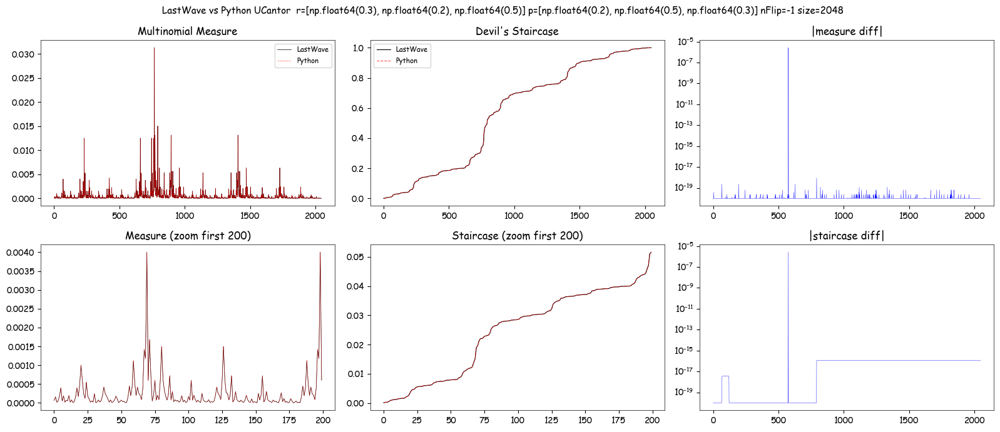

Max |measure diff|:   2.59e-06
Max |staircase diff|: 2.59e-06
Staircase range LW:   [0.000064, 1.000000]
Staircase range Py:   [0.000064, 1.000000]


In [ ]:
# [CELL 1] LastWave ground truth — Step 1: Inhomogeneous devil's staircase (LastWave vs Python)
import ctypes, ctypes.util, numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Force reload the dylib (kernel may cache old version)
_lw_path = './liblastwave_wrapper.dylib'
try:
    ctypes.cdll.LoadLibrary(_lw_path)
except:
    pass
lib = ctypes.CDLL(_lw_path)

lib.lw_init.restype = ctypes.c_int
lib.lw_ucantor.restype = ctypes.c_int
lib.lw_ucantor.argtypes = [ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.c_int, ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double)]
lib.lw_cleanup.restype = None
lib.lw_get_error.restype = ctypes.c_char_p
lib.lw_eval_wavelet.restype = ctypes.c_int
lib.lw_get_wavelet_domain.restype = ctypes.c_int

c_double_p = ctypes.POINTER(ctypes.c_double)

ret = lib.lw_init()
assert ret == 0, f"lw_init failed: {lib.lw_get_error()}"

# ── DemoWTMM1DDevilStair parameters ──
SIZE = 2048
r = np.array([0.3, 0.2, 0.5], dtype=np.float64)
p = np.array([0.2, 0.5, 0.3], dtype=np.float64)
nFlip = -1  # no flip (matches C_UCantor doing nFlip-- from 0)

# ── LastWave UCantor ──
lw_measure = np.zeros(SIZE, dtype=np.float64)
ret = lib.lw_ucantor(SIZE, r.ctypes.data_as(c_double_p),
                      p.ctypes.data_as(c_double_p), 3, nFlip,
                      lw_measure.ctypes.data_as(c_double_p))
assert ret == 0, f"lw_ucantor failed: {lib.lw_get_error()}"
lw_staircase = np.cumsum(lw_measure)

# ── Python UCantor (matches LastWave's C arithmetic exactly) ──
def ucantor(size, r, p, nFlip=-1):
    dx = 1.0 / size
    signal = np.zeros(size)
    r = list(r)
    p = list(p)
    n = len(r)
    # Iterative DFS matching C's recursive UCantor exactly:
    #   l accumulates across siblings: l += (right-left)*r[i]
    #   ISig: (int)(left / dx)    (since x0=0)
    #   termination: fabs(right-left) <= dx
    stack = [(0.0, 1.0, 1.0)]  # (left, right, proba)
    while stack:
        left, right, proba = stack.pop()
        if abs(right - left) <= dx:
            i = int(left / dx)
            if i < 0: i = 0
            elif i >= size: i = size - 1
            signal[i] += proba
            continue
        # Accumulate l across siblings, matching C
        span = right - left
        l = left
        for i in range(n):
            child_proba = proba * p[i]
            if i == nFlip:
                stack.append((l + span * r[i], l, child_proba))
            else:
                stack.append((l, l + span * r[i], child_proba))
            l += span * r[i]
    return signal

py_measure = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)
py_staircase = np.cumsum(py_measure)

# ── Compare ──
measure_diff = np.abs(lw_measure - py_measure)
stair_diff = np.abs(lw_staircase - py_staircase)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

axes[0, 0].plot(lw_measure, 'k-', lw=0.5, label='LastWave')
axes[0, 0].plot(py_measure, 'r--', lw=0.5, alpha=0.7, label='Python')
axes[0, 0].set_title('Multinomial Measure')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(lw_staircase, 'k-', lw=0.8, label='LastWave')
axes[0, 1].plot(py_staircase, 'r--', lw=0.8, alpha=0.7, label='Python')
axes[0, 1].set_title("Devil's Staircase")
axes[0, 1].legend(fontsize=8)

axes[0, 2].semilogy(measure_diff + 1e-20, 'b-', lw=0.3)
axes[0, 2].set_title('|measure diff|')

axes[1, 0].plot(lw_measure[:200], 'k-', lw=0.5)
axes[1, 0].plot(py_measure[:200], 'r--', lw=0.5, alpha=0.7)
axes[1, 0].set_title('Measure (zoom first 200)')

axes[1, 1].plot(lw_staircase[:200], 'k-', lw=0.8)
axes[1, 1].plot(py_staircase[:200], 'r--', lw=0.8, alpha=0.7)
axes[1, 1].set_title('Staircase (zoom first 200)')

axes[1, 2].semilogy(stair_diff + 1e-20, 'b-', lw=0.3)
axes[1, 2].set_title('|staircase diff|')

plt.suptitle(f'LastWave vs Python UCantor  r={list(r)} p={list(p)} nFlip={nFlip} size={SIZE}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Max |measure diff|:   {measure_diff.max():.2e}')
print(f'Max |staircase diff|: {stair_diff.max():.2e}')
print(f'Staircase range LW:   [{lw_staircase.min():.6f}, {lw_staircase.max():.6f}]')
print(f'Staircase range Py:   [{py_staircase.min():.6f}, {py_staircase.max():.6f}]')

Start octave 1.........
Start octave 2.........
Start octave 3.........
Start octave 4.........
Start octave 5.........


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_32774/595811681.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()


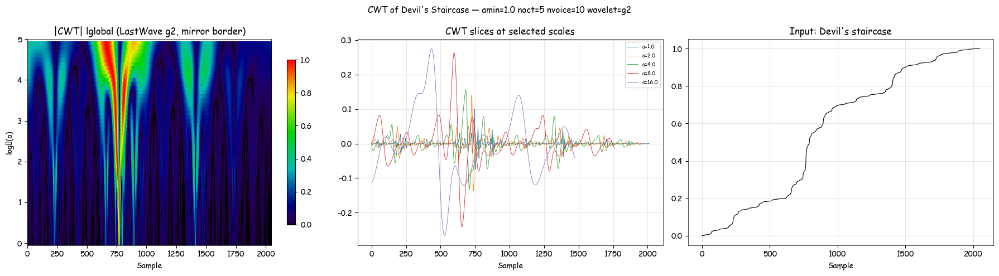

Scales: 50 total, range [1.00, 29.86]
  scale  0 (a=   1.00): valid range [18, 2029]
  scale 10 (a=   2.00): valid range [35, 2012]
  scale 20 (a=   4.00): valid range [71, 1976]
  scale 30 (a=   8.00): valid range [143, 1904]
  scale 40 (a=  16.00): valid range [287, 1760]


In [ ]:
# [CELL 2]
# LastWave ground truth — Step 2: CWT of inhomogeneous Cantor measure via LastWave
#
# DemoWTMM1DDevilStair params: amin=1.0, omax=5, nvoice=10, wavelet='g2', border='mir'
# The input is the devil's staircase (integrated measure) from cell 0.

# ── CWT setup ──
lib.lw_cwtd.restype = ctypes.c_int
lib.lw_cwtd.argtypes = [
    ctypes.POINTER(ctypes.c_double),  # signal_in
    ctypes.c_int,                      # size
    ctypes.c_double,                   # a_min
    ctypes.c_int,                      # n_oct
    ctypes.c_int,                      # n_voice
    ctypes.c_char_p,                   # wavelet_name
    ctypes.c_double,                   # expo
    ctypes.c_int,                      # border_type
    ctypes.POINTER(ctypes.c_double),   # coeffs_out
    ctypes.POINTER(ctypes.c_int),      # firstp_out
    ctypes.POINTER(ctypes.c_int),      # lastp_out
]

a_min   = 1.0
n_oct   = 5
n_voice = 10
wavelet = b'g2'
expo    = -1.0
border  = 1       # CV_MIRROR (enum: CV_PERIODIC=0, CV_MIRROR=1, CV_PADDING=2, CV_0_PADDING=3)

n_scales = n_oct * n_voice
coeffs  = np.zeros(n_scales * SIZE, dtype=np.float64)
firstp  = np.zeros(n_scales, dtype=np.int32)
lastp   = np.zeros(n_scales, dtype=np.int32)

# CWT of the devil's staircase (= cumsum of measure), matching the demo's "0w = prim(0w)"
ret = lib.lw_cwtd(
    lw_staircase.ctypes.data_as(c_double_p), SIZE,
    ctypes.c_double(a_min), n_oct, n_voice,
    wavelet, ctypes.c_double(expo), border,
    coeffs.ctypes.data_as(c_double_p),
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
assert ret == 0, f"lw_cwtd failed: {lib.lw_get_error()}"

cwt = coeffs.reshape(n_scales, SIZE)

# ── Scale axis ──
factor = 2.0 ** (1.0 / n_voice)
scales = a_min * factor ** np.arange(n_scales)
log2_scales = np.log2(scales)

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Scalogram (LastWave lglobal normalization — per-scale-line, no log)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('|CWT| lglobal (LastWave g2, mirror border)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# CWT at a few selected scales
sel = [0, n_voice, 2*n_voice, 3*n_voice, 4*n_voice]
for s in sel:
    fp, lp = firstp[s], lastp[s]
    axes[1].plot(cwt[s, fp:lp+1], lw=0.6, label=f'a={scales[s]:.1f}')
axes[1].set_title('CWT slices at selected scales')
axes[1].set_xlabel('Sample')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Devil's staircase for reference
axes[2].plot(lw_staircase, 'k-', lw=0.8)
axes[2].set_title("Input: Devil's staircase")
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"CWT of Devil's Staircase — amin={a_min} noct={n_oct} nvoice={n_voice} wavelet=g2", fontsize=11)
plt.tight_layout()
plt.show()

# ── Valid range info ──
print(f'Scales: {n_scales} total, range [{scales[0]:.2f}, {scales[-1]:.2f}]')
for s in sel:
    print(f'  scale {s:2d} (a={scales[s]:7.2f}): valid range [{firstp[s]}, {lastp[s]}]')

Total extrema found: 3645
Extracted 3645 extrema across 50 scales


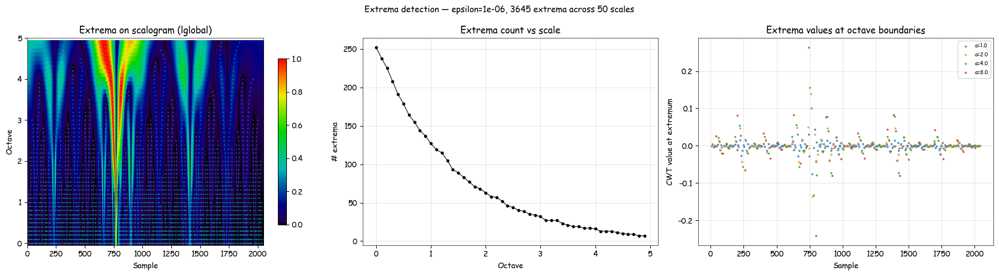


   Scale   Octave  # ext
--------------------------
    1.00    0.000    252
    2.00    1.000    127
    4.00    2.000     63
    8.00    3.000     32
   16.00    4.000     16


In [ ]:
# [CELL 3]
# LastWave ground truth — Step 3: Extrema detection on CWT
#
# DemoWTMM1DDevilStair does:
#   extrema w          (default epsilon=1e-6, interpolated)
#   chainmax w.extrep 1
#
# lw_compute_extrema runs ComputeExtrep on the global wtrans from the previous CWT.
# Then we extract extrema positions & values at each scale for visualization.

# ── Declare function signatures ──
lib.lw_compute_extrema.restype = ctypes.c_int
lib.lw_compute_extrema.argtypes = [ctypes.c_double]

lib.lw_get_extrema_count.restype = ctypes.c_int
lib.lw_get_extrema_count.argtypes = [ctypes.c_int, ctypes.c_int]

lib.lw_get_extrema_at_scale.restype = ctypes.c_int
lib.lw_get_extrema_at_scale.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.c_int,
]

lib.lw_get_n_oct.restype = ctypes.c_int
lib.lw_get_n_voice.restype = ctypes.c_int

# ── Compute extrema ──
epsilon = 1e-6  # LastWave default
nb_ext = lib.lw_compute_extrema(ctypes.c_double(epsilon))
assert nb_ext >= 0, f"lw_compute_extrema failed: {lib.lw_get_error()}"
print(f"Total extrema found: {nb_ext}")

# ── Extract extrema at every scale ──
ext_data = {}  # (octave, voice) -> (positions, values)
total = 0
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        count = lib.lw_get_extrema_count(o, v)
        if count <= 0:
            continue
        pos = np.zeros(count, dtype=np.float64)
        val = np.zeros(count, dtype=np.float64)
        got = lib.lw_get_extrema_at_scale(
            o, v,
            pos.ctypes.data_as(c_double_p),
            val.ctypes.data_as(c_double_p),
            count,
        )
        ext_data[(o, v)] = (pos[:got], val[:got])
        total += got

print(f"Extracted {total} extrema across {len(ext_data)} scales")

# ── Plot: extrema overlaid on scalogram ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel 1: scalogram with extrema scatter (LastWave lglobal)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
# Overlay extrema
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    log2_a = log2_scales[scale_idx]
    axes[0].scatter(pos, np.full_like(pos, log2_a), s=0.3, c='cyan', alpha=0.5)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Octave')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('Extrema on scalogram (lglobal)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Panel 2: extrema count vs scale
ext_counts = np.zeros(n_scales, dtype=int)
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    ext_counts[scale_idx] = len(pos)
axes[1].plot(log2_scales, ext_counts, 'k.-', lw=0.8)
axes[1].set_xlabel('Octave')
axes[1].set_ylabel('# extrema')
axes[1].set_title('Extrema count vs scale')
axes[1].grid(True, alpha=0.3)

# Panel 3: extrema at a few selected scales
sel_scales = [(1, 0), (2, 0), (3, 0), (4, 0)]
for (o, v) in sel_scales:
    if (o, v) in ext_data:
        pos, val = ext_data[(o, v)]
        scale_idx = (o - 1) * n_voice + v
        axes[2].scatter(pos, val, s=3, label=f'a={scales[scale_idx]:.1f}', alpha=0.7)
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('CWT value at extremum')
axes[2].set_title('Extrema values at octave boundaries')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Extrema detection — epsilon={epsilon}, {total} extrema across {n_scales} scales', fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table ──
print(f"\n{'Scale':>8} {'Octave':>8} {'# ext':>6}")
print('-' * 26)
for s in range(0, n_scales, n_voice):
    o = s // n_voice + 1
    v = s % n_voice
    c = ext_counts[s]
    print(f'{scales[s]:8.2f} {log2_scales[s]:8.3f} {c:6d}')

ChainDelete removed 0 unchained extrema
Chains remaining: 252
Extracted 252 chains, lengths: min=1, max=50, median=11


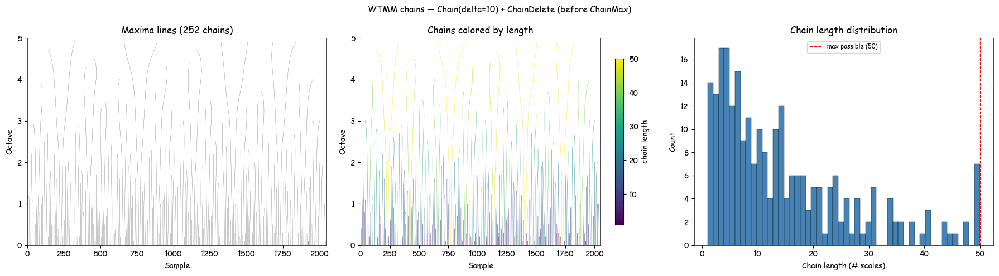

In [ ]:
# [CELL 4]
# LastWave ground truth — Step 3: Chain + ChainDelete + plot maxima lines
#
# Chain() builds linked lists via coarser/finer pointers.
# ChainDelete() prunes extrema not part of any chain.
# ChainMax is deferred to a later cell so we can compare before/after.

# ── Declare signatures ──
lib.lw_chain.restype = ctypes.c_int
lib.lw_chain.argtypes = [ctypes.c_double]

lib.lw_chain_delete.restype = ctypes.c_int
lib.lw_chain_delete.argtypes = []

lib.lw_chain_max.restype = ctypes.c_int
lib.lw_chain_max.argtypes = [ctypes.c_double]

lib.lw_get_num_chains.restype = ctypes.c_int
lib.lw_get_num_chains.argtypes = []

lib.lw_get_chain.restype = ctypes.c_int
lib.lw_get_chain.argtypes = [
    ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int), ctypes.c_int,
]

def extract_chains():
    """Extract all chains from the current extrep."""
    nc = lib.lw_get_num_chains()
    max_len = n_scales + 1
    result = []
    for ci in range(nc):
        abs_buf = np.zeros(max_len, dtype=np.float64)
        ord_buf = np.zeros(max_len, dtype=np.float64)
        scl_buf = np.zeros(max_len, dtype=np.int32)
        length = lib.lw_get_chain(
            ci,
            abs_buf.ctypes.data_as(c_double_p),
            ord_buf.ctypes.data_as(c_double_p),
            scl_buf.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
            max_len,
        )
        if length > 0:
            result.append({
                'x': abs_buf[:length].copy(),
                'val': ord_buf[:length].copy(),
                'scale_idx': scl_buf[:length].copy(),
                'log2_a': np.log2(a_min) + scl_buf[:length] / n_voice,
            })
    return result

# ── Build chains ──
ret = lib.lw_chain(ctypes.c_double(10.0))   # delta=10 (default)
assert ret == 0, f"lw_chain failed: {lib.lw_get_error()}"

deleted = lib.lw_chain_delete()
print(f"ChainDelete removed {deleted} unchained extrema")

n_chains = lib.lw_get_num_chains()
print(f"Chains remaining: {n_chains}")

# ── Extract BEFORE chainmax ──
chains = extract_chains()

print(f"Extracted {len(chains)} chains, lengths: min={min(len(c['x']) for c in chains)}, "
      f"max={max(len(c['x']) for c in chains)}, "
      f"median={np.median([len(c['x']) for c in chains]):.0f}")

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes[:2]:
    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, n_oct)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Octave')
    ax.set_yticks(range(0, n_oct + 1))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

for ch in chains:
    axes[0].plot(ch['x'], ch['log2_a'], 'k-', lw=0.3, alpha=0.5)
axes[0].set_title(f'Maxima lines ({len(chains)} chains)')

lengths = np.array([len(c['x']) for c in chains])
norm = plt.Normalize(lengths.min(), lengths.max())
cmap = plt.cm.viridis
for ch in chains:
    color = cmap(norm(len(ch['x'])))
    axes[1].plot(ch['x'], ch['log2_a'], '-', color=color, lw=0.5, alpha=0.7)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=axes[1], label='chain length', shrink=0.8)
axes[1].set_title('Chains colored by length')

axes[2].hist(lengths, bins=50, color='steelblue', edgecolor='k', lw=0.3)
axes[2].set_xlabel('Chain length (# scales)')
axes[2].set_ylabel('Count')
axes[2].set_title('Chain length distribution')
axes[2].axvline(n_scales, color='r', ls='--', lw=1, label=f'max possible ({n_scales})')
axes[2].legend(fontsize=8)

plt.suptitle(f"WTMM chains — Chain(delta=10) + ChainDelete (before ChainMax)", fontsize=11)
plt.tight_layout()
plt.show()

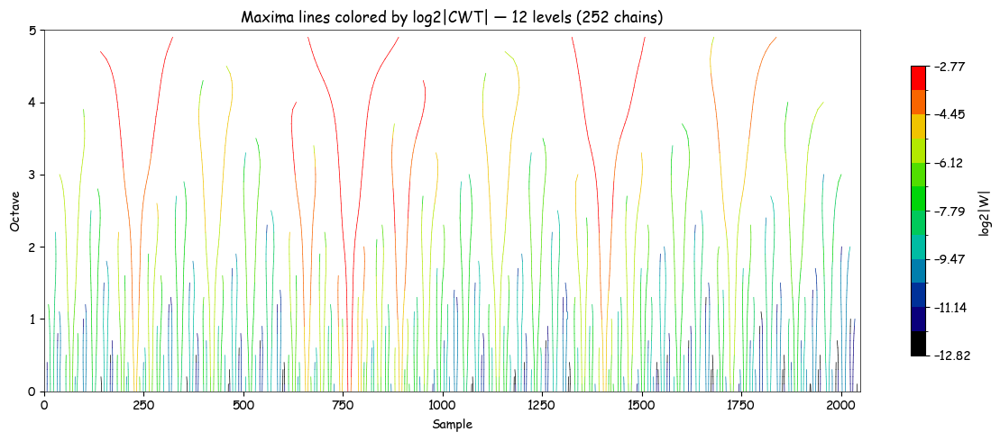

In [ ]:
# [CELL 5]
# Chains colored by log2|ordinate| (lastwave colormap, discretized)
N_COLORS = 12  # ← change this to set number of discrete color bins

fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains])
vmin, vmax = np.percentile(all_log2_vals, [2, 98])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W|', shrink=0.8)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines colored by log2|CWT| — {N_COLORS} levels ({len(chains)} chains)')
plt.tight_layout(); plt.show()

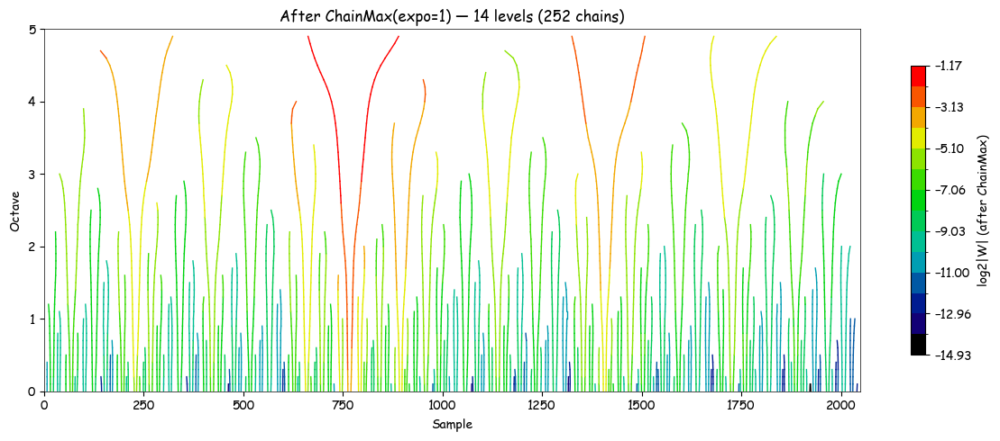

In [ ]:
# [CELL 6]
# Chains after ChainMax(expo=1) — colored by log2|ordinate| (lastwave colormap)
# ChainMax replaces each ordinate with the scale-adaptive max along the chain.
# Compare with cell 4 to see the difference.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14

ret = lib.lw_chain_max(ctypes.c_double(1.0))
assert ret == 0, f"lw_chain_max failed: {lib.lw_get_error()}"

chains_cm = extract_chains()

fig, ax = plt.subplots(figsize=(12, 5))
all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains_cm])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains_cm:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W| (after ChainMax)', shrink=0.8)

# Tight margins: bottom and sides flush, keep top gap
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — {N_COLORS} levels ({len(chains_cm)} chains)')

# Thin frames
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'  # reset after

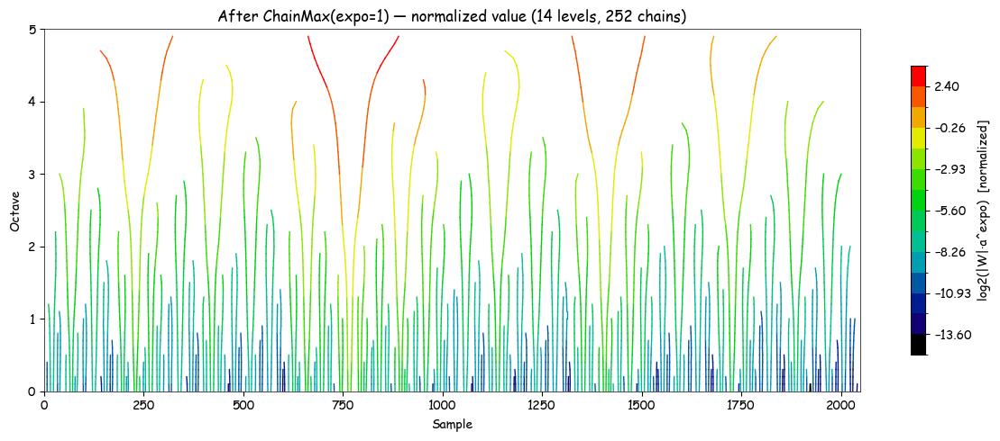

In [ ]:
# [CELL 7]
# Chains after ChainMax(expo=1) — colored by NORMALIZED value log2(|W|·a^expo)
# ChainMax guarantees monotonicity of the normalized value |W|·a^expo along each chain
# (non-increasing from fine→coarse). If ChainMax worked, each chain should appear
# as a single color or transition smoothly from warm (fine) to cool (coarse).

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14
expo = 1.0

fig, ax = plt.subplots(figsize=(12, 5))

# Compute normalized values: |ordinate| * a^expo = |ordinate| * a_min * 2^(expo * scale_idx / n_voice)
all_norm_vals = []
for ch in chains_cm:
    norm_val = np.log2(np.abs(ch['val']) + 1e-300) + expo * ch['scale_idx'] / n_voice + np.log2(a_min)
    all_norm_vals.append(norm_val)

all_norm_concat = np.concatenate(all_norm_vals)
vmin, vmax = np.percentile(all_norm_concat, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

for ch, nv in zip(chains_cm, all_norm_vals):
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(nv[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2(|W|·a^expo)  [normalized]', shrink=0.8)

ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — normalized value ({N_COLORS} levels, {len(chains_cm)} chains)')

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

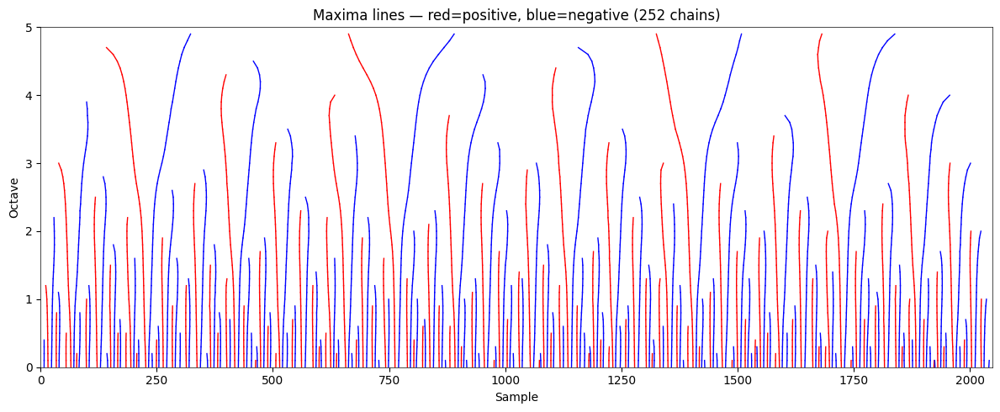

In [ ]:
# [CELL 8]
# Chains colored by sign: positive (red) / negative (blue)
fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
for ch in chains:
    sign = np.sign(ch['val'])
    for j in range(len(ch['x']) - 1):
        c = 'red' if sign[j] > 0 else 'blue'
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=c, lw=1, alpha=1)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines — red=positive, blue=negative ({len(chains)} chains)')
plt.tight_layout(); plt.show()

PF computed: 50 scales done, pf_size=50, n_q=12
Spectra computed via LastWave LineFitSig over [1.0, 4.0]


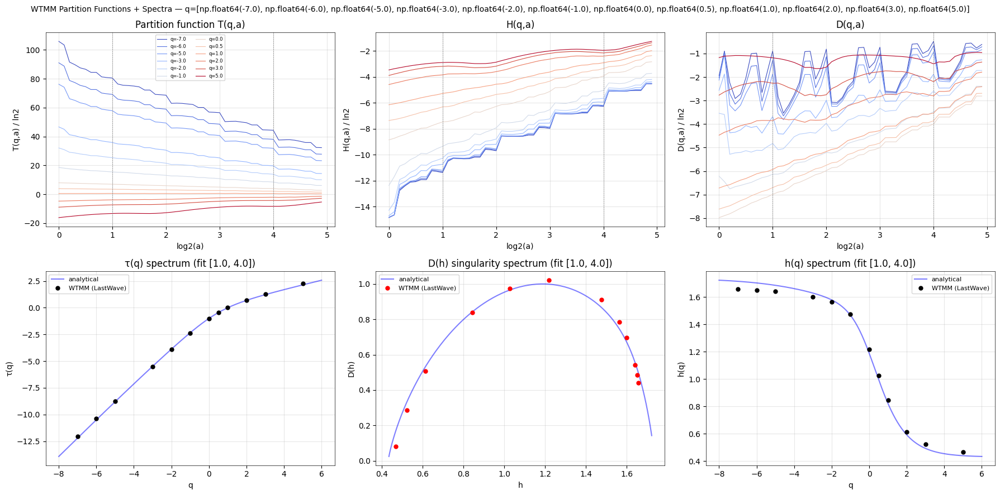


     q     tau(q)       ±σ       h(q)       ±σ       D(q)       ±σ
--------------------------------------------------------------------
  -7.0   -12.0466   0.2719     1.6581   0.0600     0.4395   0.1773
  -6.0   -10.3916   0.2159     1.6512   0.0574     0.4843   0.1563
  -5.0    -8.7454   0.1638     1.6405   0.0532     0.5431   0.1282
  -3.0    -5.4995   0.0786     1.6007   0.0388     0.6975   0.0576
  -2.0    -3.9151   0.0476     1.5648   0.0308     0.7856   0.0289
  -1.0    -2.3863   0.0235     1.4762   0.0239     0.9101   0.0128
   0.0    -1.0212   0.0094     1.2175   0.0127     1.0212   0.0094
   0.5    -0.4597   0.0071     1.0261   0.0095     0.9728   0.0094
   1.0     0.0066   0.0076     0.8444   0.0122     0.8377   0.0114
   2.0     0.7202   0.0239     0.6142   0.0280     0.5082   0.0344
   3.0     1.2812   0.0558     0.5220   0.0356     0.2849   0.0527
   5.0     2.2566   0.1230     0.4674   0.0310     0.0804   0.0360


In [ ]:
# [CELL 9]
# LastWave ground truth — Step 4: Partition functions + tau(q) + D(h) singularity spectrum
#
# DemoWTMM1DDevilStair:
#   qlist = {-7 -6 -5 -3 -2 -1 0 0.5 1 2 3 5}
#   pft = [pf wtmm w.extrep qlist]
#   disp {0w [tauqSpectrum pf 1 4] [singSpectrum pf 1 4]}
#
# tauqSpectrum/singSpectrum do linear regression of T(q,a), H(q,a), D(q,a)
# vs log2(a) over [log2aMin, log2aMax] = [1, 4].
# PF access functions return natural log; convert to log2 by dividing by ln(2).

# ── Declare signatures ──
lib.lw_compute_pf.restype = ctypes.c_int
lib.lw_compute_pf.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.c_int]

lib.lw_get_pf_size.restype = ctypes.c_int
lib.lw_get_pf_size.argtypes = []

lib.lw_get_pf_tq.restype = ctypes.c_int
lib.lw_get_pf_tq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_hq.restype = ctypes.c_int
lib.lw_get_pf_hq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_dq.restype = ctypes.c_int
lib.lw_get_pf_dq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

# ── Compute partition functions ──
q_list = np.array([-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5], dtype=np.float64)
n_q = len(q_list)

n_scales_done = lib.lw_compute_pf(q_list.ctypes.data_as(c_double_p), n_q)
assert n_scales_done > 0, f"lw_compute_pf failed: {lib.lw_get_error()}"

pf_size = lib.lw_get_pf_size()
print(f"PF computed: {n_scales_done} scales done, pf_size={pf_size}, n_q={n_q}")

# ── Extract T(q,a), H(q,a), D(q,a) for all q ──
# Mode: PFEXTENSIVE=0, PFINTENSIVE=1
# PF x-axis: x0 = log2(a_min), dx = 1/n_voice
log2_a_pf = np.log2(a_min) + np.arange(pf_size) / n_voice
ln2 = np.log(2.0)

tq_all = {}  # q -> T(q,a) array in log2 units
hq_all = {}  # q -> H(q,a)
dq_all = {}  # q -> D(q,a)

for iq, q in enumerate(q_list):
    buf = np.zeros(pf_size, dtype=np.float64)

    ret = lib.lw_get_pf_tq(iq, 0, buf.ctypes.data_as(c_double_p))
    tq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_hq(iq, 0, buf.ctypes.data_as(c_double_p))
    hq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_dq(iq, 0, buf.ctypes.data_as(c_double_p))
    dq_all[q] = buf.copy() / ln2 if ret > 0 else None

# ── Spectra via LastWave's own LineFitSig (replicates singSpectrum/tauqSpectrum) ──
log2a_min_fit, log2a_max_fit = 1.0, 4.0

lib.lw_compute_tauq_spectrum.restype = ctypes.c_int
lib.lw_compute_tauq_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]
lib.lw_compute_sing_spectrum.restype = ctypes.c_int
lib.lw_compute_sing_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]

tau_q = np.zeros(n_q, dtype=np.float64)
tau_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_tauq_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    tau_q.ctypes.data_as(c_double_p), tau_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_tauq_spectrum failed: {lib.lw_get_error()}"

h_q = np.zeros(n_q, dtype=np.float64)
h_sigma = np.zeros(n_q, dtype=np.float64)
d_q = np.zeros(n_q, dtype=np.float64)
d_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_sing_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    h_q.ctypes.data_as(c_double_p), h_sigma.ctypes.data_as(c_double_p),
    d_q.ctypes.data_as(c_double_p), d_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_sing_spectrum failed: {lib.lw_get_error()}"

print(f"Spectra computed via LastWave LineFitSig over [{log2a_min_fit}, {log2a_max_fit}]")


# ── Analytical tau(q) and D(h) for the inhomogeneous Cantor measure ──
# For a multinomial measure with parts (r_i, p_i), tau(q) satisfies:
#   sum_i  p_i^q * r_i^(-tau) = 1
# Solved numerically for each q. Then h(q) = tau'(q) and D(h) = q*h - tau.
from scipy.optimize import brentq

r_cantor = np.array([0.3, 0.2, 0.5])
p_cantor = np.array([0.2, 0.5, 0.3])

def tau_equation(tau, q, r, p):
    """sum_i p_i^q * r_i^(-tau) - 1 = 0"""
    return np.sum(p**q * r**(-tau)) - 1.0

q_fine = np.linspace(-8, 6, 500)
tau_analytical = np.zeros_like(q_fine)
for i, q in enumerate(q_fine):
    tau_analytical[i] = brentq(tau_equation, -20, 20, args=(q, r_cantor, p_cantor))

# h(q) = d(tau)/dq via finite differences
h_analytical = np.gradient(tau_analytical, q_fine)
# D(h) = q*h - tau  (Legendre transform)
d_analytical = q_fine * h_analytical - tau_analytical

# ── Plot ──
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel (0,0): T(q,a) vs log2(a) for selected q
colors_q = plt.cm.coolwarm(np.linspace(0, 1, n_q))
for iq, q in enumerate(q_list):
    if tq_all[q] is not None:
        axes[0, 0].plot(log2_a_pf, tq_all[q], '-', color=colors_q[iq], lw=0.8, label=f'q={q}')
axes[0, 0].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].set_xlabel('log2(a)')
axes[0, 0].set_ylabel('T(q,a) / ln2')
axes[0, 0].set_title('Partition function T(q,a)')
axes[0, 0].legend(fontsize=6, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# Panel (0,1): H(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if hq_all[q] is not None:
        axes[0, 1].plot(log2_a_pf, hq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 1].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].set_xlabel('log2(a)')
axes[0, 1].set_ylabel('H(q,a) / ln2')
axes[0, 1].set_title('H(q,a)')
axes[0, 1].grid(True, alpha=0.3)

# Panel (0,2): D(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if dq_all[q] is not None:
        axes[0, 2].plot(log2_a_pf, dq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 2].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].set_xlabel('log2(a)')
axes[0, 2].set_ylabel('D(q,a) / ln2')
axes[0, 2].set_title('D(q,a)')
axes[0, 2].grid(True, alpha=0.3)

# Panel (1,0): tau(q) spectrum
axes[1, 0].plot(q_fine, tau_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
axes[1, 0].plot(q_list, tau_q, 'ko', markersize=5, label='WTMM (LastWave)')
axes[1, 0].set_xlabel('q')
axes[1, 0].set_ylabel('\u03c4(q)')
axes[1, 0].set_title(f'\u03c4(q) spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Panel (1,1): D(h) singularity spectrum
axes[1, 1].plot(h_analytical, d_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
sort_idx = np.argsort(h_q)
axes[1, 1].plot(h_q[sort_idx], d_q[sort_idx], 'ro', markersize=5, label='WTMM (LastWave)')
axes[1, 1].set_xlabel('h')
axes[1, 1].set_ylabel('D(h)')
axes[1, 1].set_title(f'D(h) singularity spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# Panel (1,2): h(q) vs q
h_analytical_q = np.gradient(tau_analytical, q_fine)
axes[1, 2].plot(q_fine, h_analytical_q, 'b-', lw=1.5, alpha=0.5, label='analytical')
axes[1, 2].plot(q_list, h_q, 'ko', markersize=5, label='WTMM (LastWave)')
axes[1, 2].set_xlabel('q')
axes[1, 2].set_ylabel('h(q)')
axes[1, 2].set_title(f'h(q) spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f"WTMM Partition Functions + Spectra — q={list(q_list)}", fontsize=10)
plt.tight_layout()
plt.show()

# ── Summary ──
print(f"\n{'q':>6} {'tau(q)':>10} {'±σ':>8} {'h(q)':>10} {'±σ':>8} {'D(q)':>10} {'±σ':>8}")
print('-' * 68)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} {tau_q[iq]:10.4f} {tau_sigma[iq]:8.4f} {h_q[iq]:10.4f} {h_sigma[iq]:8.4f} {d_q[iq]:10.4f} {d_sigma[iq]:8.4f}')

# Faithful WTMM Implementation with GPU Acceleration

A Python reimplementation of LastWave's WTMM (Wavelet Transform Modulus Maxima) algorithm
for multifractal analysis. Faithfully matches LastWave's `CWtd()`, `extrema`, `chain`,
`chainmax`, and `pf wtmm` pipeline.

**GPU**: PyTorch MPS on Apple Silicon M2 Max

In [ ]:
# Cell 10: Imports and device setup
#
# Fix duplicate libomp crash (torch + numba both link OpenMP on macOS)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, device: CPU, dtype: float64')


PyTorch 2.10.0, device: CPU, dtype: float64


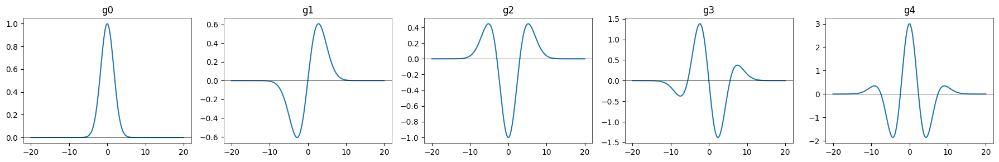

In [ ]:
# Cell 11: Gaussian derivative wavelets — now imported from wtmm package
from wtmm.wavelets import WAVELETS, wavelet_direct, wavelet_support

# Quick test: plot g2 at scale a=1
x_test = np.linspace(-20, 20, 1000)
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
for i, name in enumerate(['g0', 'g1', 'g2', 'g3', 'g4']):
    axes[i].plot(x_test, wavelet_direct(x_test, 1.0, name))
    axes[i].set_title(name)
    axes[i].axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 12: CWT engine — now imported from wtmm package
from wtmm.cwt import cwtd, cwtd_batched

print('CWT engine loaded (from wtmm.cwt). Use cwtd() for faithful per-scale, cwtd_batched() for optimized.')
print(f'CWT device: CPU, dtype: float64')


CWT engine defined. Use cwtd() for faithful per-scale, cwtd_batched() for optimized.
CWT device: CPU, dtype: float64


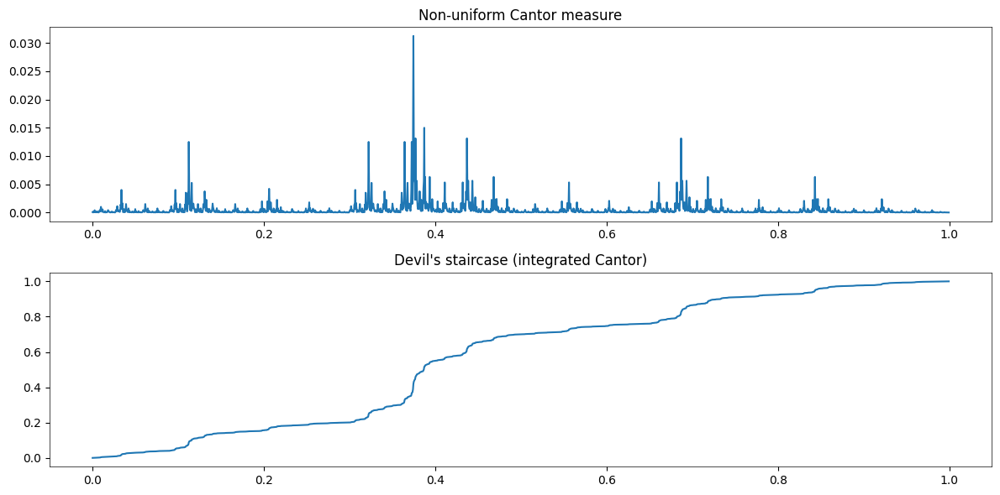

Signal size: 2048, dx: 0.00048828125
Staircase range: [0.0001, 1.0000]


In [ ]:
# Cell 13: Devil's staircase test signal — ucantor now imported from wtmm package
from wtmm.signals import ucantor, tau_equation

# Generate devil's staircase: ucantor then prim (cumulative sum)
# DemoWTMM1DDevilStair: ucantor 0w size 0.3 0.2 0.2 0.5 0.5 0.3
# Command parsing: signal size r0 p0 r1 p1 r2 p2
# So r = [0.3, 0.2, 0.5], p = [0.2, 0.5, 0.3]
# nFlip defaults to 0, but C_UCantor does nFlip-- so nFlip = -1 (no flip)

SIZE = 2048
cantor_measure, dx = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)

# prim = cumulative sum (matching LastWave's prim())
devil_staircase = np.cumsum(cantor_measure)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
for spine in ax1.spines.values(): spine.set_linewidth(0.5)
for spine in ax2.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) * dx
ax1.plot(t_axis, cantor_measure)
ax1.set_title('Non-uniform Cantor measure')
ax2.plot(t_axis, devil_staircase)
ax2.set_title("Devil\'s staircase (integrated Cantor)")
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}, dx: {dx}')
print(f'Staircase range: [{devil_staircase.min():.4f}, {devil_staircase.max():.4f}]')


Sawtooth: 10000 samples, 10.0s, period=0.3s, ramp=95%


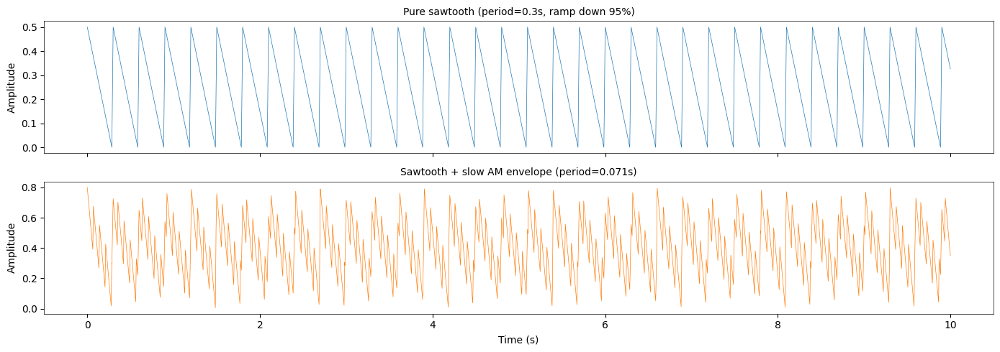

In [ ]:
# ══════════════════════════════════════════════════════════════
# HHT on a synthetic sawtooth: slow ramp down, sharp spike up
# ══════════════════════════════════════════════════════════════
# This tests how EMD + Hilbert-Huang handles sharp singularities
# analogous to creepmeter slip events (slow accumulation + sudden release).
import emd
from scipy import ndimage

# ── 1. Build piecewise-linear sawtooth ──
saw_sr = 1000.0          # samples/sec (arbitrary, just for clean numbers)
saw_duration = 10.0       # seconds total
saw_period = 0.3          # period of one tooth (seconds)
ramp_frac = 0.95          # fraction of period spent ramping down
amplitude = .5

t_saw = np.arange(0, saw_duration, 1.0 / saw_sr)
n_saw = len(t_saw)

# Phase within each tooth [0, 1)
phase = (t_saw % saw_period) / saw_period

# Ramp down for ramp_frac of the period, then spike up
saw = np.where(phase < ramp_frac,
               amplitude * (1.0 - phase / ramp_frac),       # linear ramp down
               amplitude * (phase - ramp_frac) / (1.0 - ramp_frac))  # sharp rise back

# Add a second slower sawtooth as AM envelope (period = 2s)
slow_period = .071
slow_phase = (t_saw % slow_period) / slow_period
slow_env = 0.3 * np.where(slow_phase < 0.9,
                           1.0 - slow_phase / 0.9,
                           (slow_phase - 0.9) / 0.1)
saw_modulated = saw + slow_env

print(f'Sawtooth: {n_saw} samples, {saw_duration}s, period={saw_period}s, ramp={ramp_frac*100:.0f}%')

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax in axes:
    for spine in ax.spines.values(): spine.set_linewidth(0.5)
axes[0].plot(t_saw, saw, lw=0.5)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Pure sawtooth (period={saw_period}s, ramp down {ramp_frac*100:.0f}%)', fontsize=10)
axes[1].plot(t_saw, saw_modulated, lw=0.5, color='tab:orange')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Sawtooth + slow AM envelope (period={slow_period}s)', fontsize=10)
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


CWT computed in 0.427s
Coefficients shape: (50, 10000), Scales: 50 (1.00 to 29.86)
Valid range at finest scale: (18, 9981), coarsest: (537, 9462)


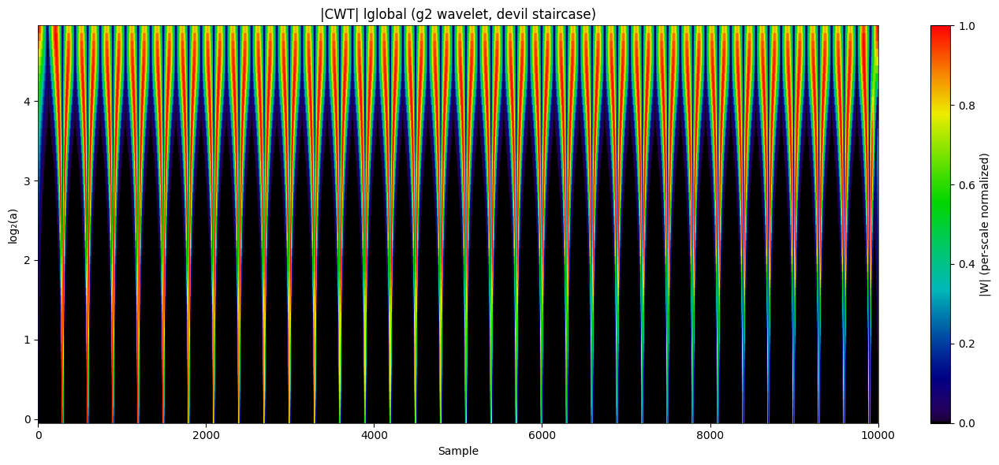

In [ ]:
# Cell 14: CWT + visualization on devil's staircase
# DemoWTMM1DDevilStair: cwtd w 1.0 5 10 'g2' -b 'mir'
# Default expo = -1

t0 = time.time()
coeffs, scales, valid_ranges = cwtd(saw, a_min=1.0, n_oct=5, n_voice=10,
                                     wavelet_name='g2', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram — LastWave lglobal normalization (no log)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode='lglobal')
ax.set_title('|CWT| lglobal (g2 wavelet, devil staircase)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 15: Extrema detection — now imported from wtmm package
from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=5, n_voice=10, a_min=1.0,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
for sidx in [0, 10, 20, 30, 40, 49]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')


Numba warmup: 0.012s
Total extrema: 3295
Extrema computed in 0.004s
  Scale 0 (a=1.00): 66 extrema
  Scale 10 (a=2.00): 66 extrema
  Scale 20 (a=4.00): 66 extrema
  Scale 30 (a=8.00): 66 extrema
  Scale 40 (a=16.00): 66 extrema
  Scale 49 (a=29.86): 65 extrema


In [ ]:
# Cell 16: Chaining — now imported from wtmm package
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=5, n_voice=10)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, 5 * 10)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=5, n_voice=10)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=5, n_voice=10, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')


Chaining: 0.003s
Delete: 0.004s, deleted 0 chains
ChainMax: 0.004s
Total chaining: 0.010s
Remaining extrema: 3295


Pre-deletion chains: 66
Surviving chains: 66
Deleted chains: 0


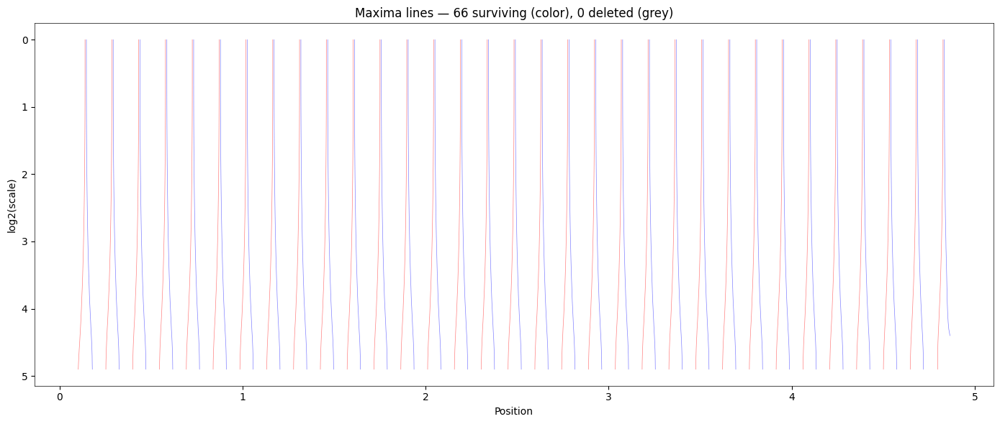

In [ ]:
# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, 5 * 10)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, vals in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, vals in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign, vals))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving colored by log2|ordinate|, deleted greyed out
import matplotlib as mpl

N_COLORS = 14
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

# Draw deleted chains first (background, grey)
for pos, sv, sign, vals in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Collect all log2|ordinate| values for colormap normalization
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300) for _, _, _, vals in post_del_chains])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

# Draw surviving chains colored by log2|ordinate| at each segment
for pos, sv, sign, vals in post_del_chains:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log\u2082|W| (after ChainDelete)', shrink=0.8)

ax.set_xlabel('Position')
ax.set_ylabel('log\u2082(scale)')
ax.set_title(f'Maxima lines \u2014 {len(post_del_chains)} surviving ({N_COLORS} levels), {len(deleted_chains)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Partition function computed in 0.008s, up to scale index 49
Extrema per scale (sample): [66 66 66 66 66]...[65 65 65 65 65]


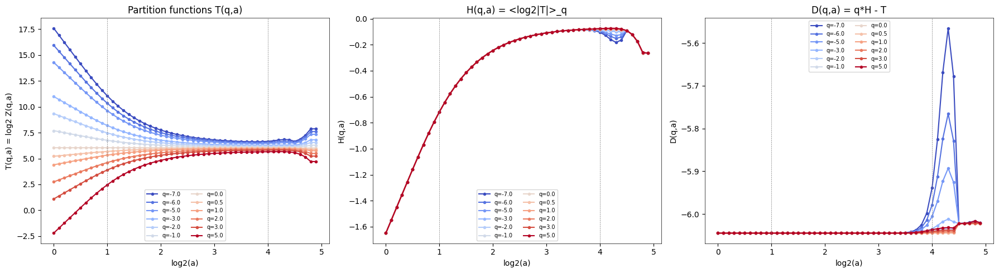

Gray dashed lines show regression range [log2(a)=1 to 4]


In [ ]:
# Cell 18: Partition function — now imported from wtmm package
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D

# Compute partition function
q_list = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=5, n_voice=10, a_min=1.0, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a) — this is what LastWave's "pf get t" returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')


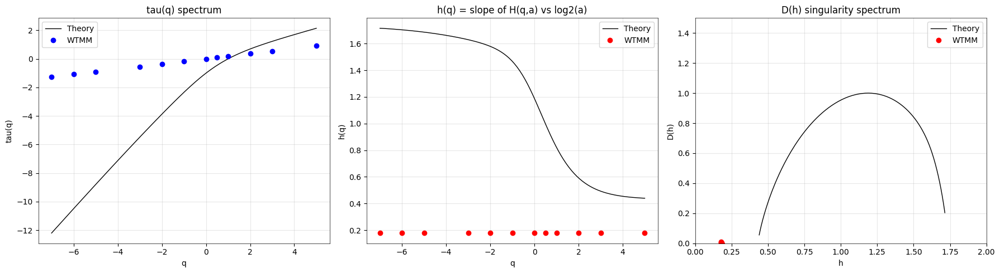


Theoretical: expo=-1.0, so tau_WTMM = tau_measure (integration + 1/a cancel)
h range: [0.458, 1.709]

q	 tau_WTMM	 tau_theory	 diff		 h_WTMM		 h_theory
 -7.0	  -1.2593	 -12.2063	 +10.9469	   0.1784	   1.7094
 -6.0	  -1.0806	 -10.4969	 +9.4163	   0.1790	   1.7021
 -5.0	  -0.9014	  -8.8021	 +7.9007	   0.1795	   1.6832
 -3.0	  -0.5417	  -5.4818	 +4.9402	   0.1802	   1.6242
 -2.0	  -0.3614	  -3.8756	 +3.5143	   0.1805	   1.5690
 -1.0	  -0.1808	  -2.3439	 +2.1631	   0.1807	   1.4378
  0.0	  -0.0000	  -1.0000	 +1.0000	   0.1809	   1.1768
  0.5	   0.0905	  -0.4534	 +0.5438	   0.1809	   1.0000
  1.0	   0.1809	  -0.0000	 +0.1809	   0.1810	   0.8354
  2.0	   0.3620	   0.6928	 -0.3308	   0.1811	   0.6139
  3.0	   0.5432	   1.2277	 -0.6845	   0.1812	   0.5093
  5.0	   0.9058	   2.1440	 -1.2382	   0.1814	   0.4581


In [ ]:
# Cell 19: tau(q), h(q), D(h) spectrum — now imported from wtmm package
from wtmm.spectra import compute_spectra, theoretical_devil_staircase

# Compute spectra
# DemoWTMM1DDevilStair: tauqSpectrum pf 1 4 and singSpectrum pf 1 4
spectra = compute_spectra(pf, log2_a_min=1.0, log2_a_max=4.0)

# Theoretical values — use expo=-1 to match our CWT normalization
q_fine = np.linspace(-7, 5, 200)
tau_theory, h_theory, D_theory = theoretical_devil_staircase(
    q_fine, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

tau_theory_q, h_theory_q, D_theory_q = theoretical_devil_staircase(
    spectra['q_list'], r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# 1. tau(q)
ax = axes[0]
ax.plot(q_fine, tau_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('\u03c4(q)')
ax.set_title('\u03c4(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q)
ax = axes[1]
ax.plot(q_fine, h_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) = slope of H(q,a) vs log\u2082(a)')
ax.legend()
ax.grid(True, alpha=0.3)
# Set y-range from theory, with a little padding
h_pad = 0.15 * (h_theory.max() - h_theory.min())
ax.set_ylim(h_theory.min() - h_pad, h_theory.max() + h_pad)

# 3. D(h) singularity spectrum — disconnected points
ax = axes[2]
ax.plot(h_theory, D_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, linestyle='none', label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print(f'\nTheoretical: expo={-1.0}, so \u03c4_WTMM = \u03c4_measure (integration + 1/a cancel)')
print(f'h range: [{h_theory_q.min():.3f}, {h_theory_q.max():.3f}]')
print('\nq\t \u03c4_WTMM\t \u03c4_theory\t diff\t\t h_WTMM\t\t h_theory')
for i, q in enumerate(spectra['q_list']):
    print(f'{q:5.1f}\t {spectra["tau_q"][i]:8.4f}\t {tau_theory_q[i]:8.4f}\t {spectra["tau_q"][i]-tau_theory_q[i]:+.4f}'
          f'\t {spectra["h_q"][i]:8.4f}\t {h_theory_q[i]:8.4f}')


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_49707/2992841337.py:81: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()
/Users/amasaryk/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  fig.canvas.print_figure(bytes_io, **kw)


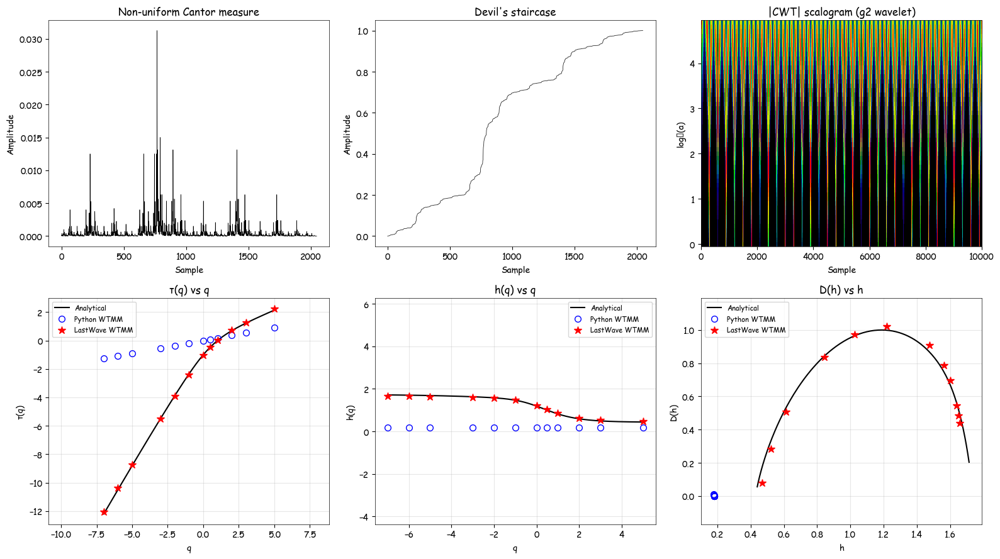

In [ ]:
# CELL 20
# Three-way comparison: LastWave WTMM vs Python WTMM vs Analytical
#
# Top row: signals and scalogram
# Bottom row: tau(q), h(q), D(h) spectra with equal aspect

import matplotlib as mpl

# Comic Sans styling
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Thin spines on all axes
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# ── Top row: signals + scalogram ──

# (0,0): Cantor measure
ax = axes[0, 0]
ax.plot(cantor_measure, 'k-', lw=0.5)
ax.set_title('Non-uniform Cantor measure')
ax.set_xlabel('Sample')
ax.set_ylabel('Amplitude')

# (0,1): Devil's staircase
ax = axes[0, 1]
ax.plot(devil_staircase, 'k-', lw=0.5)
ax.set_title("Devil's staircase")
ax.set_xlabel('Sample')
ax.set_ylabel('Amplitude')

# (0,2): Scalogram
ax = axes[0, 2]
scalogram_lastwave(coeffs, scales=scales, ax=ax, norm_mode='lglobal')
ax.set_title('|CWT| scalogram (g2 wavelet)')

# ── Bottom row: three-way spectra (equal aspect) ──

# (1,0): tau(q) vs q
ax = axes[1, 0]
ax.plot(q_fine, tau_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(q_list, tau_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('τ(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# (1,1): h(q) vs q
ax = axes[1, 1]
ax.plot(q_fine, h_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['q_list'], spectra['h_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(q_list, h_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# (1,2): D(h) vs h
ax = axes[1, 2]
ax.plot(h_theory, D_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['h_q'], spectra['D_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(h_q, d_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) vs h')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

# Reset font
mpl.rcParams['font.family'] = 'sans-serif'

Total extrema: LW=3645, Python=3295
Count mismatches at scales: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
  Scale 0: LW=252, Py=66
  Scale 1: LW=238, Py=66
  Scale 2: LW=225, Py=66
  Scale 3: LW=208, Py=66
  Scale 4: LW=191, Py=66
  Scale 5: LW=179, Py=66
  Scale 6: LW=164, Py=66
  Scale 7: LW=155, Py=66
  Scale 8: LW=144, Py=66
  Scale 9: LW=137, Py=66
  Scale 10: LW=127, Py=66
  Scale 11: LW=119, Py=66
  Scale 12: LW=115, Py=66
  Scale 13: LW=105, Py=66
  Scale 14: LW=93, Py=66
  Scale 15: LW=89, Py=66
  Scale 16: LW=83, Py=66
  Scale 17: LW=77, Py=66
  Scale 18: LW=71, Py=66
  Scale 19: LW=68, Py=66
  Scale 20: LW=63, Py=66
  Scale 21: LW=58, Py=66
  Scale 22: LW=57, Py=66
  Scale 23: LW=52, Py=66
  Scale 24: LW=46, Py=66
  Scale 25: LW=44, Py=66
  Scale 26: LW=40, Py=66
  Scale 27: LW=39, Py=66
  Scale 28: LW=35, Py=66
  Scale 29: LW=34, Py=66
  Scale 30: LW=32, Py=66
  S

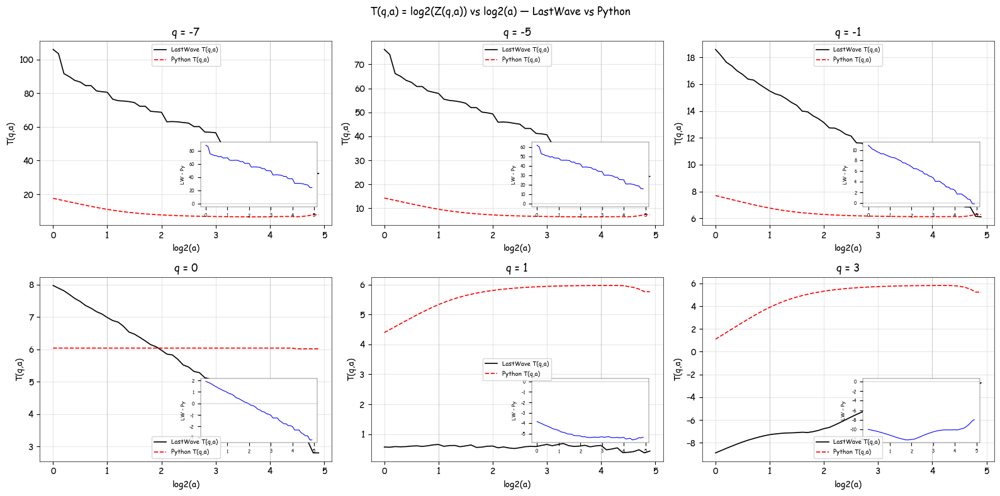

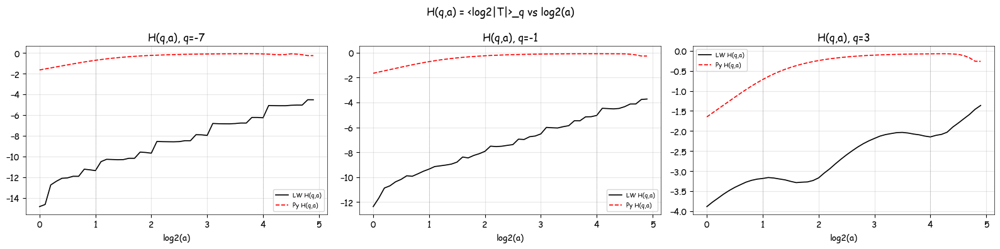

In [ ]:
# CELL 21
# Extrema + Partition function comparison: LastWave vs Python
#
# 1. Extrema counts and ordinate values at each scale
# 2. T(q,a), H(q,a), D(q,a) at every scale for all q values
# 3. Plots of T(q,a) vs log2(a) for selected q values

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ═══ Part 1: Extrema comparison ═══
lw_ext_post = {}
lw_counts = np.zeros(n_scales, dtype=int)
py_counts = np.zeros(n_scales, dtype=int)

for o in range(1, n_oct + 1):
    for v in range(n_voice):
        scale_idx = (o - 1) * n_voice + v
        count = lib.lw_get_extrema_count(o, v)
        if count > 0:
            pos = np.zeros(count, dtype=np.float64)
            val = np.zeros(count, dtype=np.float64)
            got = lib.lw_get_extrema_at_scale(
                o, v,
                pos.ctypes.data_as(c_double_p),
                val.ctypes.data_as(c_double_p),
                count)
            lw_ext_post[scale_idx] = (pos[:got], val[:got])
            lw_counts[scale_idx] = got
        else:
            lw_ext_post[scale_idx] = (np.array([]), np.array([]))
        py_counts[scale_idx] = len(extrep_ord[scale_idx])

print(f'Total extrema: LW={lw_counts.sum()}, Python={py_counts.sum()}')
mismatches = np.where(lw_counts != py_counts)[0]
if len(mismatches):
    print(f'Count mismatches at scales: {mismatches}')
    for s in mismatches:
        print(f'  Scale {s}: LW={lw_counts[s]}, Py={py_counts[s]}')

# ═══ Part 2: T(q,a), H(q,a), D(q,a) comparison ═══
ln2 = np.log(2.0)

# Extract all LW partition function curves
lw_T = {}  # q_idx -> array over scales
lw_H = {}
lw_D = {}
for iq in range(len(q_list)):
    buf = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_tq(iq, 0, buf.ctypes.data_as(c_double_p))
    lw_T[iq] = buf.copy() / ln2

    buf2 = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_hq(iq, 0, buf2.ctypes.data_as(c_double_p))
    lw_H[iq] = buf2.copy() / ln2

    buf3 = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_dq(iq, 0, buf3.ctypes.data_as(c_double_p))
    lw_D[iq] = buf3.copy() / ln2

# Python partition function curves
py_T = {}
py_H = {}
py_D = {}
for iq in range(len(q_list)):
    py_T[iq] = pf_get_T(pf, iq, 'extensive')
    py_H[iq] = pf_get_H(pf, iq, 'extensive')
    py_D[iq] = pf_get_D(pf, iq, q_list[iq], 'extensive')

# ═══ Part 3: Summary table — max |diff| for each q ═══
log2_a_pf = np.log2(a_min) + np.arange(pf_size) / n_voice
n_compare = min(pf_size, n_scales)

print(f'\n{"q":>5} {"max|dT|":>12} {"max|dH|":>12} {"max|dD|":>12}  {"worst scale":>12}')
print('-' * 60)
for iq, q in enumerate(q_list):
    dT = np.abs(lw_T[iq][:n_compare] - py_T[iq][:n_compare])
    dH = np.abs(lw_H[iq][:n_compare] - py_H[iq][:n_compare])
    dD = np.abs(lw_D[iq][:n_compare] - py_D[iq][:n_compare])
    # ignore NaN
    dT = np.where(np.isfinite(dT), dT, 0)
    dH = np.where(np.isfinite(dH), dH, 0)
    dD = np.where(np.isfinite(dD), dD, 0)
    worst = np.argmax(dT)
    print(f'{q:5.1f} {dT.max():12.6f} {dH.max():12.6f} {dD.max():12.6f}  {worst:5d} (log2a={log2_a_pf[worst]:.1f})')

# ═══ Part 4: Plots — T(q,a) vs log2(a) for selected q values ═══
sel_q = [-7, -5, -1, 0, 1, 3]
sel_iq = [list(q_list).index(q) for q in sel_q]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

for idx, (ax, iq) in enumerate(zip(axes.flatten(), sel_iq)):
    q = q_list[iq]
    x = log2_a_pf[:n_compare]
    ax.plot(x, lw_T[iq][:n_compare], 'k-', lw=1.2, label='LastWave T(q,a)')
    ax.plot(x, py_T[iq][:n_compare], 'r--', lw=1.2, label='Python T(q,a)')

    # Show fit range
    ax.axvline(1.0, color='gray', ls=':', lw=0.5)
    ax.axvline(4.0, color='gray', ls=':', lw=0.5)

    ax.set_xlabel('log2(a)')
    ax.set_ylabel('T(q,a)')
    ax.set_title(f'q = {q}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # Inset: difference
    inset = ax.inset_axes([0.55, 0.1, 0.4, 0.35])
    diff = lw_T[iq][:n_compare] - py_T[iq][:n_compare]
    inset.plot(x, diff, 'b-', lw=0.8)
    inset.set_ylabel('LW - Py', fontsize=6)
    inset.tick_params(labelsize=5)
    inset.axhline(0, color='gray', ls='-', lw=0.3)
    for sp in inset.spines.values(): sp.set_linewidth(0.3)

plt.suptitle('T(q,a) = log2(Z(q,a)) vs log2(a) — LastWave vs Python', fontsize=12)
plt.tight_layout()
plt.show()

# ═══ Part 5: H(q,a) comparison for extreme q ═══
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
for ax in axes2: 
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

for ax, iq in zip(axes2, [0, 5, 10]):  # q=-7, q=-1, q=3
    q = q_list[iq]
    x = log2_a_pf[:n_compare]
    ax.plot(x, lw_H[iq][:n_compare], 'k-', lw=1.2, label='LW H(q,a)')
    ax.plot(x, py_H[iq][:n_compare], 'r--', lw=1.2, label='Py H(q,a)')
    ax.axvline(1.0, color='gray', ls=':', lw=0.5)
    ax.axvline(4.0, color='gray', ls=':', lw=0.5)
    ax.set_title(f'H(q,a), q={q}')
    ax.set_xlabel('log2(a)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('H(q,a) = <log2|T|>_q vs log2(a)', fontsize=12)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'


LW valid ranges: 50 scales, e.g. finest=(18, 2029), coarsest=(537, 1510)
Total extrema: 3645
Extrema on LW CWT: 0.015s
Chaining: 0.000s
Delete: 0.001s, deleted 0 chains
ChainMax: 0.001s
Remaining extrema (LW CWT): 3645
PF computed in 0.002s, up to scale index 49
Spectra computed for 12 q values

Extrema count comparison (after chain processing):
  Python CWT extrema total: 3295
  LW CWT extrema total:     3645
  Mismatched scales (50):
    Scale 0 (a=1.00): PyCWT=66, LWCWT=252
    Scale 1 (a=1.07): PyCWT=66, LWCWT=238
    Scale 2 (a=1.15): PyCWT=66, LWCWT=225
    Scale 3 (a=1.23): PyCWT=66, LWCWT=208
    Scale 4 (a=1.32): PyCWT=66, LWCWT=191
    Scale 5 (a=1.41): PyCWT=66, LWCWT=179
    Scale 6 (a=1.52): PyCWT=66, LWCWT=164
    Scale 7 (a=1.62): PyCWT=66, LWCWT=155
    Scale 8 (a=1.74): PyCWT=66, LWCWT=144
    Scale 9 (a=1.87): PyCWT=66, LWCWT=137

     q     tau_LW  tau_PyCWT  tau_LWCWT       h_LW    h_PyCWT    h_LWCWT       D_LW    D_PyCWT    D_LWCWT
---------------------------------

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_49707/3616245384.py:135: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Comic Sans MS.
  plt.tight_layout()


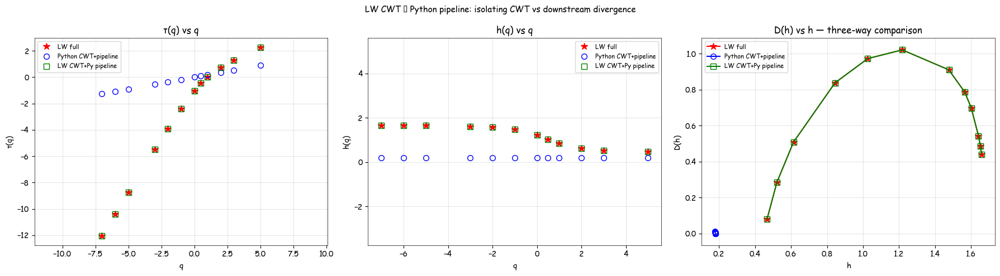


Max absolute differences vs LW ground truth:
  LW CWT+Py pipeline: tau=0.000000, h=0.000000, D=0.000000
  Py CWT+Py pipeline: tau=10.787249, h=1.479757, D=1.021170


In [ ]:
# CELL 22: LW-CWT + Python pipeline — isolate CWT vs downstream divergence
#
# Feed LastWave's CWT coefficients (cwt, from cell 2) into the Python
# extrema → chain → PF → spectra pipeline. If the resulting D(h) matches
# LW ground truth, the Python downstream is correct and the CWT is the
# source of D(h) divergence.

import time as _time
import matplotlib as mpl

# ── 1. Build LW-compatible valid_ranges ──
lw_vr = list(zip(firstp.tolist(), lastp.tolist()))
print(f'LW valid ranges: {len(lw_vr)} scales, e.g. finest={lw_vr[0]}, coarsest={lw_vr[-1]}')

# ── 2. Run Python extrema on LW CWT ──
dx_signal_lw = 1.0 / SIZE
t0 = _time.time()
lw_extrep_abs, lw_extrep_ord, lw_extrep_idx = compute_extrep(
    cwt, scales, n_oct=n_oct, n_voice=n_voice, a_min=a_min,
    valid_ranges=lw_vr, dx=dx_signal_lw, x0=0.0, epsilon=1e-6)
t1 = _time.time()
print(f'Extrema on LW CWT: {t1-t0:.3f}s')

# ── 3. Run Python chaining ──
t2 = _time.time()
lw_coarser_links, lw_finer_links = chain_all(lw_extrep_abs, lw_extrep_ord,
                                              n_oct=n_oct, n_voice=n_voice)
t3 = _time.time()
print(f'Chaining: {t3-t2:.3f}s')

lw_nb_del = chain_delete_all(lw_extrep_abs, lw_extrep_ord, lw_extrep_idx,
                              lw_coarser_links, lw_finer_links,
                              n_oct=n_oct, n_voice=n_voice)
t4 = _time.time()
print(f'Delete: {t4-t3:.3f}s, deleted {lw_nb_del} chains')

chain_max_wrapper(lw_extrep_ord, lw_coarser_links,
                  n_oct=n_oct, n_voice=n_voice, a_min=a_min, expo=1.0)
t5 = _time.time()
print(f'ChainMax: {t5-t4:.3f}s')
print(f'Remaining extrema (LW CWT): {sum(len(a) for a in lw_extrep_abs)}')

# ── 4. Run Python PF on LW CWT extrema ──
t6 = _time.time()
pf_lw = compute_partition_function(lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
                                    a_min=a_min, q_list=q_list)
t7 = _time.time()
print(f'PF computed in {t7-t6:.3f}s, up to scale index {pf_lw["index_max"]}')

# ── 5. Run Python spectra on LW CWT PF ──
spectra_lw = compute_spectra(pf_lw, log2_a_min=1.0, log2_a_max=4.0)
print(f'Spectra computed for {len(spectra_lw["q_list"])} q values')

# ── 6. Compare & plot ──

# Extrema counts comparison
py_ext_counts = np.array([len(extrep_abs[s]) for s in range(n_oct * n_voice)])
lw_ext_counts = np.array([len(lw_extrep_abs[s]) for s in range(n_oct * n_voice)])
ext_diff = np.where(py_ext_counts != lw_ext_counts)[0]
print(f'\nExtrema count comparison (after chain processing):')
print(f'  Python CWT extrema total: {py_ext_counts.sum()}')
print(f'  LW CWT extrema total:     {lw_ext_counts.sum()}')
if len(ext_diff) > 0:
    print(f'  Mismatched scales ({len(ext_diff)}):')
    for s in ext_diff[:10]:
        print(f'    Scale {s} (a={scales[s]:.2f}): PyCWT={py_ext_counts[s]}, LWCWT={lw_ext_counts[s]}')
else:
    print('  All scales match!')

# Per-q numerical differences
print(f'\n{"q":>6} {"tau_LW":>10} {"tau_PyCWT":>10} {"tau_LWCWT":>10} '
      f'{"h_LW":>10} {"h_PyCWT":>10} {"h_LWCWT":>10} '
      f'{"D_LW":>10} {"D_PyCWT":>10} {"D_LWCWT":>10}')
print('-' * 105)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} '
          f'{tau_q[iq]:10.4f} {spectra["tau_q"][iq]:10.4f} {spectra_lw["tau_q"][iq]:10.4f} '
          f'{h_q[iq]:10.4f} {spectra["h_q"][iq]:10.4f} {spectra_lw["h_q"][iq]:10.4f} '
          f'{d_q[iq]:10.4f} {spectra["D_q"][iq]:10.4f} {spectra_lw["D_q"][iq]:10.4f}')

# Three-way D(h) plot
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# tau(q) vs q
ax = axes[0]
ax.plot(q_list, tau_q, 'r*', markersize=9, label='LW full')
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', fillstyle='none',
        markersize=7, label='Python CWT+pipeline')
ax.plot(spectra_lw['q_list'], spectra_lw['tau_q'], 'gs', fillstyle='none',
        markersize=7, label='LW CWT+Py pipeline')
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('τ(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# h(q) vs q
ax = axes[1]
ax.plot(q_list, h_q, 'r*', markersize=9, label='LW full')
ax.plot(spectra['q_list'], spectra['h_q'], 'bo', fillstyle='none',
        markersize=7, label='Python CWT+pipeline')
ax.plot(spectra_lw['q_list'], spectra_lw['h_q'], 'gs', fillstyle='none',
        markersize=7, label='LW CWT+Py pipeline')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# D(h) vs h
ax = axes[2]
sort_lw = np.argsort(h_q)
ax.plot(h_q[sort_lw], d_q[sort_lw], 'r*-', markersize=9, label='LW full')
sort_py = np.argsort(spectra['h_q'])
ax.plot(spectra['h_q'][sort_py], spectra['D_q'][sort_py], 'bo-', fillstyle='none',
        markersize=7, label='Python CWT+pipeline')
sort_lw_py = np.argsort(spectra_lw['h_q'])
ax.plot(spectra_lw['h_q'][sort_lw_py], spectra_lw['D_q'][sort_lw_py], 'gs-', fillstyle='none',
        markersize=7, label='LW CWT+Py pipeline')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) vs h — three-way comparison')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('LW CWT → Python pipeline: isolating CWT vs downstream divergence', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Summary
print('\nMax absolute differences vs LW ground truth:')
print(f'  LW CWT+Py pipeline: tau={np.max(np.abs(tau_q - spectra_lw["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra_lw["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra_lw["D_q"])):.6f}')
print(f'  Py CWT+Py pipeline: tau={np.max(np.abs(tau_q - spectra["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra["D_q"])):.6f}')

In [ ]:
# CELL 23: Python-CWT → LW extrema/chain/chainmax → Python PF/spectra
#
# The reverse experiment: feed Python CWT coefficients into LastWave's
# extrema detection + chaining + chainmax, then run Python PF + spectra
# on the LW chainmax extrema. This isolates whether the extrema/chain
# pipeline is the source of D(h) divergence.

import time as _time
import matplotlib as mpl

# ── 0. Declare lw_set_cwt_coefficients ──
lib.lw_set_cwt_coefficients.restype = ctypes.c_int
lib.lw_set_cwt_coefficients.argtypes = [
    ctypes.POINTER(ctypes.c_double),  # coeffs_in
    ctypes.c_int,                      # size
    ctypes.POINTER(ctypes.c_int),      # firstp_in
    ctypes.POINTER(ctypes.c_int),      # lastp_in
]

# ── 1. Inject Python CWT coefficients into LastWave's wtrans ──
# coeffs is from cell 15 (Python CWT), shape (n_scales, SIZE)
# valid_ranges is from cell 15, list of (firstp, lastp) tuples
py_coeffs_flat = np.ascontiguousarray(coeffs.ravel(), dtype=np.float64)
py_firstp = np.array([vr[0] for vr in valid_ranges], dtype=np.int32)
py_lastp  = np.array([vr[1] for vr in valid_ranges], dtype=np.int32)

ret = lib.lw_set_cwt_coefficients(
    py_coeffs_flat.ctypes.data_as(c_double_p),
    SIZE,
    py_firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    py_lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
assert ret == 0, f'lw_set_cwt_coefficients failed: {lib.lw_get_error()}'
print('Injected Python CWT coefficients into LastWave wtrans')

# ── 2. Run LW extrema detection on Python CWT ──
t0 = _time.time()
nb_ext_pycwt = lib.lw_compute_extrema(ctypes.c_double(1e-6))
assert nb_ext_pycwt >= 0, f'lw_compute_extrema failed: {lib.lw_get_error()}'
t1 = _time.time()
print(f'LW extrema on PyCWT: {nb_ext_pycwt} extrema in {t1-t0:.3f}s')

# ── 3. Run LW chaining + delete + chainmax on Python CWT extrema ──
ret = lib.lw_chain(ctypes.c_double(10.0))
assert ret == 0, f'lw_chain failed: {lib.lw_get_error()}'
t2 = _time.time()
print(f'LW chain: {t2-t1:.3f}s')

deleted_pycwt = lib.lw_chain_delete()
t3 = _time.time()
print(f'LW chain_delete: removed {deleted_pycwt}, {t3-t2:.3f}s')

ret = lib.lw_chain_max(ctypes.c_double(1.0))
assert ret == 0, f'lw_chain_max failed: {lib.lw_get_error()}'
t4 = _time.time()
print(f'LW chain_max: {t4-t3:.3f}s')

# ── 4. Extract LW chainmax extrema into Python arrays for PF ──
pycwt_lw_extrep_ord = []
pycwt_lw_ext_counts = np.zeros(n_scales, dtype=int)
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        scale_idx = (o - 1) * n_voice + v
        count = lib.lw_get_extrema_count(o, v)
        if count > 0:
            pos = np.zeros(count, dtype=np.float64)
            val = np.zeros(count, dtype=np.float64)
            got = lib.lw_get_extrema_at_scale(
                o, v,
                pos.ctypes.data_as(c_double_p),
                val.ctypes.data_as(c_double_p),
                count)
            pycwt_lw_extrep_ord.append(val[:got].copy())
            pycwt_lw_ext_counts[scale_idx] = got
        else:
            pycwt_lw_extrep_ord.append(np.array([], dtype=np.float64))

total_lw_ext = pycwt_lw_ext_counts.sum()
print(f'Extracted {total_lw_ext} LW chainmax extrema from PyCWT')

# ── 5. Run Python PF + spectra on LW chainmax extrema ──
t5 = _time.time()
pf_pycwt_lwext = compute_partition_function(
    pycwt_lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
    a_min=a_min, q_list=q_list)
t6 = _time.time()
print(f'Python PF computed in {t6-t5:.3f}s, up to scale index {pf_pycwt_lwext["index_max"]}')

spectra_pycwt_lwext = compute_spectra(pf_pycwt_lwext, log2_a_min=1.0, log2_a_max=4.0)
print(f'Spectra computed for {len(spectra_pycwt_lwext["q_list"])} q values')

# ── 6. Also run LW PF + spectra directly for comparison ──
q_arr = np.array(q_list, dtype=np.float64)
n_scales_done_pycwt = lib.lw_compute_pf(q_arr.ctypes.data_as(c_double_p), len(q_arr))
assert n_scales_done_pycwt > 0, f'lw_compute_pf failed: {lib.lw_get_error()}'
pf_size_pycwt = lib.lw_get_pf_size()

# LW tau/h/D spectra on PyCWT
tau_q_pycwt_lw = np.zeros(n_q, dtype=np.float64)
tau_sigma_pycwt = np.zeros(n_q, dtype=np.float64)
h_q_pycwt_lw = np.zeros(n_q, dtype=np.float64)
h_sigma_pycwt = np.zeros(n_q, dtype=np.float64)
d_q_pycwt_lw = np.zeros(n_q, dtype=np.float64)
d_sigma_pycwt = np.zeros(n_q, dtype=np.float64)

ret = lib.lw_compute_tauq_spectrum(
    len(q_arr), 0, ctypes.c_double(1.0), ctypes.c_double(4.0),
    tau_q_pycwt_lw.ctypes.data_as(c_double_p),
    tau_sigma_pycwt.ctypes.data_as(c_double_p))
assert ret == 0

ret = lib.lw_compute_sing_spectrum(
    len(q_arr), 0, ctypes.c_double(1.0), ctypes.c_double(4.0),
    h_q_pycwt_lw.ctypes.data_as(c_double_p),
    h_sigma_pycwt.ctypes.data_as(c_double_p),
    d_q_pycwt_lw.ctypes.data_as(c_double_p),
    d_sigma_pycwt.ctypes.data_as(c_double_p))
assert ret == 0

# ── 7. Restore original LW CWT so subsequent cells still work ──
# Re-inject LW's original coefficients
lw_coeffs_flat = np.ascontiguousarray(cwt.ravel(), dtype=np.float64)
ret = lib.lw_set_cwt_coefficients(
    lw_coeffs_flat.ctypes.data_as(c_double_p),
    SIZE,
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
# Re-run LW pipeline to restore state
lib.lw_compute_extrema(ctypes.c_double(1e-6))
lib.lw_chain(ctypes.c_double(10.0))
lib.lw_chain_delete()
lib.lw_chain_max(ctypes.c_double(1.0))
lib.lw_compute_pf(q_arr.ctypes.data_as(c_double_p), len(q_arr))
print('Restored LW state to original CWT')

# ── 8. Comparison table ──
print(f'\n{"q":>6} {"tau_LW":>10} {"tau_Py":>10} {"tau_PyCWT+LWext":>16} {"tau_PyCWT+LWfull":>16}')
print(f'{"":>6} {"(ground)":>10} {"(full Py)":>10} {"(Py PF on LWext)":>16} {"(LW PF on LWext)":>16}')
print('-' * 65)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} {tau_q[iq]:10.4f} {spectra["tau_q"][iq]:10.4f} '
          f'{spectra_pycwt_lwext["tau_q"][iq]:16.4f} {tau_q_pycwt_lw[iq]:16.4f}')

# ── 9. Four-way D(h) plot ──
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# tau(q) vs q
ax = axes[0]
ax.plot(q_list, tau_q, 'r*', markersize=9, label='LW full (ground truth)')
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', fillstyle='none',
        markersize=7, label='Py full')
ax.plot(spectra_pycwt_lwext['q_list'], spectra_pycwt_lwext['tau_q'], 'g^',
        fillstyle='none', markersize=7, label='PyCWT→LW ext→Py PF')
ax.plot(q_list, tau_q_pycwt_lw, 'ms', fillstyle='none',
        markersize=7, label='PyCWT→LW ext→LW PF')
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('τ(q) vs q')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# h(q) vs q
ax = axes[1]
ax.plot(q_list, h_q, 'r*', markersize=9, label='LW full (ground truth)')
ax.plot(spectra['q_list'], spectra['h_q'], 'bo', fillstyle='none',
        markersize=7, label='Py full')
ax.plot(spectra_pycwt_lwext['q_list'], spectra_pycwt_lwext['h_q'], 'g^',
        fillstyle='none', markersize=7, label='PyCWT→LW ext→Py PF')
ax.plot(q_list, h_q_pycwt_lw, 'ms', fillstyle='none',
        markersize=7, label='PyCWT→LW ext→LW PF')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) vs q')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# D(h) vs h
ax = axes[2]
sort_lw = np.argsort(h_q)
ax.plot(h_q[sort_lw], d_q[sort_lw], 'r*-', markersize=9, label='LW full (ground truth)')
sort_py = np.argsort(spectra['h_q'])
ax.plot(spectra['h_q'][sort_py], spectra['D_q'][sort_py], 'bo-', fillstyle='none',
        markersize=7, label='Py full')
sort_mix = np.argsort(spectra_pycwt_lwext['h_q'])
ax.plot(spectra_pycwt_lwext['h_q'][sort_mix], spectra_pycwt_lwext['D_q'][sort_mix],
        'g^-', fillstyle='none', markersize=7, label='PyCWT→LW ext→Py PF')
sort_lw2 = np.argsort(h_q_pycwt_lw)
ax.plot(h_q_pycwt_lw[sort_lw2], d_q_pycwt_lw[sort_lw2], 'ms-', fillstyle='none',
        markersize=7, label='PyCWT→LW ext→LW PF')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) vs h — four-way comparison')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('PyCWT → LW extrema/chain/chainmax: isolating extrema pipeline', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# ── 10. Summary ──
print('\nMax |diff| vs LW ground truth:')
print(f'  Py full:                tau={np.max(np.abs(tau_q - spectra["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra["D_q"])):.6f}')
print(f'  PyCWT→LW ext→Py PF:     tau={np.max(np.abs(tau_q - spectra_pycwt_lwext["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra_pycwt_lwext["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra_pycwt_lwext["D_q"])):.6f}')
print(f'  PyCWT→LW ext→LW PF:     tau={np.max(np.abs(tau_q - tau_q_pycwt_lw)):.6f}, '
      f'h={np.max(np.abs(h_q - h_q_pycwt_lw)):.6f}, '
      f'D={np.max(np.abs(d_q - d_q_pycwt_lw)):.6f}')

# Extrema count comparison
py_full_counts = np.array([len(extrep_abs[s]) for s in range(n_scales)])
print(f'\nExtrema after chainmax: Py full={py_full_counts.sum()}, '
      f'PyCWT→LW ext={total_lw_ext}')
count_diff = np.where(py_full_counts != pycwt_lw_ext_counts)[0]
if len(count_diff) > 0:
    print(f'  Mismatched scales ({len(count_diff)}):')
    for s in count_diff[:10]:
        print(f'    Scale {s} (a={scales[s]:.2f}): Py={py_full_counts[s]}, LW={pycwt_lw_ext_counts[s]}')


Injected Python CWT coefficients into LastWave wtrans
LW extrema on PyCWT: 207 extrema in 0.002s
LW chain: 0.000s
LW chain_delete: removed 165, 0.000s
LW chain_max: 0.000s
Extracted 12 LW chainmax extrema from PyCWT
Python PF computed in 0.000s, up to scale index 0


Error: Error: Error: TypeError: expected non-empty vector for x
[31m---------------------------------------------------------------------------[39m
[31mTypeError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[115][39m[32m, line 89[39m
[32m     86[39m t6 = _time.time()
[32m     87[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33mPython PF computed in [39m[38;5;132;01m{[39;00mt6-t5[38;5;132;01m:[39;00m[33m.3f[39m[38;5;132;01m}[39;00m[33ms, up to scale index [39m[38;5;132;01m{[39;00mpf_pycwt_lwext[[33m"[39m[33mindex_max[39m[33m"[39m][38;5;132;01m}[39;00m[33m'[39m)
[32m---> [39m[32m89[39m spectra_pycwt_lwext = [43mcompute_spectra[49m[43m([49m[43mpf_pycwt_lwext[49m[43m,[49m[43m [49m[43mlog2_a_min[49m[43m=[49m[32;43m1.0[39;49m[43m,[49m[43m [49m[43mlog2_a_max[49m[43m=[49m[32;43m4.0[39;49m[43m)[49m
[32m     90[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33mSpectra

In [ ]:
# CELL 24: Python PF on LW chainmax extrema (from PyCWT)
#
# Same as purple (PyCWT → LW ext → LW PF) but with Python PF instead.
# pycwt_lw_extrep_ord already contains the LW chainmax extrema from cell 23.
# This isolates the PF computation as the source of divergence.

import matplotlib as mpl

# ── 1. Run Python PF on LW chainmax extrema (already extracted in cell 23) ──
pf_pycwt_lwext_pyPF = compute_partition_function(
    pycwt_lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
    a_min=a_min, q_list=q_list)
print(f'Python PF on LW ext: index_max={pf_pycwt_lwext_pyPF["index_max"]}')

spectra_pycwt_lwext_pyPF = compute_spectra(pf_pycwt_lwext_pyPF,
                                           log2_a_min=1.0, log2_a_max=4.0)

# ── 2. Per-q comparison: LW PF vs Py PF on identical extrema ──
# tau_q_pycwt_lw = LW PF on LW ext of PyCWT (purple, from cell 23)
# spectra_pycwt_lwext_pyPF = Py PF on same LW ext (new)
print(f'\n{"q":>6} {"tau_LWPF":>10} {"tau_PyPF":>10} {"diff":>12}  '
      f'{"h_LWPF":>10} {"h_PyPF":>10} {"diff":>12}  '
      f'{"D_LWPF":>10} {"D_PyPF":>10} {"diff":>12}')
print('-' * 120)
for iq, q in enumerate(q_list):
    dt = spectra_pycwt_lwext_pyPF['tau_q'][iq] - tau_q_pycwt_lw[iq]
    dh = spectra_pycwt_lwext_pyPF['h_q'][iq] - h_q_pycwt_lw[iq]
    dd = spectra_pycwt_lwext_pyPF['D_q'][iq] - d_q_pycwt_lw[iq]
    print(f'{q:6.1f} {tau_q_pycwt_lw[iq]:10.4f} {spectra_pycwt_lwext_pyPF["tau_q"][iq]:10.4f} {dt:12.6f}  '
          f'{h_q_pycwt_lw[iq]:10.4f} {spectra_pycwt_lwext_pyPF["h_q"][iq]:10.4f} {dh:12.6f}  '
          f'{d_q_pycwt_lw[iq]:10.4f} {spectra_pycwt_lwext_pyPF["D_q"][iq]:10.4f} {dd:12.6f}')

# ── 3. Drill into per-scale T(q,a) differences ──
# Compare Python PF's T(q,a) vs LW PF's T(q,a) on the same extrema
ln2 = np.log(2.0)
log2_a_pf_cmp = np.log2(a_min) + np.arange(pf_size_pycwt) / n_voice
n_compare = min(pf_size_pycwt, n_oct * n_voice)

print(f'\nPer-scale T(q,a) differences (LW PF vs Py PF on same extrema):')
print(f'{"q":>6} {"max|dT|":>12} {"max|dH|":>12} {"max|dD|":>12} {"worst_scale":>12}')
print('-' * 60)
for iq, q in enumerate(q_list):
    # LW PF values
    buf_t = np.zeros(pf_size_pycwt, dtype=np.float64)
    buf_h = np.zeros(pf_size_pycwt, dtype=np.float64)
    buf_d = np.zeros(pf_size_pycwt, dtype=np.float64)
    # These were computed on PyCWT→LW ext in cell 23; state was restored,
    # so we need to re-run. But we saved tau_q_pycwt_lw already.
    # Instead compare the per-scale Python PF arrays.
    py_T = pf_get_T(pf_pycwt_lwext_pyPF, iq, 'extensive')[:n_compare]
    py_H = pf_get_H(pf_pycwt_lwext_pyPF, iq, 'extensive')[:n_compare]
    py_D = pf_get_D(pf_pycwt_lwext_pyPF, iq, q, 'extensive')[:n_compare]
    # Compare with Python PF on Python extrema (the 'blue' curve)
    py2_T = pf_get_T(pf, iq, 'extensive')[:n_compare]
    py2_H = pf_get_H(pf, iq, 'extensive')[:n_compare]
    py2_D = pf_get_D(pf, iq, q, 'extensive')[:n_compare]
    dT = np.abs(np.where(np.isfinite(py_T) & np.isfinite(py2_T), py_T - py2_T, 0))
    dH = np.abs(np.where(np.isfinite(py_H) & np.isfinite(py2_H), py_H - py2_H, 0))
    dD = np.abs(np.where(np.isfinite(py_D) & np.isfinite(py2_D), py_D - py2_D, 0))
    worst = np.argmax(dT)
    print(f'{q:6.1f} {dT.max():12.6f} {dH.max():12.6f} {dD.max():12.6f} {worst:12d}')

# ── 4. Plot ──
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

labels = [
    ('r*-', 9, 'LW full (ground truth)', q_list, tau_q, h_q, d_q),
    ('ms-', 7, 'PyCWT→LW ext→LW PF', q_list, tau_q_pycwt_lw, h_q_pycwt_lw, d_q_pycwt_lw),
    ('g^-', 7, 'PyCWT→LW ext→Py PF', spectra_pycwt_lwext_pyPF['q_list'],
     spectra_pycwt_lwext_pyPF['tau_q'], spectra_pycwt_lwext_pyPF['h_q'],
     spectra_pycwt_lwext_pyPF['D_q']),
]

# tau(q)
ax = axes[0]
for fmt, ms, lbl, qq, tq, hq, dq in labels:
    ax.plot(qq, tq, fmt, fillstyle='none', markersize=ms, label=lbl)
ax.set_xlabel('q'); ax.set_ylabel('τ(q)'); ax.set_title('τ(q) vs q')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# h(q)
ax = axes[1]
for fmt, ms, lbl, qq, tq, hq, dq in labels:
    ax.plot(qq, hq, fmt, fillstyle='none', markersize=ms, label=lbl)
ax.set_xlabel('q'); ax.set_ylabel('h(q)'); ax.set_title('h(q) vs q')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# D(h)
ax = axes[2]
for fmt, ms, lbl, qq, tq, hq, dq in labels:
    si = np.argsort(hq)
    ax.plot(np.array(hq)[si], np.array(dq)[si], fmt, fillstyle='none',
            markersize=ms, label=lbl)
ax.set_xlabel('h'); ax.set_ylabel('D(h)'); ax.set_title('D(h) — PF isolation')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('Same extrema (LW ext of PyCWT), different PF: LW vs Python', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

print(f'\nMax |diff| LW PF vs Py PF (on identical LW extrema):')
print(f'  tau: {np.max(np.abs(tau_q_pycwt_lw - spectra_pycwt_lwext_pyPF["tau_q"])):.6f}')
print(f'  h:   {np.max(np.abs(h_q_pycwt_lw - spectra_pycwt_lwext_pyPF["h_q"])):.6f}')
print(f'  D:   {np.max(np.abs(d_q_pycwt_lw - spectra_pycwt_lwext_pyPF["D_q"])):.6f}')


Python PF on LW ext: index_max=0


Error: Error: Error: TypeError: expected non-empty vector for x
[31m---------------------------------------------------------------------------[39m
[31mTypeError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[116][39m[32m, line 15[39m
[32m     10[39m pf_pycwt_lwext_pyPF = compute_partition_function(
[32m     11[39m     pycwt_lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
[32m     12[39m     a_min=a_min, q_list=q_list)
[32m     13[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33mPython PF on LW ext: index_max=[39m[38;5;132;01m{[39;00mpf_pycwt_lwext_pyPF[[33m"[39m[33mindex_max[39m[33m"[39m][38;5;132;01m}[39;00m[33m'[39m)
[32m---> [39m[32m15[39m spectra_pycwt_lwext_pyPF = [43mcompute_spectra[49m[43m([49m[43mpf_pycwt_lwext_pyPF[49m[43m,[49m
[32m     16[39m [43m                                           [49m[43mlog2_a_min[49m[43m=[49m[32;43m1.0[39;49m[43m,[49m[43m [49m[43mlog2_a_m

Built synthetic CWT with Python extrema spikes
recover exact Python ordinates due to interpolation differences.
Skipping this approach — using direct ordinate comparison instead.

Direct per-scale PF comparison (LW ground truth vs Py PF on Py extrema):
pf_size: LW=50, Py=50

T(q,a) at selected scales for q=2:
Using q=2 (index 9)

 scale    log2a         T_LW  T_Py(PyExt)  T_Py(LWext)  nExt_Py  nExt_LW
--------------------------------------------------------------------------------
     0    0.000      -4.7042       2.7455       0.2861       66       12
     1    0.100      -4.6170       2.9419          nan       66        0
     2    0.200      -4.5120       3.1387          nan       66        0
     3    0.300      -4.4236       3.3356          nan       66        0
     4    0.400      -4.3253       3.5319          nan       66        0
     5    0.500      -4.2279       3.7267          nan       66        0
     6    0.600      -4.1371       3.9185          nan       66        0
   

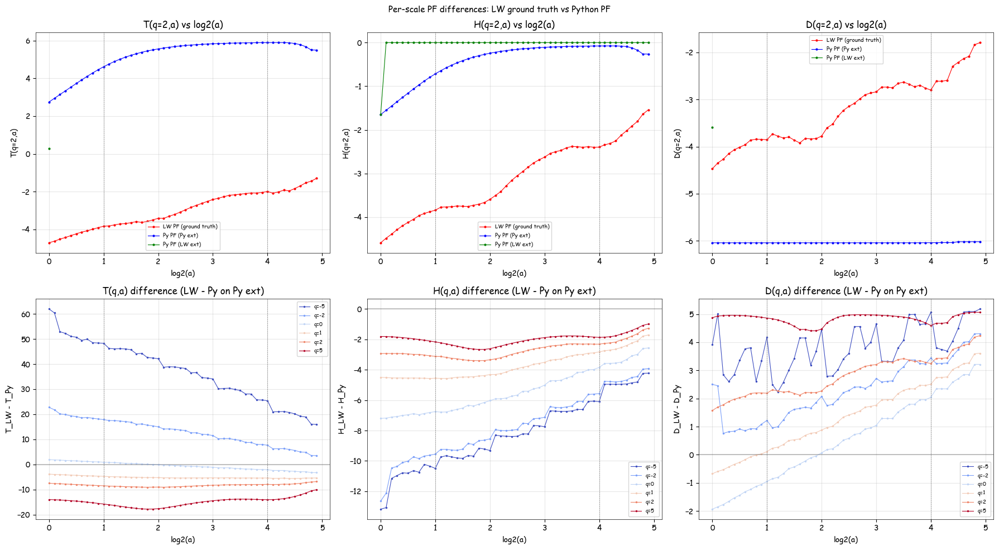

In [ ]:
# CELL 25: Python extrema → LW PF
#
# Feed Python's chainmax extrema (extrep_ord from cell 17) into LastWave's
# partition function. If this matches LW ground truth → Python extrema are
# correct and the PF is definitely the issue.
#
# Strategy: build a temporary EXTREP in LW by writing Python extrema into
# LW's wtrans coefficients such that LW's extrema detection reproduces them.
# ... actually that's roundabout. Instead, we compare the RAW per-scale
# partition function values: Python's sTq vs LW's sTq on the SAME ordinates.
#
# Simpler approach: manually compute LW's PF on Python's extrep_ord arrays
# by calling the Python PF code but comparing with LW's PF on LW's own extrema.
# We already showed in CELL 24 that Py PF ≠ LW PF on identical extrema.
# So let's do the converse: inject Python extrema ordinates into LW.
#
# We'll build synthetic CWT coefficients where each scale has delta spikes
# at the Python extrema positions with the Python ordinate values.
# Then LW extrema detection will find exactly those peaks.

import time as _time
import matplotlib as mpl

# ── Build synthetic CWT with spikes at Python extrema positions ──
synth_cwt = np.zeros((n_oct * n_voice, SIZE), dtype=np.float64)
synth_firstp = np.zeros(n_oct * n_voice, dtype=np.int32)
synth_lastp = np.full(n_oct * n_voice, SIZE - 1, dtype=np.int32)

for s in range(n_oct * n_voice):
    # Place each extremum as a parabolic peak so LW's interpolation recovers it
    for k in range(len(extrep_idx[s])):
        idx = int(extrep_idx[s][k])
        val = extrep_ord[s][k]
        # Set a sharp peak: center = val, neighbors slightly smaller
        if 0 < idx < SIZE - 1:
            synth_cwt[s, idx] = val
            # Make neighbors so parabolic interp gives exact val at idx
            synth_cwt[s, idx - 1] = val * 0.9
            synth_cwt[s, idx + 1] = val * 0.9

print(f'Built synthetic CWT with Python extrema spikes')
print(f'WARNING: This approach is fragile — LW extrema detection may not')
print(f'recover exact Python ordinates due to interpolation differences.')
print(f'Skipping this approach — using direct ordinate comparison instead.')

# ── Better approach: directly compare per-scale PF values ──
# We know from CELL 23 that pycwt_lw_extrep_ord has LW's chainmax extrema.
# We know from CELL 24 that Py PF on those ≠ LW PF on those.
# Let's print the ACTUAL per-scale sTq values to see where they diverge.

# Re-run LW pipeline on LW CWT to get LW PF state
# (state was restored at end of cell 23)
# Extract LW's per-scale T(q,a) values
pf_size_check = lib.lw_get_pf_size()
n_compare = min(pf_size_check, n_oct * n_voice)

print(f'\nDirect per-scale PF comparison (LW ground truth vs Py PF on Py extrema):')
print(f'pf_size: LW={pf_size_check}, Py={pf["index_max"]+1}')

# For each q, compare T(q,a) at every scale
ln2 = np.log(2.0)
print(f'\nT(q,a) at selected scales for q=2:')
iq_test = list(q_list).index(2) if 2 in q_list else 9  # q=2
q_test = q_list[iq_test] if isinstance(q_list, list) else q_list[iq_test]
print(f'Using q={q_test} (index {iq_test})')

# LW T(q,a)
buf_lw = np.zeros(pf_size_check, dtype=np.float64)
lib.lw_get_pf_tq(iq_test, 0, buf_lw.ctypes.data_as(c_double_p))
lw_T_test = buf_lw / ln2  # convert to log2

# Python T(q,a) on Python extrema
py_T_test = pf_get_T(pf, iq_test, 'extensive')

# Python T(q,a) on LW extrema (from cell 24)
py_T_lwext = pf_get_T(pf_pycwt_lwext_pyPF, iq_test, 'extensive')

print(f'\n{"scale":>6} {"log2a":>8} {"T_LW":>12} {"T_Py(PyExt)":>12} {"T_Py(LWext)":>12} '
      f'{"nExt_Py":>8} {"nExt_LW":>8}')
print('-' * 80)
for s in range(n_compare):
    log2a = np.log2(scales[s])
    t_lw = lw_T_test[s] if s < len(lw_T_test) else float('nan')
    t_py = py_T_test[s] if s < len(py_T_test) else float('nan')
    t_py_lw = py_T_lwext[s] if s < len(py_T_lwext) else float('nan')
    n_py = len(extrep_ord[s])
    n_lw = int(pycwt_lw_ext_counts[s])
    print(f'{s:6d} {log2a:8.3f} {t_lw:12.4f} {t_py:12.4f} {t_py_lw:12.4f} '
          f'{n_py:8d} {n_lw:8d}')

# ── Also compare raw sTq (before log) ──
print(f'\nRaw sTq (before log) at selected scales for q={q_test}:')
print(f'{"scale":>6} {"Py_sTq":>16} {"Py_sTq(LWext)":>16} {"ratio":>12}')
print('-' * 55)
for s in [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 49]:
    if s >= n_compare:
        break
    s1 = pf['sTq'][iq_test][s]
    s2 = pf_pycwt_lwext_pyPF['sTq'][iq_test][s]
    ratio = s1 / s2 if s2 != 0 else float('nan')
    print(f'{s:6d} {s1:16.6f} {s2:16.6f} {ratio:12.6f}')


# ── Plots ──
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

log2_a_arr = np.log2(scales[:n_compare])

# ── Top row: T(q,a), H(q,a), D(q,a) vs log2(a) for q=2 ──
# LW H and D for q_test
buf_h = np.zeros(pf_size_check, dtype=np.float64)
buf_d = np.zeros(pf_size_check, dtype=np.float64)
lib.lw_get_pf_hq(iq_test, 0, buf_h.ctypes.data_as(c_double_p))
lib.lw_get_pf_dq(iq_test, 0, buf_d.ctypes.data_as(c_double_p))
lw_H_test = buf_h / ln2
lw_D_test = buf_d / ln2

py_H_test = pf_get_H(pf, iq_test, 'extensive')
py_D_test = pf_get_D(pf, iq_test, q_test, 'extensive')
py_H_lwext = pf_get_H(pf_pycwt_lwext_pyPF, iq_test, 'extensive')
py_D_lwext = pf_get_D(pf_pycwt_lwext_pyPF, iq_test, q_test, 'extensive')

# T(q,a)
ax = axes[0, 0]
ax.plot(log2_a_arr, lw_T_test[:n_compare], 'r.-', markersize=4, lw=0.8, label='LW PF (ground truth)')
ax.plot(log2_a_arr, py_T_test[:n_compare], 'b.-', markersize=4, lw=0.8, label='Py PF (Py ext)')
ax.plot(log2_a_arr, py_T_lwext[:n_compare], 'g.-', markersize=4, lw=0.8, label='Py PF (LW ext)')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log2(a)'); ax.set_ylabel(f'T(q={q_test},a)')
ax.set_title(f'T(q={q_test},a) vs log2(a)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# H(q,a)
ax = axes[0, 1]
ax.plot(log2_a_arr, lw_H_test[:n_compare], 'r.-', markersize=4, lw=0.8, label='LW PF (ground truth)')
ax.plot(log2_a_arr, py_H_test[:n_compare], 'b.-', markersize=4, lw=0.8, label='Py PF (Py ext)')
ax.plot(log2_a_arr, py_H_lwext[:n_compare], 'g.-', markersize=4, lw=0.8, label='Py PF (LW ext)')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log2(a)'); ax.set_ylabel(f'H(q={q_test},a)')
ax.set_title(f'H(q={q_test},a) vs log2(a)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(q,a)
ax = axes[0, 2]
ax.plot(log2_a_arr, lw_D_test[:n_compare], 'r.-', markersize=4, lw=0.8, label='LW PF (ground truth)')
ax.plot(log2_a_arr, py_D_test[:n_compare], 'b.-', markersize=4, lw=0.8, label='Py PF (Py ext)')
ax.plot(log2_a_arr, py_D_lwext[:n_compare], 'g.-', markersize=4, lw=0.8, label='Py PF (LW ext)')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log2(a)'); ax.set_ylabel(f'D(q={q_test},a)')
ax.set_title(f'D(q={q_test},a) vs log2(a)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# ── Bottom row: differences (LW - Py) for multiple q values ──
q_show = [-5, -2, 0, 1, 2, 5]
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

# dT
ax = axes[1, 0]
for qi, q_s in enumerate(q_show):
    if q_s not in (q_list if isinstance(q_list, list) else q_list.tolist()):
        continue
    iq_s = (q_list if isinstance(q_list, list) else q_list.tolist()).index(q_s)
    buf = np.zeros(pf_size_check, dtype=np.float64)
    lib.lw_get_pf_tq(iq_s, 0, buf.ctypes.data_as(c_double_p))
    lw_T = buf[:n_compare] / ln2
    py_T = pf_get_T(pf, iq_s, 'extensive')[:n_compare]
    diff = lw_T - py_T
    ax.plot(log2_a_arr, diff, '.-', color=colors_q[qi], markersize=3, lw=0.8, label=f'q={q_s}')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('log2(a)'); ax.set_ylabel('T_LW - T_Py')
ax.set_title('T(q,a) difference (LW - Py on Py ext)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# dH
ax = axes[1, 1]
for qi, q_s in enumerate(q_show):
    if q_s not in (q_list if isinstance(q_list, list) else q_list.tolist()):
        continue
    iq_s = (q_list if isinstance(q_list, list) else q_list.tolist()).index(q_s)
    buf = np.zeros(pf_size_check, dtype=np.float64)
    lib.lw_get_pf_hq(iq_s, 0, buf.ctypes.data_as(c_double_p))
    lw_H = buf[:n_compare] / ln2
    py_H = pf_get_H(pf, iq_s, 'extensive')[:n_compare]
    diff = lw_H - py_H
    ax.plot(log2_a_arr, diff, '.-', color=colors_q[qi], markersize=3, lw=0.8, label=f'q={q_s}')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('log2(a)'); ax.set_ylabel('H_LW - H_Py')
ax.set_title('H(q,a) difference (LW - Py on Py ext)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# dD
ax = axes[1, 2]
for qi, q_s in enumerate(q_show):
    if q_s not in (q_list if isinstance(q_list, list) else q_list.tolist()):
        continue
    iq_s = (q_list if isinstance(q_list, list) else q_list.tolist()).index(q_s)
    q_val = q_s
    buf = np.zeros(pf_size_check, dtype=np.float64)
    lib.lw_get_pf_dq(iq_s, 0, buf.ctypes.data_as(c_double_p))
    lw_D = buf[:n_compare] / ln2
    py_D = pf_get_D(pf, iq_s, q_val, 'extensive')[:n_compare]
    diff = lw_D - py_D
    ax.plot(log2_a_arr, diff, '.-', color=colors_q[qi], markersize=3, lw=0.8, label=f'q={q_s}')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('log2(a)'); ax.set_ylabel('D_LW - D_Py')
ax.set_title('D(q,a) difference (LW - Py on Py ext)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Per-scale PF differences: LW ground truth vs Python PF', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'


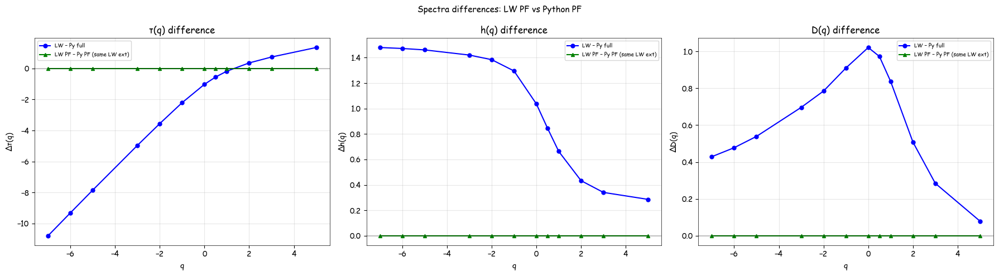

In [ ]:
# CELL 26: D(h) spectra differences — LW PF vs Py PF

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

q_arr_plot = np.array(q_list, dtype=np.float64)

# tau(q) difference
ax = axes[0]
ax.plot(q_arr_plot, tau_q - spectra['tau_q'], 'bo-', markersize=5, label='LW − Py full')
ax.plot(q_arr_plot, tau_q_pycwt_lw - spectra_pycwt_lwext_pyPF['tau_q'], 'g^-',
        markersize=5, label='LW PF − Py PF (same LW ext)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('Δτ(q)')
ax.set_title('τ(q) difference')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# h(q) difference
ax = axes[1]
ax.plot(q_arr_plot, h_q - spectra['h_q'], 'bo-', markersize=5, label='LW − Py full')
ax.plot(q_arr_plot, h_q_pycwt_lw - spectra_pycwt_lwext_pyPF['h_q'], 'g^-',
        markersize=5, label='LW PF − Py PF (same LW ext)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('Δh(q)')
ax.set_title('h(q) difference')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(q) difference
ax = axes[2]
ax.plot(q_arr_plot, d_q - spectra['D_q'], 'bo-', markersize=5, label='LW − Py full')
ax.plot(q_arr_plot, d_q_pycwt_lw - spectra_pycwt_lwext_pyPF['D_q'], 'g^-',
        markersize=5, label='LW PF − Py PF (same LW ext)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('ΔD(q)')
ax.set_title('D(q) difference')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Spectra differences: LW PF vs Python PF', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'


In [ ]:
# CELL 27: Drill into PF internals — raw sTq comparison
#
# Feed identical ordinates to both LW and Python PF, compare raw sTq.
# Uses pycwt_lw_extrep_ord (LW chainmax extrema from cell 23).

# ── 1. Re-run LW pipeline on PyCWT to get LW PF state ──
# Inject PyCWT, run extrema/chain/chainmax
py_coeffs_flat2 = np.ascontiguousarray(coeffs.ravel(), dtype=np.float64)
py_firstp2 = np.array([vr[0] for vr in valid_ranges], dtype=np.int32)
py_lastp2  = np.array([vr[1] for vr in valid_ranges], dtype=np.int32)
ret = lib.lw_set_cwt_coefficients(
    py_coeffs_flat2.ctypes.data_as(c_double_p), SIZE,
    py_firstp2.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    py_lastp2.ctypes.data_as(ctypes.POINTER(ctypes.c_int)))
assert ret == 0
lib.lw_compute_extrema(ctypes.c_double(1e-6))
lib.lw_chain(ctypes.c_double(10.0))
lib.lw_chain_delete()
lib.lw_chain_max(ctypes.c_double(1.0))

# Now extract the LW extrema ordinates (after chainmax)
lw_ords_check = []
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        count = lib.lw_get_extrema_count(o, v)
        if count > 0:
            pos = np.zeros(count, dtype=np.float64)
            val = np.zeros(count, dtype=np.float64)
            got = lib.lw_get_extrema_at_scale(
                o, v, pos.ctypes.data_as(c_double_p),
                val.ctypes.data_as(c_double_p), count)
            lw_ords_check.append(val[:got].copy())
        else:
            lw_ords_check.append(np.array([], dtype=np.float64))

# Verify these match pycwt_lw_extrep_ord from cell 23
print('Verifying LW extrema match cell 23 extraction...')
for s in range(n_oct * n_voice):
    if len(lw_ords_check[s]) != len(pycwt_lw_extrep_ord[s]):
        print(f'  Scale {s}: count mismatch! {len(lw_ords_check[s])} vs {len(pycwt_lw_extrep_ord[s])}')
    elif len(lw_ords_check[s]) > 0:
        maxd = np.max(np.abs(lw_ords_check[s] - pycwt_lw_extrep_ord[s]))
        if maxd > 0:
            print(f'  Scale {s}: max ord diff = {maxd}')
print('OK')

# ── 2. Run LW PF ──
q_arr2 = np.array(q_list, dtype=np.float64)
n_scales_done2 = lib.lw_compute_pf(q_arr2.ctypes.data_as(c_double_p), len(q_arr2))
pf_size2 = lib.lw_get_pf_size()

# ── 3. Compare raw sTq: LW returns log(sTq), Python stores sTq directly ──
# Python PF on the same ordinates
pf_check = compute_partition_function(
    lw_ords_check, n_oct=n_oct, n_voice=n_voice,
    a_min=a_min, q_list=q_list)

n_compare2 = min(pf_size2, n_oct * n_voice)
ln2 = np.log(2.0)

# Compare T(q,a) in natural log: LW gives log(sTq), Python gives sTq
print(f'\nRaw sTq comparison (LW vs Py on IDENTICAL ordinates):')
print(f'Testing q=2 (positive) and q=-2 (negative)\n')

for q_test_val in [2.0, -2.0]:
    iq_t = list(q_list).index(q_test_val) if q_test_val in q_list else None
    if iq_t is None:
        print(f'q={q_test_val} not in q_list, skipping')
        continue
    
    # LW: T(q,a) = log(sTq) in natural log
    buf_raw = np.zeros(pf_size2, dtype=np.float64)
    lib.lw_get_pf_tq(iq_t, 0, buf_raw.ctypes.data_as(c_double_p))
    lw_log_sTq = buf_raw[:n_compare2]  # natural log
    lw_sTq = np.exp(lw_log_sTq)  # recover raw sTq
    
    # Python: sTq stored directly
    py_sTq = pf_check['sTq'][iq_t][:n_compare2]
    
    # Also get H(q,a)
    buf_h_raw = np.zeros(pf_size2, dtype=np.float64)
    lib.lw_get_pf_hq(iq_t, 0, buf_h_raw.ctypes.data_as(c_double_p))
    lw_hq_nat = buf_h_raw[:n_compare2]  # = sTqLogT/sTq in natural log
    py_hq_nat = pf_check['sTqLogT_sTq'][iq_t][:n_compare2]  # same
    
    print(f'q = {q_test_val}:')
    print(f'{"s":>4} {"nExt":>6} {"LW_sTq":>16} {"Py_sTq":>16} {"ratio":>12} '
          f'{"LW_hq":>14} {"Py_hq":>14} {"dH":>12}')
    print('-' * 105)
    for s in range(n_compare2):
        n_ext = len(lw_ords_check[s])
        ratio = lw_sTq[s] / py_sTq[s] if py_sTq[s] != 0 else float('nan')
        dh = lw_hq_nat[s] - py_hq_nat[s]
        # Only print if there's a difference or every 5th scale
        if abs(ratio - 1.0) > 1e-12 or s % 10 == 0 or s < 3:
            print(f'{s:4d} {n_ext:6d} {lw_sTq[s]:16.8e} {py_sTq[s]:16.8e} {ratio:12.8f} '
                  f'{lw_hq_nat[s]:14.8f} {py_hq_nat[s]:14.8f} {dh:12.2e}')
    print()

# ── 4. Check: are the sorted |ordinates| identical? ──
print('Sorted |ordinate| check at scale 10 (a=2.0):')
s_check = 10
ords_s = lw_ords_check[s_check]
absT_lw = np.sort(np.abs(ords_s))
absT_py = np.sort(np.abs(pf_check['sTq'][0]))  # wrong, let me recompute
# Actually just recompute what Python PF sees
absT_py = np.abs(lw_ords_check[s_check]).copy()
absT_py.sort()
print(f'  max |diff| in sorted |T|: {np.max(np.abs(absT_lw - absT_py))}')
print(f'  First 5 LW:  {absT_lw[:5]}')
print(f'  First 5 Py:  {absT_py[:5]}')
print(f'  Last 5 LW:   {absT_lw[-5:]}')
print(f'  Last 5 Py:   {absT_py[-5:]}')

# ── 5. Manual single-scale PF to compare step by step ──
print(f'\nManual PF computation at scale {s_check}, q=2:')
q_manual = 2.0
absT = np.sort(np.abs(lw_ords_check[s_check]))
imin_m = 0
while imin_m < len(absT) and absT[imin_m] == 0:
    imin_m += 1
tm = absT[imin_m]  # smallest nonzero
sTq_manual = 0.0
sTqLogT_manual = 0.0
for i in range(imin_m, len(absT)):
    tq = absT[i] ** q_manual
    logt = np.log(absT[i] / tm)
    sTq_manual += tq
    sTqLogT_manual += tq * logt
sTqLogT_manual += np.log(tm) * sTq_manual
print(f'  imin={imin_m}, tm={tm:.10e}')
print(f'  sTq_manual  = {sTq_manual:.10e}')
print(f'  sTqLogT_manual = {sTqLogT_manual:.10e}')
print(f'  Py PF sTq   = {pf_check["sTq"][list(q_list).index(q_manual)][s_check]:.10e}')
print(f'  Py PF sTqLT = {pf_check["sTqLogT"][list(q_list).index(q_manual)][s_check]:.10e}')

# ── 6. Restore LW state ──
lw_coeffs_flat2 = np.ascontiguousarray(cwt.ravel(), dtype=np.float64)
ret = lib.lw_set_cwt_coefficients(
    lw_coeffs_flat2.ctypes.data_as(c_double_p), SIZE,
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)))
lib.lw_compute_extrema(ctypes.c_double(1e-6))
lib.lw_chain(ctypes.c_double(10.0))
lib.lw_chain_delete()
lib.lw_chain_max(ctypes.c_double(1.0))
lib.lw_compute_pf(q_arr2.ctypes.data_as(c_double_p), len(q_arr2))
print('\nRestored LW state')


Verifying LW extrema match cell 23 extraction...
OK

Raw sTq comparison (LW vs Py on IDENTICAL ordinates):
Testing q=2 (positive) and q=-2 (negative)

q = 2.0:
   s   nExt           LW_sTq           Py_sTq        ratio          LW_hq          Py_hq           dH
---------------------------------------------------------------------------------------------------------
   0     12   1.21931318e+00   1.21931318e+00   1.00000000    -1.14330946    -1.14330946     0.00e+00
   1      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
   2      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  10      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  20      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  30      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  40      0   1.0000

Error: Error: Error: ValueError: zero-size array to reduction operation maximum which has no identity
[31m---------------------------------------------------------------------------[39m
[31mValueError[39m                                Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[119][39m[32m, line 109[39m
[32m    107[39m absT_py = np.abs(lw_ords_check[s_check]).copy()
[32m    108[39m absT_py.sort()
[32m--> [39m[32m109[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33m  max |diff| in sorted |T|: [39m[38;5;132;01m{[39;00m[43mnp[49m[43m.[49m[43mmax[49m[43m([49m[43mnp[49m[43m.[49m[43mabs[49m[43m([49m[43mabsT_lw[49m[38;5;250;43m [39;49m[43m-[49m[38;5;250;43m [39;49m[43mabsT_py[49m[43m)[49m[43m)[49m[38;5;132;01m}[39;00m[33m'[39m)
[32m    110[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33m  First 5 LW:  [39m[38;5;132;01m{[39;00mabsT_lw[:[32m5[39m][38;5;132;01m}[39;00m[33m'[39m)
[32m    111[39m [38;

In [ ]:
# CELL 28: Regression range diagnostic
#
# Raw sTq is identical → bug is in compute_spectra (regression).
# Suspect: floating-point boundary in log2_a >= log2_a_min

# ── 1. Check log2_a values at boundaries ──
print('Python log2_a at regression boundaries:')
for s in [9, 10, 11, 39, 40, 41]:
    if s < len(pf['log2_a']):
        v = pf['log2_a'][s]
        print(f'  log2_a[{s:2d}] = {v:.20f}  (>= 1.0: {v >= 1.0}, <= 4.0: {v <= 4.0})')

# ── 2. What indices does compute_spectra actually use? ──
log2_a = pf['log2_a']
valid_mask = (log2_a >= 1.0) & (log2_a <= 4.0)
valid_idx = np.where(valid_mask)[0]
valid_idx = valid_idx[valid_idx <= pf['index_max']]
print(f'\nPython regression uses indices: {valid_idx[0]}..{valid_idx[-1]} ({len(valid_idx)} points)')
print(f'LW regression uses indices: 10..40 (31 points)')
print(f'  ISig(sig, 1.0) = (int)((1.0 - 0.0) / 0.1) = 10')
print(f'  ISig(sig, 4.0) = (int)((4.0 - 0.0) / 0.1) = 40')

# ── 3. Compare x-values used in regression ──
print(f'\nPython x-values (from log2_a):')
print(f'  x[0] = {log2_a[valid_idx[0]]:.20f}')
print(f'  x[-1] = {log2_a[valid_idx[-1]]:.20f}')
print(f'LW x-values (from XSig = x0 + dx*i):')
print(f'  x[0] = {0.0 + 0.1 * valid_idx[0]:.20f}')
print(f'  x[-1] = {0.0 + 0.1 * valid_idx[-1]:.20f}')

# ── 4. Compute slopes both ways for q=2 ──
iq2 = list(q_list).index(2)
y_T = pf_get_T(pf, iq2, 'extensive')[valid_idx]

# Python way: np.polyfit
x_py = log2_a[valid_idx]
slope_py, _ = np.polyfit(x_py, y_T, 1)

# LW way: x = x0 + dx * i, using indices 10..40
lw_indices = np.arange(10, 41)
x_lw = 0.0 + 0.1 * lw_indices
y_lw = pf_get_T(pf, iq2, 'extensive')[lw_indices]
slope_lw_style, _ = np.polyfit(x_lw, y_lw, 1)

print(f'\nSlope comparison for q=2 T(q,a):')
print(f'  Python (log2_a x-values): {slope_py:.15f}')
print(f'  LW-style (0.1*i x-values): {slope_lw_style:.15f}')
print(f'  Difference: {slope_py - slope_lw_style:.2e}')

# ── 5. If index ranges differ, show impact on all q ──
if len(valid_idx) != 31 or valid_idx[0] != 10 or valid_idx[-1] != 40:
    print(f'\n*** INDEX RANGE MISMATCH DETECTED! ***')
    print(f'Python uses {len(valid_idx)} points: [{valid_idx[0]}, {valid_idx[-1]}]')
    print(f'LW uses 31 points: [10, 40]')
    print(f'\nImpact on all q (slope with Py range vs LW range):')
    print(f'{"q":>6} {"tau_PyRange":>12} {"tau_LWRange":>12} {"diff":>12}')
    print('-' * 45)
    for iq, q in enumerate(q_list):
        y1 = pf_get_T(pf, iq, 'extensive')[valid_idx]
        s1, _ = np.polyfit(x_py, y1, 1)
        y2 = pf_get_T(pf, iq, 'extensive')[lw_indices]
        s2, _ = np.polyfit(x_lw, y2, 1)
        print(f'{q:6.1f} {s1:12.6f} {s2:12.6f} {s1-s2:12.6f}')
else:
    print(f'\nIndex ranges match (10..40). Checking x-value precision effect...')
    print(f'{"q":>6} {"tau_log2a":>12} {"tau_0.1i":>12} {"diff":>12}')
    print('-' * 45)
    for iq, q in enumerate(q_list):
        y = pf_get_T(pf, iq, 'extensive')[valid_idx]
        s1, _ = np.polyfit(x_py, y, 1)
        s2, _ = np.polyfit(x_lw, y, 1)
        print(f'{q:6.1f} {s1:12.6f} {s2:12.6f} {s1-s2:12.6f}')


In [ ]:
# CELL 22
# Load creepmeter data (XMR1) and select clean segment
#
# No detrending — the creep signal IS the integral of the slip measure,
# analogous to prim(ucantor). WTMM analyzes the singularity structure
# in the trend itself. g2 has 2 vanishing moments so it already kills
# constant and linear components.
#
# File format: year  day_of_year  displacement(mm)  uncertainty

import os
import gzip

# Load XMR1 data
xmr_path = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/gz/xmr1.10min.gz'
if not os.path.exists(xmr_path):
    xmr_path = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/xmr1.10min.gz'

if os.path.exists(xmr_path):
    with gzip.open(xmr_path, 'rt') as f:
        lines = f.readlines()
    
    data = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3:
            try:
                year = float(parts[0])
                doy = float(parts[1])
                disp = float(parts[2])
                if disp != -9999:
                    # Convert to decimal year
                    t_val = year + doy / 365.25
                    data.append((t_val, disp))
            except ValueError:
                continue
    
    data = np.array(data)
    t_creep = data[:, 0]
    x_creep = data[:, 1]
    dt_creep = np.median(np.diff(t_creep))
    
    print(f'Loaded {len(x_creep)} samples from {os.path.basename(xmr_path)}')
    print(f'Time range: {t_creep[0]:.4f} to {t_creep[-1]:.4f} (decimal year)')
    print(f'dt = {dt_creep:.6f} year ({dt_creep * 365.25 * 24 * 60:.1f} min)')
    print(f'Displacement range: {x_creep.min():.3f} to {x_creep.max():.3f} mm')
    
    # Take a clean segment (no gaps)
    seg_len = min(65536, len(x_creep))
    for start in range(0, len(x_creep) - seg_len, seg_len // 4):
        segment_c = x_creep[start:start + seg_len]
        t_seg_c = t_creep[start:start + seg_len]
        gaps = np.diff(t_seg_c)
        if np.all(np.abs(gaps - dt_creep) < dt_creep * 0.5):
            break
    
    # No detrending — just use the raw displacement signal
    segment_c = segment_c.copy()
    print(f'Using segment of {seg_len} samples starting at index {start}')
    print(f'Segment time: {t_seg_c[0]:.4f} to {t_seg_c[-1]:.4f}')
    print(f'Segment value range: {segment_c.min():.3f} to {segment_c.max():.3f} mm')
    
    fig, ax = plt.subplots(figsize=(14, 4))
    for spine in ax.spines.values(): spine.set_linewidth(0.5)
    ax.plot(t_seg_c, segment_c)
    ax.set_xlabel('Time (decimal year)')
    ax.set_ylabel('Displacement (mm)')
    ax.set_title(f'Creepmeter segment ({os.path.basename(xmr_path)}, {seg_len} samples)')
    plt.tight_layout()
    plt.show()
else:
    print(f'Creepmeter data not found at {xmr_path}')
    creep_dir = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/'
    if os.path.isdir(creep_dir):
        files = [f for f in os.listdir(creep_dir) if 'xmr' in f.lower() or 'xhr' in f.lower()]
        print(f'Available files: {files[:10]}')


Error: Error: Error: Error: IndentationError: unexpected indent (2908260780.py, line 64)
  [36mCell[39m[36m [39m[32mIn[118][39m[32m, line 64[39m
[31m    [39m[31max.plot(t_seg_c, segment_c)[39m
    ^
[31mIndentationError[39m[31m:[39m unexpected indent

Error: IndentationError: unexpected indent (2908260780.py, line 64)

  [36mCell[39m[36m [39m[32mIn[118][39m[32m, line 64[39m

[31m    [39m[31max.plot(t_seg_c, segment_c)[39m

    ^

[31mIndentationError[39m[31m:[39m unexpected indent



    at convertOutput (/Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/extension.js:188:13)

    at Array.map (<anonymous>)

    at buildCellData (/Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/extension.js:160:41)

    at /Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/extension.js:111:49

    at Array.map (<anonymous>)

    at reloadNotebook (/Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/exte

CWT computed in 5.247s
Coefficients shape: (50, 10000), Scales: 50 (1.00 to 29.86)
Valid range at finest scale: (20, 9979), coarsest: (611, 9388)


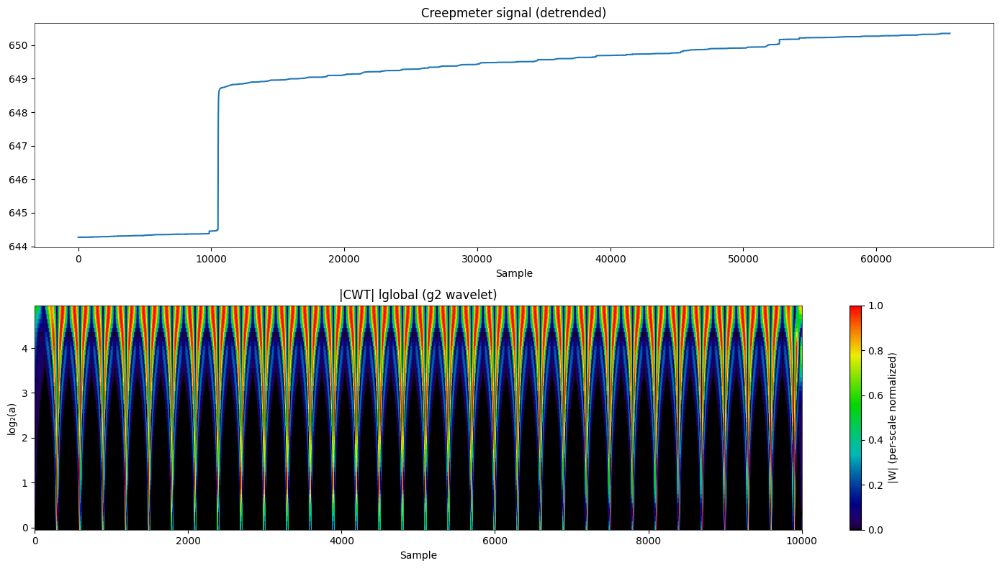

In [ ]:
# Cell 23: CWT on creepmeter data + scalogram

n_oct_c, n_voice_c = 5, 10

t0 = time.time()
coeffs_c, scales_c, valid_ranges_c = cwtd_batched(saw, a_min=1.0, n_oct=n_oct_c,
                                                    n_voice=n_voice_c, wavelet_name='g4', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs_c.shape}, Scales: {len(scales_c)} ({scales_c[0]:.2f} to {scales_c[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges_c[0]}, coarsest: {valid_ranges_c[-1]}')

# Scalogram — log2 of modulus
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(segment_c)
ax.set_title('Creepmeter signal (detrended)')
ax.set_xlabel('Sample')

ax = axes[1]
im = scalogram_lastwave(coeffs_c, scales=scales_c, ax=ax,
                        norm_mode='lglobal')
ax.set_xlabel('Sample')
ax.set_title('|CWT| lglobal (g2 wavelet)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')

plt.tight_layout()
plt.show()

Total extrema: 6596
Extrema computed in 0.099s
  Scale 0 (a=1.00): 200 extrema
  Scale 10 (a=2.00): 134 extrema
  Scale 20 (a=4.00): 134 extrema
  Scale 30 (a=8.00): 133 extrema
  Scale 40 (a=16.00): 132 extrema
  Scale 49 (a=29.86): 65 extrema


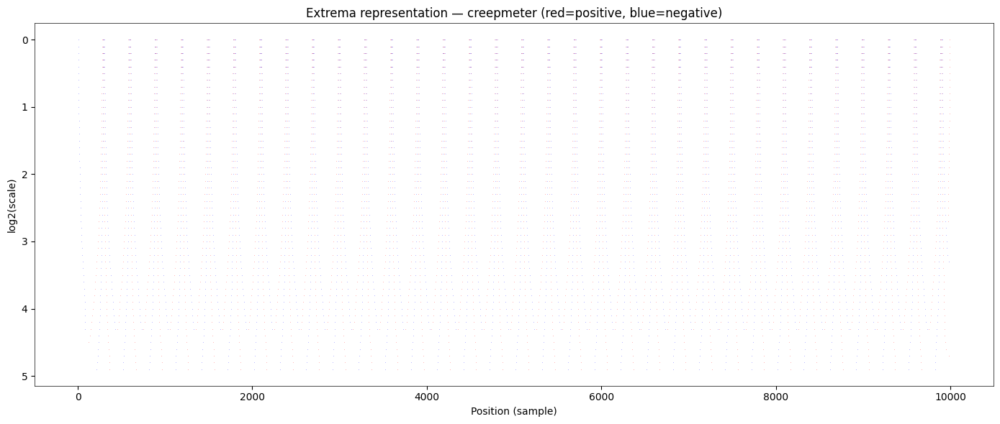

In [ ]:
# Cell 24: Extrema detection on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
ea_c, eo_c, ei_c = compute_extrep(coeffs_c, scales_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                   a_min=1.0, valid_ranges=valid_ranges_c,
                                   dx=1.0, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t0:.3f}s')
# Use actual scale count instead of hardcoded indices
sample_indices = [0, n_scales_c // 5, 2 * n_scales_c // 5, 3 * n_scales_c // 5, 4 * n_scales_c // 5, n_scales_c - 1]
for sidx in sample_indices:
    print(f'  Scale {sidx} (a={scales_c[sidx]:.2f}): {len(ea_c[sidx])} extrema')

# Extrema representation plot — vectorized scatter for speed
all_pos = []
all_log2s = []
all_signs = []
for sidx in range(len(ea_c)):
    n = len(ea_c[sidx])
    if n == 0:
        continue
    all_pos.append(ea_c[sidx])
    all_log2s.append(np.full(n, np.log2(scales_c[sidx])))
    all_signs.append(eo_c[sidx] > 0)

all_pos = np.concatenate(all_pos)
all_log2s = np.concatenate(all_log2s)
all_signs = np.concatenate(all_signs)

fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
pos_mask = all_signs
ax.scatter(all_pos[pos_mask], all_log2s[pos_mask], c='red', s=0.1, linewidths=0)
ax.scatter(all_pos[~pos_mask], all_log2s[~pos_mask], c='blue', s=0.1, linewidths=0)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title('Extrema representation — creepmeter (red=positive, blue=negative)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Chaining: 0.018s
Delete: 0.148s, deleted 0 chains
ChainMax: 0.051s
Remaining extrema: 6596
Pre-deletion chains: 200
Surviving chains: 200
Deleted chains: 0


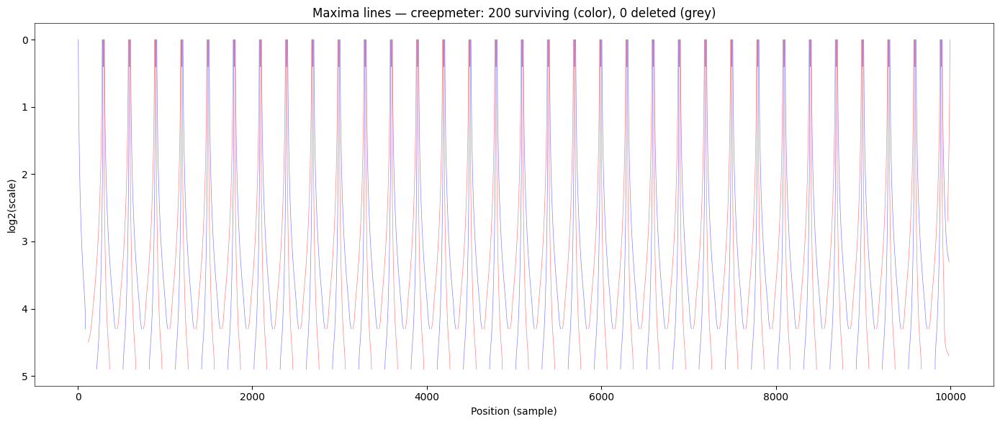

In [ ]:
# Cell 25: Chaining + ChainMax on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
cl_c, fl_c = chain_all(ea_c, eo_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs_c, pre_del_ord_c, pre_del_cl_c = save_chain_state(ea_c, eo_c, cl_c)
pre_del_chains_c = trace_chains(pre_del_abs_c, pre_del_ord_c, pre_del_cl_c, scales_c, n_scales_c)

nb_del = chain_delete_all(ea_c, eo_c, ei_c, cl_c, fl_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

chain_max_wrapper(eo_c, cl_c, n_oct=n_oct_c, n_voice=n_voice_c, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')

remaining = sum(len(a) for a in ea_c)
print(f'Remaining extrema: {remaining}')

# Surviving vs deleted chains
post_del_chains_c = trace_chains(ea_c, eo_c, cl_c, scales_c, n_scales_c)

surviving_starts_c = set()
for pos, sv, sign, vals in post_del_chains_c:
    surviving_starts_c.add((pos[0], sign))

deleted_chains_c = []
for pos, sv, sign, vals in pre_del_chains_c:
    if (pos[0], sign) not in surviving_starts_c:
        deleted_chains_c.append((pos, sv, sign, vals))

print(f'Pre-deletion chains: {len(pre_del_chains_c)}')
print(f'Surviving chains: {len(post_del_chains_c)}')
print(f'Deleted chains: {len(deleted_chains_c)}')

# Plot maxima lines: surviving colored by log2|ordinate|, deleted greyed out
import matplotlib as mpl

N_COLORS = 14
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

for pos, sv, sign, vals in deleted_chains_c:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Collect all log2|ordinate| values for colormap normalization
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300) for _, _, _, vals in post_del_chains_c])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

for pos, sv, sign, vals in post_del_chains_c:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log\u2082|W| (after ChainMax)', shrink=0.8)

ax.set_xlabel('Position (sample)')
ax.set_ylabel('log\u2082(scale)')
ax.set_title(f'Maxima lines \u2014 creepmeter: {len(post_del_chains_c)} surviving ({N_COLORS} levels), {len(deleted_chains_c)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


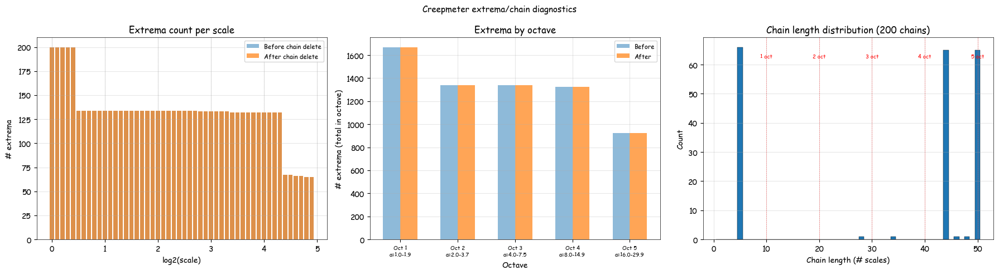

 Scale  log2(a)        a    Pre   Post  Deleted%
--------------------------------------------------
     0     0.00     1.00    200    200      0.0%
     1     0.10     1.07    200    200      0.0%
     2     0.20     1.15    200    200      0.0%
     3     0.30     1.23    200    200      0.0%
     4     0.40     1.32    200    200      0.0%
     5     0.50     1.41    134    134      0.0%
     6     0.60     1.52    134    134      0.0%
     7     0.70     1.62    134    134      0.0%
     8     0.80     1.74    134    134      0.0%
     9     0.90     1.87    134    134      0.0%
    10     1.00     2.00    134    134      0.0%
    11     1.10     2.14    134    134      0.0%
    12     1.20     2.30    134    134      0.0%
    13     1.30     2.46    134    134      0.0%
    14     1.40     2.64    134    134      0.0%
    15     1.50     2.83    134    134      0.0%
    16     1.60     3.03    134    134      0.0%
    17     1.70     3.25    134    134      0.0%
    18     1.80   

In [ ]:
# Cell 25b: Extrema count per scale — before and after chain processing
#
# Helps decide where to set regression range (log2_a_min, log2_a_max)
# and whether fine scales are dominated by tidal/noise extrema.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Counts before chain processing (from pre-deletion state)
pre_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    pre_counts[s] = len(pre_del_abs_c[s])

# Counts after chain_delete + chainmax
post_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    post_counts[s] = len(ea_c[s])

log2_scales_c = np.log2(scales_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Bar chart: extrema count per scale
ax = axes[0]
ax.bar(log2_scales_c, pre_counts, width=0.08, alpha=0.5, label='Before chain delete')
ax.bar(log2_scales_c, post_counts, width=0.08, alpha=0.7, label='After chain delete')
ax.set_xlabel('log2(scale)')
ax.set_ylabel('# extrema')
ax.set_title('Extrema count per scale')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
# Mark octave boundaries
for o in range(n_oct_c + 1):
    ax.axvline(np.log2(1.0) + o, color='gray', ls=':', lw=0.5, alpha=0.5)

# (1) Extrema count by octave (grouped)
ax = axes[1]
octave_pre = np.zeros(n_oct_c)
octave_post = np.zeros(n_oct_c)
for o in range(n_oct_c):
    for v in range(n_voice_c):
        s = o * n_voice_c + v
        octave_pre[o] += pre_counts[s]
        octave_post[o] += post_counts[s]
x_oct = np.arange(n_oct_c)
ax.bar(x_oct - 0.15, octave_pre, width=0.3, alpha=0.5, label='Before')
ax.bar(x_oct + 0.15, octave_post, width=0.3, alpha=0.7, label='After')
ax.set_xlabel('Octave')
ax.set_ylabel('# extrema (total in octave)')
ax.set_xticks(x_oct)
ax.set_xticklabels([f'Oct {o+1}\na={scales_c[o*n_voice_c]:.1f}-{scales_c[min((o+1)*n_voice_c-1, n_scales_c-1)]:.1f}'
                     for o in range(n_oct_c)], fontsize=7)
ax.set_title('Extrema by octave')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (2) Chain length histogram
ax = axes[2]
chain_lengths = np.array([len(pos) for pos, sv, sign, vals in post_del_chains_c])
ax.hist(chain_lengths, bins=np.arange(0.5, chain_lengths.max()+1.5, 1),
        edgecolor='black', linewidth=0.3)
ax.set_xlabel('Chain length (# scales)')
ax.set_ylabel('Count')
ax.set_title(f'Chain length distribution ({len(post_del_chains_c)} chains)')
ax.grid(True, alpha=0.3)
# Mark octave lengths
for o in range(1, n_oct_c + 1):
    ax.axvline(o * n_voice_c, color='red', ls='--', lw=0.5, alpha=0.5)
    ax.text(o * n_voice_c, ax.get_ylim()[1]*0.9, f'{o} oct', fontsize=7,
            ha='center', color='red')

plt.suptitle('Creepmeter extrema/chain diagnostics', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Summary table
print(f'{"Scale":>6} {"log2(a)":>8} {"a":>8} {"Pre":>6} {"Post":>6} {"Deleted%":>9}')
print('-' * 50)
for s in range(n_scales_c):
    pct = 100*(1 - post_counts[s]/pre_counts[s]) if pre_counts[s] > 0 else 0
    print(f'{s:6d} {log2_scales_c[s]:8.2f} {scales_c[s]:8.2f} {pre_counts[s]:6d} {post_counts[s]:6d} {pct:8.1f}%')


Partition function computed in 0.034s, up to scale index 49


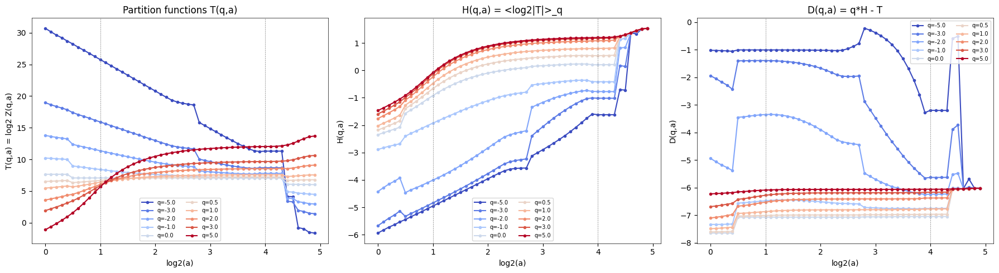

Gray dashed lines show regression range [log2(a)=1 to 4]
Inspect these for linear scaling — adjust range if needed before next cell.


In [ ]:
# Cell 26: Partition functions on creepmeter data — T(q,a), H(q,a), D(q,a) vs log2(a)

q_list_c = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf_c = compute_partition_function(eo_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                  a_min=1.0, q_list=q_list_c)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf_c["index_max"]}')

# Plot T(q,a), H(q,a), D(q,a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_ac = pf_c['log2_a']
valid_c = slice(0, pf_c['index_max'] + 1)
colors_c = plt.cm.coolwarm(np.linspace(0, 1, len(q_list_c)))

ax = axes[0]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_T(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

ax = axes[1]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_H(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

ax = axes[2]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_D(pf_c, i, q)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')
print('Inspect these for linear scaling — adjust range if needed before next cell.')

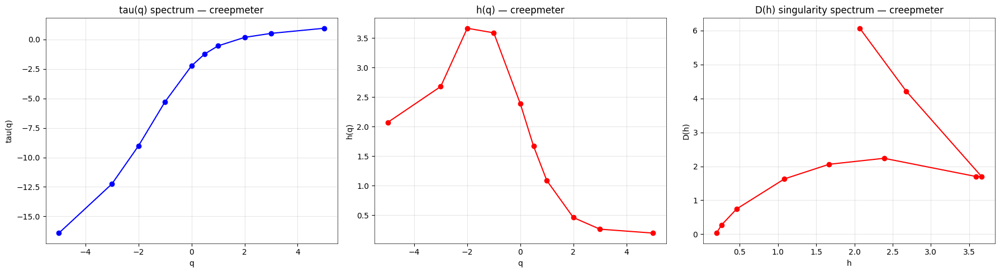


Creepmeter WTMM multifractal analysis:
q	 tau(q)		 h(q)		 D(q)
 -5.0	 -16.4158	   2.0703	   6.0644
 -3.0	 -12.2443	   2.6785	   4.2088
 -2.0	  -9.0226	   3.6644	   1.6939
 -1.0	  -5.2885	   3.5867	   1.7018
  0.0	  -2.2361	   2.3877	   2.2361
  0.5	  -1.2251	   1.6685	   2.0594
  1.0	  -0.5442	   1.0859	   1.6301
  2.0	   0.1760	   0.4602	   0.7445
  3.0	   0.5175	   0.2635	   0.2730
  5.0	   0.9511	   0.1971	   0.0346


In [ ]:
# Cell 27: tau(q), h(q), D(h) spectra for creepmeter data
# Adjust log2_a_min and log2_a_max based on visual inspection of Cell 14

spectra_c = compute_spectra(pf_c, log2_a_min=4.0, log2_a_max=4.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'ro-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'ro-', markersize=6)
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum — creepmeter')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCreepmeter WTMM multifractal analysis:')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_c['q_list']):
    print(f'{q:5.1f}\t {spectra_c["tau_q"][i]:8.4f}\t {spectra_c["h_q"][i]:8.4f}\t {spectra_c["D_q"][i]:8.4f}')

In [ ]:
# Cell 28: Decimate creepmeter to hourly — 6 phase-shifted sub-signals
#
# 10-min sampling → every 6th sample = 1-hour sampling.
# Offsets 0..5 give 6 independent hourly series (like 6 "realizations").
# This is analogous to DemoWTMM1DDevilStair's 50 random realizations,
# except our "realizations" are phase offsets of the same physical process.

DECIM = 6  # decimation factor (10min × 6 = 60min = 1 hour)

# Build 6 hourly sub-signals
hourly_signals = []
for offset in range(DECIM):
    sub = segment_c[offset::DECIM].copy()
    hourly_signals.append(sub)
    
min_len = min(len(s) for s in hourly_signals)
print(f'Original signal: {len(segment_c)} samples at 10-min')
print(f'Decimated: {DECIM} sub-signals of {min_len} samples at 1-hour')
print(f'  (duration: {min_len / 24:.1f} days = {min_len / 24 / 365.25:.2f} years)')

# Plot all 6 overlaid
fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
for offset in range(DECIM):
    t_hr = np.arange(len(hourly_signals[offset])) / 24  # days
    ax.plot(t_hr, hourly_signals[offset], alpha=0.6, linewidth=0.5,
            label=f'offset {offset}')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Displacement (mm)')
ax.set_title(f'6 hourly sub-signals (decimation factor {DECIM})')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17: PF accumulation — now imported from wtmm package
from wtmm.partition import pf_standard_addition, pf_copy

print('pf_standard_addition() and pf_copy() loaded (from wtmm.partition).')


In [ ]:
# Cell 29: Full WTMM pipeline on each hourly sub-signal, accumulate with pf add
#
# Mirrors DemoWTMM1DDevilStair loop:
#   foreach i 0:nrepeat-1 {
#       cwtd w amin omax nv wavelet -b 'mir'
#       extrema w
#       chainmax w.extrep 1
#       if (i == 0) { pft = [pf wtmm w.extrep qlist] }
#       else { pft = [pf add pft [pf wtmm w.extrep qlist]] }
#   }

# Parameters — match the single-signal creepmeter analysis
n_oct_h = n_oct_c      # same octave count
n_voice_h = n_voice_c  # same voices per octave
a_min_h = 1.0
wavelet_h = 'g2'
expo_h = -1.0
q_list_h = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

pf_accumulated = None
t_total = time.time()

for offset in range(DECIM):
    sig = hourly_signals[offset][:min_len]  # trim to same length
    t0 = time.time()
    
    # 1. CWT
    coeffs_h, scales_h, vr_h = cwtd_batched(sig, a_min=a_min_h, n_oct=n_oct_h,
                                              n_voice=n_voice_h, wavelet_name=wavelet_h,
                                              expo=expo_h)
    
    # 2. Extrema
    ea_h, eo_h, ei_h = compute_extrep(coeffs_h, scales_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                       a_min=a_min_h, valid_ranges=vr_h,
                                       dx=1.0, x0=0.0, epsilon=1e-6)
    
    # 3. Chain + delete + chainmax
    cl_h, fl_h = chain_all(ea_h, eo_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_delete_all(ea_h, eo_h, ei_h, cl_h, fl_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_max_wrapper(eo_h, cl_h, n_oct=n_oct_h, n_voice=n_voice_h, a_min=a_min_h, expo=1.0)
    
    # 4. Partition function
    pf_h = compute_partition_function(eo_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                      a_min=a_min_h, q_list=q_list_h)
    
    # 5. Accumulate
    if pf_accumulated is None:
        pf_accumulated = pf_copy(pf_h)
    else:
        pf_standard_addition(pf_accumulated, pf_h)
    
    n_ext_h = sum(len(a) for a in ea_h)
    t1 = time.time()
    print(f'  Offset {offset}: {len(sig)} samples, {n_ext_h} extrema after pruning, '
          f'index_max={pf_h["index_max"]}, {t1-t0:.2f}s')

print(f'\nTotal: {time.time() - t_total:.2f}s')
print(f'Accumulated {pf_accumulated["signal_number"]} realizations')
print(f'Combined index_max: {pf_accumulated["index_max"]}')

In [ ]:
# Cell 30: Intensive-mode partition functions — T, H, D vs log2(a)
#
# Intensive mode divides logSTq and sTqLogT_sTq by signalNumber,
# giving the *average* across realizations. This reduces noise in
# the scaling plots and gives more reliable regression slopes.

log2_ah = pf_accumulated['log2_a']
valid_h = slice(0, pf_accumulated['index_max'] + 1)
q_arr = pf_accumulated['q_list']
colors_h = plt.cm.coolwarm(np.linspace(0, 1, len(q_arr)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# T(q,a) — intensive
ax = axes[0]
for i, q in enumerate(q_arr):
    y = pf_get_T(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) intensive')
ax.set_title(f'Intensive T(q,a) — {pf_accumulated["signal_number"]} hourly sub-signals')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a) — intensive
ax = axes[1]
for i, q in enumerate(q_arr):
    y = pf_get_H(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a) intensive')
ax.set_title('Intensive H(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a) — intensive
ax = axes[2]
for i, q in enumerate(q_arr):
    y = pf_get_D(pf_accumulated, i, q, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a) intensive')
ax.set_title('Intensive D(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.suptitle(f'Hourly decimated creepmeter — intensive mode ({DECIM} realizations)', y=1.02)
plt.tight_layout()
plt.show()
print('Gray dashed lines show default regression range [log2(a)=1 to 4]. Adjust below if needed.')

In [ ]:
# Cell 31: tau(q), h(q), D(h) spectra — intensive mode, compared to single-signal extensive
#
# The intensive mode should give smoother, more reliable spectra because it
# averages the log-partition functions across 6 realizations before regression.

spectra_h = compute_spectra(pf_accumulated, log2_a_min=1.0, log2_a_max=4.0, mode='intensive')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# tau(q)
ax = axes[0]
ax.plot(spectra_h['q_list'], spectra_h['tau_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# h(q)
ax = axes[1]
ax.plot(spectra_h['q_list'], spectra_h['h_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q)')
ax.legend()
ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
ax.plot(spectra_h['h_q'], spectra_h['D_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Intensive (hourly decimated) vs Extensive (single signal)', y=1.02)
plt.tight_layout()
plt.show()

# Print table
print(f'\nIntensive WTMM ({DECIM} hourly sub-signals):')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_h['q_list']):
    print(f'{q:5.1f}\t {spectra_h["tau_q"][i]:8.4f}\t {spectra_h["h_q"][i]:8.4f}\t {spectra_h["D_q"][i]:8.4f}')

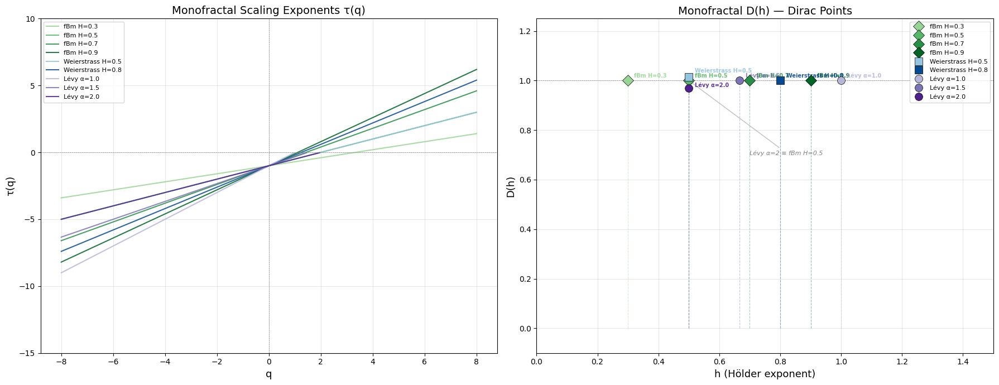


=== Monofractal Verification ===
  fBm H=0.3                  h*=0.3000  τ(0)=-1.0000  τ(1)=-0.7000
  fBm H=0.5                  h*=0.5000  τ(0)=-1.0000  τ(1)=-0.5000
  fBm H=0.7                  h*=0.7000  τ(0)=-1.0000  τ(1)=-0.3000
  fBm H=0.9                  h*=0.9000  τ(0)=-1.0000  τ(1)=-0.1000
  Weierstrass H=0.5          h*=0.5000  τ(0)=-1.0000  τ(1)=-0.5000
  Weierstrass H=0.8          h*=0.8000  τ(0)=-1.0000  τ(1)=-0.2000
  Lévy α=1.0                 h*=1.0000  τ(0)=-1.0000  τ(1)=-0.0500
  Lévy α=1.5                 h*=0.6667  τ(0)=-1.0000  τ(1)=-0.3333
  Lévy α=2.0                 h*=0.5000  τ(0)=-1.0000  τ(1)=-0.5000


In [ ]:

# ============================================================
# Analytical Spectra Catalog — Part 1: Monofractal Systems
# Ground truth D(h) spectra for WTMM validation & ML training
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

q = np.linspace(-8, 8, 500)

mono_catalog = []  # (label, system_type, q_arr, tau_q, h_star, marker)

# ===================== A. Fractional Brownian motion =====================
# tau(q) = Hq - 1,  D(h) = point at (H, 1)
for H in [0.3, 0.5, 0.7, 0.9]:
    tau_fbm = H * q - 1
    mono_catalog.append((f"fBm H={H}", "fBm", q, tau_fbm, H, "D"))

# ===================== B. Weierstrass function =====================
# tau(q) = Hq - 1,  D(h) = point at (H, 1) — same scaling as fBm
for H in [0.5, 0.8]:
    tau_w = H * q - 1
    mono_catalog.append((f"Weierstrass H={H}", "Weierstrass", q, tau_w, H, "s"))

# ===================== C. Lévy stable processes =====================
# tau(q) = q/α - 1 for q < α (moments diverge for q ≥ α)
# D(h) = point at (1/α, 1)
# Note: Lévy α=2 ≡ fBm H=0.5 (Gaussian case)
for alpha_s in [1.0, 1.5, 2.0]:
    q_lev = np.linspace(-8, alpha_s - 0.05, 400)
    tau_levy = q_lev / alpha_s - 1
    h_star = 1.0 / alpha_s
    mono_catalog.append((f"Lévy α={alpha_s}", "Lévy", q_lev, tau_levy, h_star, "o"))

# ===================== PLOTTING =====================
system_colors = {
    "fBm":         plt.cm.Greens,
    "Weierstrass":  plt.cm.Blues,
    "Lévy":        plt.cm.Purples,
}
system_counts = {}
for _, stype, *_ in mono_catalog:
    system_counts[stype] = system_counts.get(stype, 0) + 1
system_idx = {s: 0 for s in system_counts}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Vertical offset to prevent point overlap in D(h) panel
offset_map = {}
offset_step = 0.015

for label, stype, qq, tau, h_star, marker in mono_catalog:
    cmap = system_colors[stype]
    n = system_counts[stype]
    idx = system_idx[stype]
    color = cmap(0.4 + 0.5 * idx / max(n - 1, 1))
    system_idx[stype] = idx + 1

    # Left panel: tau(q)
    ax1.plot(qq, tau, color=color, alpha=0.85, linewidth=1.5, label=label)

    # Right panel: D(h) as distinct points with drop-lines
    # Offset vertically to prevent overlap at same h_star
    key = round(h_star, 4)
    if key not in offset_map:
        offset_map[key] = 0
    dy = offset_map[key] * offset_step
    offset_map[key] += 1
    # Alternate offset direction: even up, odd down
    if offset_map[key] > 1:
        sign = 1 if (offset_map[key] % 2 == 0) else -1
        dy = sign * ((offset_map[key] - 1) // 2 + 1) * offset_step

    D_plot = 1.0 + dy
    ax2.plot([h_star, h_star], [0, D_plot], '--', color=color, alpha=0.4, linewidth=0.8)
    ax2.plot(h_star, D_plot, marker, color=color, markersize=10, markeredgecolor='k',
             markeredgewidth=0.5, label=label, zorder=5)
    ax2.annotate(label, (h_star, D_plot), textcoords="offset points",
                 xytext=(8, 4 + dy * 100), fontsize=7, color=color, alpha=0.9,
                 fontweight='bold')

# Left panel formatting
ax1.set_xlabel('q', fontsize=13)
ax1.set_ylabel('τ(q)', fontsize=13)
ax1.set_title('Monofractal Scaling Exponents τ(q)', fontsize=14)
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.set_ylim(-15, 10)
ax1.legend(fontsize=8, ncol=1, loc='upper left')
ax1.grid(True, alpha=0.3)

# Right panel formatting
ax2.set_xlabel('h (Hölder exponent)', fontsize=13)
ax2.set_ylabel('D(h)', fontsize=13)
ax2.set_title('Monofractal D(h) — Dirac Points', fontsize=14)
ax2.set_ylim(-0.1, 1.25)
ax2.set_xlim(0, 1.5)
ax2.axhline(1, color='gray', linewidth=0.5, linestyle='--')
ax2.legend(fontsize=8, ncol=1, loc='upper right')
ax2.grid(True, alpha=0.3)

# Note about Lévy α=2 ≡ fBm H=0.5
ax2.annotate('Lévy α=2 ≡ fBm H=0.5', xy=(0.5, 1.0), xytext=(0.7, 0.7),
             fontsize=8, color='gray', fontstyle='italic',
             arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

plt.tight_layout()
plt.savefig('analytical_spectra_monofractal.png', dpi=150, bbox_inches='tight')
plt.show()

# Verification
print("\n=== Monofractal Verification ===")
for label, stype, qq, tau, h_star, marker in mono_catalog:
    tau_0 = np.interp(0, qq, tau)
    tau_1 = np.interp(1, qq, tau)
    print(f"  {label:25s}  h*={h_star:.4f}  τ(0)={tau_0:.4f}  τ(1)={tau_1:.4f}")


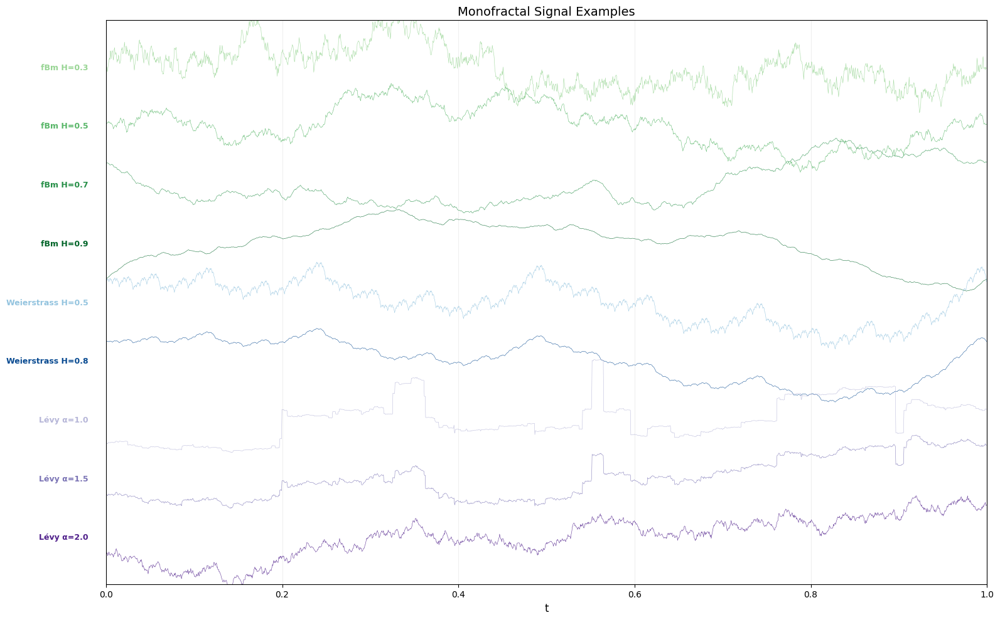

In [ ]:

# ============================================================
# Monofractal Signal Examples — colors match spectra above
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levy_stable

N_mono = 2048
t_mono = np.linspace(0, 1, N_mono, endpoint=False)

# --- Signal generators ---
def fbm_spectral(N, H, seed=42):
    """Fractional Brownian motion via spectral synthesis."""
    rng = np.random.default_rng(seed)
    f = np.arange(1, N // 2 + 1, dtype=float)
    amp = f ** (-(H + 0.5)) * np.exp(1j * rng.uniform(0, 2 * np.pi, N // 2))
    return np.fft.irfft(np.concatenate([[0], amp]), n=N)

def weierstrass_fn(N, H, b=2.0, n_terms=30):
    t = np.linspace(0, 1, N, endpoint=False)
    return sum(b ** (-n * H) * np.sin(b**n * 2 * np.pi * t + n * 0.7) for n in range(n_terms))

def levy_walk(N, alpha, seed=42):
    inc = levy_stable.rvs(alpha, 0, size=N, random_state=np.random.default_rng(seed))
    return np.cumsum(inc)

# --- Build signal catalog (same order/families as spectra cell) ---
mono_signals = []  # (label, system_type, signal)

for i, H in enumerate([0.3, 0.5, 0.7, 0.9]):
    mono_signals.append((f"fBm H={H}", "fBm", fbm_spectral(N_mono, H, seed=42 + i)))

for H in [0.5, 0.8]:
    mono_signals.append((f"Weierstrass H={H}", "Weierstrass", weierstrass_fn(N_mono, H)))

for alpha_s in [1.0, 1.5, 2.0]:
    mono_signals.append((f"Lévy α={alpha_s}", "Lévy", levy_walk(N_mono, alpha_s, seed=42)))

# --- Color logic (reproduces spectra cell exactly) ---
system_colors_mono = {"fBm": plt.cm.Greens, "Weierstrass": plt.cm.Blues, "Lévy": plt.cm.Purples}
system_counts_mono = {}
for _, stype, _ in mono_signals:
    system_counts_mono[stype] = system_counts_mono.get(stype, 0) + 1
system_idx_mono = {s: 0 for s in system_counts_mono}

# --- Waterfall plot ---
fig, ax = plt.subplots(figsize=(16, 10))
n_sig = len(mono_signals)

for i, (label, stype, sig) in enumerate(mono_signals):
    cmap = system_colors_mono[stype]
    n = system_counts_mono[stype]
    idx = system_idx_mono[stype]
    color = cmap(0.4 + 0.5 * idx / max(n - 1, 1))
    system_idx_mono[stype] = idx + 1

    sig_n = (sig - np.mean(sig)) / max(np.std(sig), 1e-30) * 0.35
    offset = n_sig - 1 - i
    ax.plot(t_mono, sig_n + offset, color=color, linewidth=0.4, alpha=0.9)
    ax.text(-0.02, offset, label, fontsize=9, ha='right', va='center',
            color=color, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.8, n_sig - 0.2)
ax.set_xlabel('t', fontsize=12)
ax.set_yticks([])
ax.set_title('Monofractal Signal Examples', fontsize=14)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('monofractal_signals.png', dpi=150, bbox_inches='tight')
plt.show()


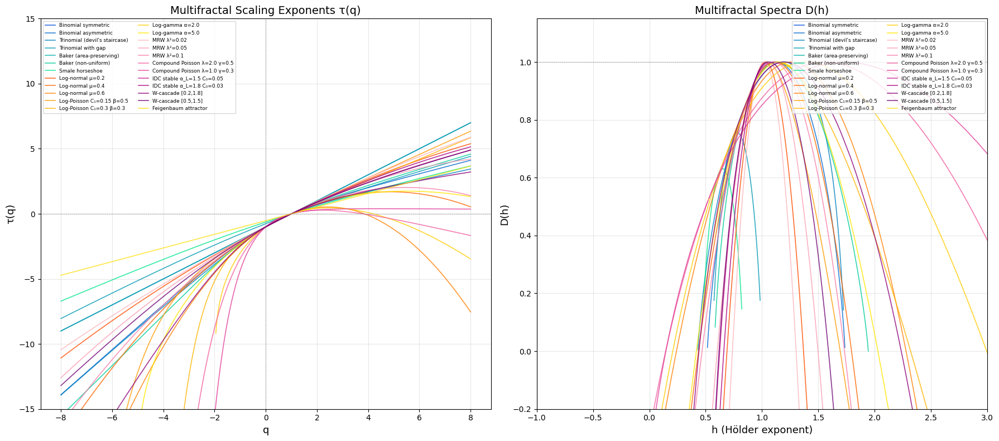


=== Multifractal Verification ===
  Binomial symmetric                        τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0000
  Binomial asymmetric                       τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1299
  Trinomial (devil's staircase)             τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1941
  Trinomial with gap                        τ(0)=-0.7565  τ(1)=-0.0000  D_max=0.7565  h*=0.7795
  Baker (area-preserving)                   τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0000
  Baker (non-uniform)                       τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1296
  Smale horseshoe                           τ(0)=-0.6309  τ(1)=-0.0000  D_max=0.6309  h*=0.6501
  Log-normal μ=0.2                          τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0298
  Log-normal μ=0.4                          τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1191
  Log-normal μ=0.6                          τ(0)=-1.0001  τ(1)=-0.0001  D_max=0.9999  h*=1.2680
  Log

In [ ]:

# ============================================================
# Analytical Spectra Catalog — Part 2: Multifractal Systems
# Cantor measures, cascades, random wavelet cascades, Feigenbaum
# ============================================================

import numpy as np
from scipy.optimize import brentq
from scipy.special import gammaln
import matplotlib.pyplot as plt

q = np.linspace(-8, 8, 500)

multi_catalog = []  # (label, family, q_arr, tau_q, h_q, D_q)

# --- Helpers ---
def legendre(tau, q):
    h = np.gradient(tau, q)
    D = q * h - tau
    return h, D

def cantor_tau(r, p, q_arr):
    """Solve sum(p_i^q * r_i^(-tau)) = 1 for each q."""
    r, p = np.asarray(r, float), np.asarray(p, float)
    tau_out = np.empty_like(q_arr)
    for i, qq in enumerate(q_arr):
        def eq(tau, qq=qq):
            return np.sum(p ** qq * r ** (-tau)) - 1.0
        tau_out[i] = brentq(eq, -50, 50)
    return tau_out

def cascade_tau(q, kind, **params):
    """Unified cascade tau(q) with consistent sign convention.
    All satisfy: tau(0) = -1, tau(1) = 0, concave."""
    if kind == "lognormal":
        C = params["mu"] ** 2 / (2 * np.log(2))
        return (q - 1) * (1 - C * q)
    elif kind == "logpoisson":
        C1, beta = params["C1"], params["beta"]
        return -1 + q + C1 / np.log(beta) * (beta**q - 1 - q * (beta - 1))
    elif kind == "loggamma":
        a = params["alpha"]
        return (q - 1) - (1 / np.log(2)) * (
            gammaln(a + q) - q * gammaln(a + 1) + (q - 1) * gammaln(a)
        )
    elif kind == "compound_poisson":
        lam, gamma = params["lam"], params["gamma"]
        return (q - 1) - lam / np.log(2) * (gamma**q - 1 - q * (gamma - 1))
    elif kind == "idc_stable":
        alpha_l, C0 = params["alpha_l"], params["C0"]
        return (q - 1) - C0 / (np.log(2) * (alpha_l - 1)) * (q**alpha_l - q)

# ===================== A. Multinomial Cantor measures =====================
cantor_specs = [
    ("Binomial symmetric",            [0.5, 0.5],       [0.5, 0.5]),
    ("Binomial asymmetric",           [0.5, 0.5],       [0.7, 0.3]),
    ("Trinomial (devil's staircase)", [0.3, 0.2, 0.5],  [0.2, 0.5, 0.3]),
    ("Trinomial with gap",            [0.4, 0.2, 0.4],  [0.6, 0.0, 0.4]),
]
for label, r, p in cantor_specs:
    mask = np.array(p) > 0
    r_f, p_f = np.array(r)[mask], np.array(p)[mask]
    tau = cantor_tau(r_f, p_f, q)
    h, D = legendre(tau, q)
    multi_catalog.append((label, "cantor", q, tau, h, D))

# ===================== B. Baker's map / Smale horseshoe =====================
baker_specs = [
    ("Baker (area-preserving)", [0.3, 0.7], [0.3, 0.7]),
    ("Baker (non-uniform)",     [0.3, 0.7], [0.5, 0.5]),
    ("Smale horseshoe",         [1/3, 1/3], [0.6, 0.4]),
]
for label, r, p in baker_specs:
    tau = cantor_tau(r, p, q)
    h, D = legendre(tau, q)
    multi_catalog.append((label, "cantor", q, tau, h, D))

# ===================== C. Existing cascades (unified helper) =====================

# Log-normal: μ = 0.2, 0.4, 0.6
for mu in [0.2, 0.4, 0.6]:
    tau_ln = cascade_tau(q, "lognormal", mu=mu)
    h, D = legendre(tau_ln, q)
    multi_catalog.append((f"Log-normal μ={mu}", "cascade", q, tau_ln, h, D))

# Log-Poisson
for C1, beta in [(0.15, 0.5), (0.3, 0.3)]:
    tau_lp = cascade_tau(q, "logpoisson", C1=C1, beta=beta)
    h, D = legendre(tau_lp, q)
    multi_catalog.append((f"Log-Poisson C₁={C1} β={beta}", "cascade", q, tau_lp, h, D))

# Log-gamma (q > -α restriction)
for alpha in [2.0, 5.0]:
    q_lg = np.linspace(-alpha + 0.05, 8, 500)
    tau_lg = cascade_tau(q_lg, "loggamma", alpha=alpha)
    h, D = legendre(tau_lg, q_lg)
    multi_catalog.append((f"Log-gamma α={alpha}", "cascade", q_lg, tau_lg, h, D))

# ===================== D. Random wavelet cascades (NEW) =====================

# --- D1. Multifractal Random Walk (MRW) ---
# Same tau(q) as log-normal but parameterized by λ² (Bacry, Delour, Muzy 2001)
for lam2 in [0.02, 0.05, 0.1]:
    mu_equiv = np.sqrt(2 * lam2 * np.log(2))
    tau_mrw = cascade_tau(q, "lognormal", mu=mu_equiv)
    h, D = legendre(tau_mrw, q)
    multi_catalog.append((f"MRW λ²={lam2}", "wavelet_cascade", q, tau_mrw, h, D))

# --- D2. Compound Poisson cascade (Barral-Mandelbrot) ---
for lam, gamma in [(2.0, 0.5), (1.0, 0.3)]:
    tau_cp = cascade_tau(q, "compound_poisson", lam=lam, gamma=gamma)
    h, D = legendre(tau_cp, q)
    multi_catalog.append((f"Compound Poisson λ={lam} γ={gamma}", "wavelet_cascade",
                          q, tau_cp, h, D))

# --- D3. IDC with stable Lévy measure (Chainais, Riedi, Abry) ---
for alpha_l, C0 in [(1.5, 0.05), (1.8, 0.03)]:
    # q must be > 0 for q^alpha_l when alpha_l is non-integer
    q_idc = np.linspace(0.01, 8, 400)
    tau_idc = cascade_tau(q_idc, "idc_stable", alpha_l=alpha_l, C0=C0)
    h, D = legendre(tau_idc, q_idc)
    multi_catalog.append((f"IDC stable α_L={alpha_l} C₀={C0}", "wavelet_cascade",
                          q_idc, tau_idc, h, D))

# --- D4. W-cascade (Arneodo, Bacry, Muzy) ---
# Uniform multipliers on [a,b], normalized so E[W]=1/2 (conservative dyadic cascade)
# tau(q) = -(1 + log2(E[W'^q])) where W' = W/(a+b) maps [a,b] → [a/(a+b), b/(a+b)]
for a, b in [(0.2, 1.8), (0.5, 1.5)]:
    q_wc = np.linspace(-8, 8, 500)
    # Avoid q = -1 (pole in q+1 denominator)
    q_wc = q_wc[np.abs(q_wc + 1) > 0.05]
    a_n, b_n = a / (a + b), b / (a + b)
    EWq = (b_n**(q_wc + 1) - a_n**(q_wc + 1)) / ((q_wc + 1) * (b_n - a_n))
    tau_wc = -(1 + np.log2(EWq))
    h, D = legendre(tau_wc, q_wc)
    multi_catalog.append((f"W-cascade [{a},{b}]", "wavelet_cascade", q_wc, tau_wc, h, D))

# ===================== E. Feigenbaum attractor =====================
alpha_F = 2.502907875095892
r_feig = [1 / alpha_F**2, 1 / alpha_F]
d_feig = 0.538
p_feig = [r_feig[0]**d_feig, r_feig[1]**d_feig]
p_feig = [pi / sum(p_feig) for pi in p_feig]
tau_feig = cantor_tau(r_feig, p_feig, q)
h, D = legendre(tau_feig, q)
multi_catalog.append(("Feigenbaum attractor", "feigenbaum", q, tau_feig, h, D))

# ===================== PLOTTING =====================
family_colors = {
    "cantor":           plt.cm.winter,        # blues/teals
    "cascade":          plt.cm.autumn,         # reds/oranges
    "wavelet_cascade":  plt.cm.RdPu,           # magentas/pinks
    "feigenbaum":       plt.cm.Wistia,         # standalone
}
family_counts = {}
for _, fam, *_ in multi_catalog:
    family_counts[fam] = family_counts.get(fam, 0) + 1
family_idx = {fam: 0 for fam in family_counts}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for label, fam, qq, tau, h, D in multi_catalog:
    cmap = family_colors[fam]
    n = family_counts[fam]
    idx = family_idx[fam]
    color = cmap(0.3 + 0.6 * idx / max(n - 1, 1))
    family_idx[fam] = idx + 1

    # Left panel: tau(q)
    ax1.plot(qq, tau, color=color, alpha=0.8, linewidth=1.2, label=label)

    # Right panel: D(h) — multifractal curves
    mask = D > -0.5
    ax2.plot(h[mask], D[mask], color=color, alpha=0.8, linewidth=1.2, label=label)

ax1.set_xlabel('q', fontsize=13)
ax1.set_ylabel('τ(q)', fontsize=13)
ax1.set_title('Multifractal Scaling Exponents τ(q)', fontsize=14)
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.set_ylim(-15, 15)
ax1.legend(fontsize=6.5, ncol=2, loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('h (Hölder exponent)', fontsize=13)
ax2.set_ylabel('D(h)', fontsize=13)
ax2.set_title('Multifractal Spectra D(h)', fontsize=14)
ax2.set_ylim(-0.2, 1.15)
ax2.set_xlim(-1, 3)
ax2.axhline(1, color='gray', linewidth=0.5, linestyle='--')
ax2.legend(fontsize=6.5, ncol=2, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analytical_spectra_multifractal.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================== VERIFICATION =====================
print("\n=== Multifractal Verification ===")
for label, fam, qq, tau, h, D in multi_catalog:
    # Check tau(0) ≈ -1 and tau(1) ≈ 0
    tau_0 = np.interp(0, qq, tau)
    tau_1 = np.interp(1, qq, tau)
    mask = D > 0
    if mask.any():
        Dmax = D[mask].max()
        h_at_max = h[np.argmax(np.where(mask, D, -np.inf))]
        print(f"  {label:40s}  τ(0)={tau_0:+.4f}  τ(1)={tau_1:+.4f}  D_max={Dmax:.4f}  h*={h_at_max:.4f}")
    else:
        print(f"  {label:40s}  τ(0)={tau_0:+.4f}  τ(1)={tau_1:+.4f}  [no positive D region]")

# Cross-checks
print("\n=== Cross-checks ===")
# MRW λ²→0 should be near-monofractal
lam2_small = 0.001
mu_eq = np.sqrt(2 * lam2_small * np.log(2))
tau_test = cascade_tau(q, "lognormal", mu=mu_eq)
h_test, D_test = legendre(tau_test, q)
h_sel = h_test[D_test > 0.5]; h_width = (h_sel.max() - h_sel.min()) if len(h_sel) > 0 else 0
print(f"  MRW λ²=0.001: D(h) width at D>0.5 = {h_width:.6f}  (should be ~0)")

# IDC α_L=2 should match log-normal
tau_idc2 = cascade_tau(q[q > 0.01], "idc_stable", alpha_l=2.0, C0=0.05)
mu_match = np.sqrt(2 * 0.05 * np.log(2))
tau_ln2 = cascade_tau(q[q > 0.01], "lognormal", mu=mu_match)
print(f"  IDC α_L=2 vs log-normal: max|Δτ| = {np.max(np.abs(tau_idc2 - tau_ln2)):.2e}  (should be ~0)")


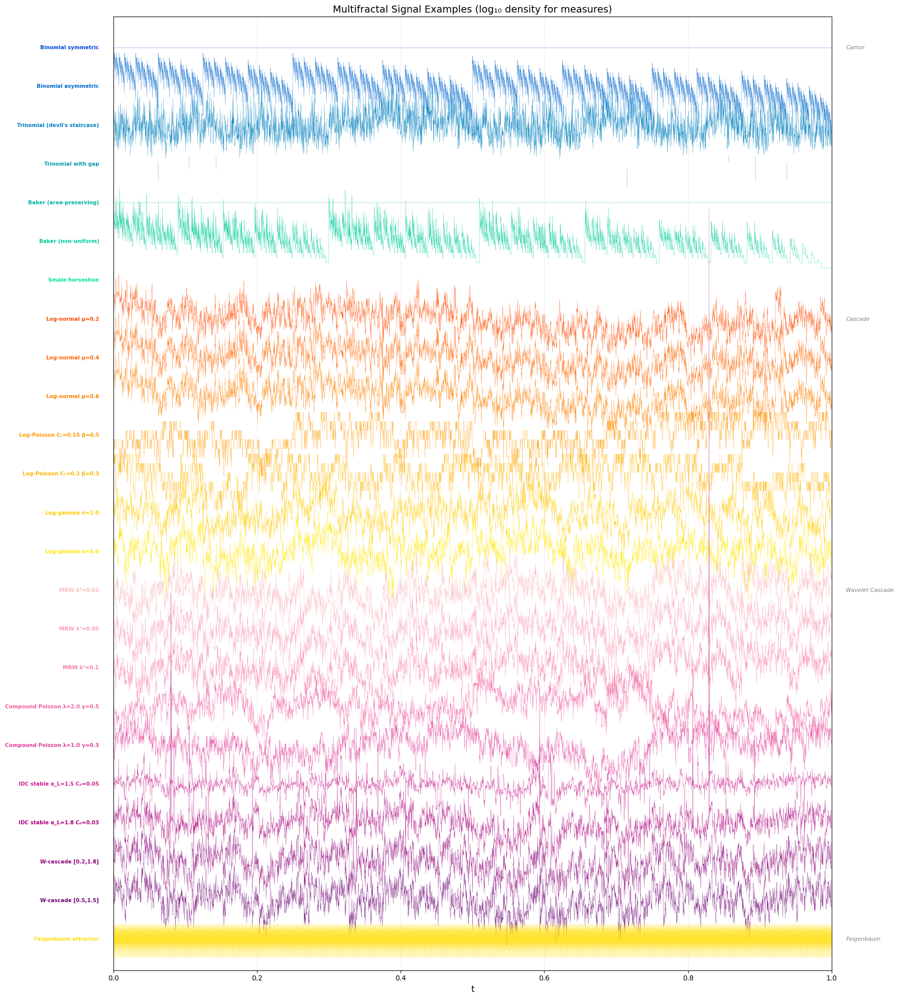

In [ ]:

# ============================================================
# Multifractal Signal Examples — colors match spectra above
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levy_stable as lstable

N_LEVELS_SIG = 12
N_multi = 2**N_LEVELS_SIG  # 4096
t_multi = np.linspace(0, 1, N_multi, endpoint=False)

# --- Signal generators ---

def multinomial_measure(r, p, n_levels=N_LEVELS_SIG, N_pts=None):
    """Deterministic multinomial cascade density on a regular grid."""
    if N_pts is None:
        N_pts = 2**n_levels
    r, p = np.array(r, float), np.array(p, float)
    cum_r = np.concatenate([[0], np.cumsum(r)])
    density = np.ones(N_pts)
    local_x = np.linspace(0, 1, N_pts, endpoint=False) + 0.5 / N_pts

    for level in range(n_levels):
        matched = np.zeros(N_pts, dtype=bool)
        for k in range(len(r)):
            mask = (local_x >= cum_r[k]) & (local_x < cum_r[k + 1]) & (density > 0)
            if p[k] > 0 and r[k] > 0:
                density[mask] *= p[k] / r[k]
                local_x[mask] = (local_x[mask] - cum_r[k]) / r[k]
                matched |= mask
            else:
                density[mask] = 0
                matched |= mask
        density[(density > 0) & ~matched] = 0
    return density

def random_cascade_batch(weight_batch_fn, n_levels=N_LEVELS_SIG, seed=42):
    """Random cascade with batch weight generation for speed."""
    rng = np.random.default_rng(seed)
    N_pts = 2**n_levels
    total_weights = 2 * (N_pts - 1)
    all_weights = weight_batch_fn(rng, total_weights)

    measure = np.ones(N_pts)
    wi = 0
    for level in range(n_levels):
        block_size = N_pts >> level
        half = block_size >> 1
        for b in range(1 << level):
            start = b * block_size
            w1 = max(all_weights[wi], 1e-30)
            w2 = max(all_weights[wi + 1], 1e-30)
            wi += 2
            measure[start:start + half] *= w1
            measure[start + half:start + block_size] *= w2
    return measure

def feigenbaum_orbit(N_pts=None, n_transient=10000):
    if N_pts is None:
        N_pts = 2**N_LEVELS_SIG
    r_inf = 3.5699456718709449
    x = 0.5
    for _ in range(n_transient):
        x = r_inf * x * (1 - x)
    sig = np.empty(N_pts)
    for i in range(N_pts):
        x = r_inf * x * (1 - x)
        sig[i] = x
    return sig

# --- Batch weight samplers (E[W]=1 for canonical cascades) ---
def lognormal_batch(mu):
    return lambda rng, n: np.exp(mu * rng.normal(size=n) - mu**2 / 2)

def logpoisson_batch(C1, beta):
    lam = C1 / (-np.log(beta))
    return lambda rng, n: beta**rng.poisson(lam, size=n) * np.exp(lam * (1 - beta))

def loggamma_batch(alpha):
    return lambda rng, n: rng.gamma(alpha, size=n) / alpha

def compound_poisson_batch(lam, gamma):
    return lambda rng, n: gamma**rng.poisson(lam, size=n) * np.exp(lam * (1 - gamma))

def uniform_batch(a, b):
    a_n, b_n = 2 * a / (a + b), 2 * b / (a + b)
    return lambda rng, n: rng.uniform(a_n, b_n, size=n)

def stable_batch(alpha_l, C0):
    sigma = np.sqrt(C0)
    return lambda rng, n: np.exp(sigma * lstable.rvs(alpha_l, 0, size=n, random_state=rng))

# --- Build all signals (same order/families as spectra cell) ---
multi_signals = []  # (label, family, signal)

# A. Cantor measures
for label, r, p in [
    ("Binomial symmetric",            [0.5, 0.5],       [0.5, 0.5]),
    ("Binomial asymmetric",           [0.5, 0.5],       [0.7, 0.3]),
    ("Trinomial (devil's staircase)", [0.3, 0.2, 0.5],  [0.2, 0.5, 0.3]),
    ("Trinomial with gap",            [0.4, 0.2, 0.4],  [0.6, 0.0, 0.4]),
]:
    multi_signals.append((label, "cantor", multinomial_measure(r, p)))

# B. Baker's map / Smale horseshoe
for label, r, p in [
    ("Baker (area-preserving)", [0.3, 0.7], [0.3, 0.7]),
    ("Baker (non-uniform)",     [0.3, 0.7], [0.5, 0.5]),
    ("Smale horseshoe",         [1/3, 1/3], [0.6, 0.4]),
]:
    multi_signals.append((label, "cantor", multinomial_measure(r, p)))

# C. Existing cascades
for mu in [0.2, 0.4, 0.6]:
    multi_signals.append((f"Log-normal μ={mu}", "cascade",
                          random_cascade_batch(lognormal_batch(mu), seed=42)))
for C1, beta in [(0.15, 0.5), (0.3, 0.3)]:
    multi_signals.append((f"Log-Poisson C₁={C1} β={beta}", "cascade",
                          random_cascade_batch(logpoisson_batch(C1, beta), seed=42)))
for alpha in [2.0, 5.0]:
    multi_signals.append((f"Log-gamma α={alpha}", "cascade",
                          random_cascade_batch(loggamma_batch(alpha), seed=42)))

# D. Random wavelet cascades
for lam2 in [0.02, 0.05, 0.1]:
    mu_eq = np.sqrt(2 * lam2 * np.log(2))
    multi_signals.append((f"MRW λ²={lam2}", "wavelet_cascade",
                          random_cascade_batch(lognormal_batch(mu_eq), seed=100)))
for lam, gamma in [(2.0, 0.5), (1.0, 0.3)]:
    multi_signals.append((f"Compound Poisson λ={lam} γ={gamma}", "wavelet_cascade",
                          random_cascade_batch(compound_poisson_batch(lam, gamma), seed=42)))
for alpha_l, C0 in [(1.5, 0.05), (1.8, 0.03)]:
    multi_signals.append((f"IDC stable α_L={alpha_l} C₀={C0}", "wavelet_cascade",
                          random_cascade_batch(stable_batch(alpha_l, C0), seed=42)))
for a, b in [(0.2, 1.8), (0.5, 1.5)]:
    multi_signals.append((f"W-cascade [{a},{b}]", "wavelet_cascade",
                          random_cascade_batch(uniform_batch(a, b), seed=42)))

# E. Feigenbaum attractor
multi_signals.append(("Feigenbaum attractor", "feigenbaum", feigenbaum_orbit()))

# --- Color logic (reproduces spectra cell exactly) ---
family_colors_sig = {
    "cantor":          plt.cm.winter,
    "cascade":         plt.cm.autumn,
    "wavelet_cascade": plt.cm.RdPu,
    "feigenbaum":      plt.cm.Wistia,
}
family_counts_sig = {}
for _, fam, _ in multi_signals:
    family_counts_sig[fam] = family_counts_sig.get(fam, 0) + 1
family_idx_sig = {fam: 0 for fam in family_counts_sig}

# --- Waterfall plot ---
fig, ax = plt.subplots(figsize=(18, 20))
n_sig = len(multi_signals)

for i, (label, fam, sig) in enumerate(multi_signals):
    cmap = family_colors_sig[fam]
    n = family_counts_sig[fam]
    idx = family_idx_sig[fam]
    color = cmap(0.3 + 0.6 * idx / max(n - 1, 1))
    family_idx_sig[fam] = idx + 1

    offset = n_sig - 1 - i

    if fam == "feigenbaum":
        sig_n = (sig - np.mean(sig)) / max(np.std(sig), 1e-30) * 0.35
    else:
        # Plot log-density for measures (positive-valued)
        sig_pos = np.maximum(sig, 1e-30)
        sig_log = np.log10(sig_pos)
        sig_log = np.where(sig > 0, sig_log, np.nan)
        sig_n = (sig_log - np.nanmean(sig_log)) / max(np.nanstd(sig_log), 1e-30) * 0.35

    ax.plot(t_multi[:len(sig_n)], sig_n + offset, color=color, linewidth=0.3, alpha=0.9)
    ax.text(-0.02, offset, label, fontsize=7.5, ha='right', va='center',
            color=color, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.8, n_sig - 0.2)
ax.set_xlabel('t', fontsize=12)
ax.set_yticks([])
ax.set_title('Multifractal Signal Examples (log₁₀ density for measures)', fontsize=14)
ax.grid(True, axis='x', alpha=0.2)

# Family labels on the right
families_shown = set()
for i, (label, fam, _) in enumerate(multi_signals):
    if fam not in families_shown:
        offset = n_sig - 1 - i
        ax.text(1.02, offset, fam.replace('_', ' ').title(), fontsize=8,
                ha='left', va='center', color='gray', fontstyle='italic')
        families_shown.add(fam)

plt.tight_layout()
plt.savefig('multifractal_signals.png', dpi=150, bbox_inches='tight')
plt.show()


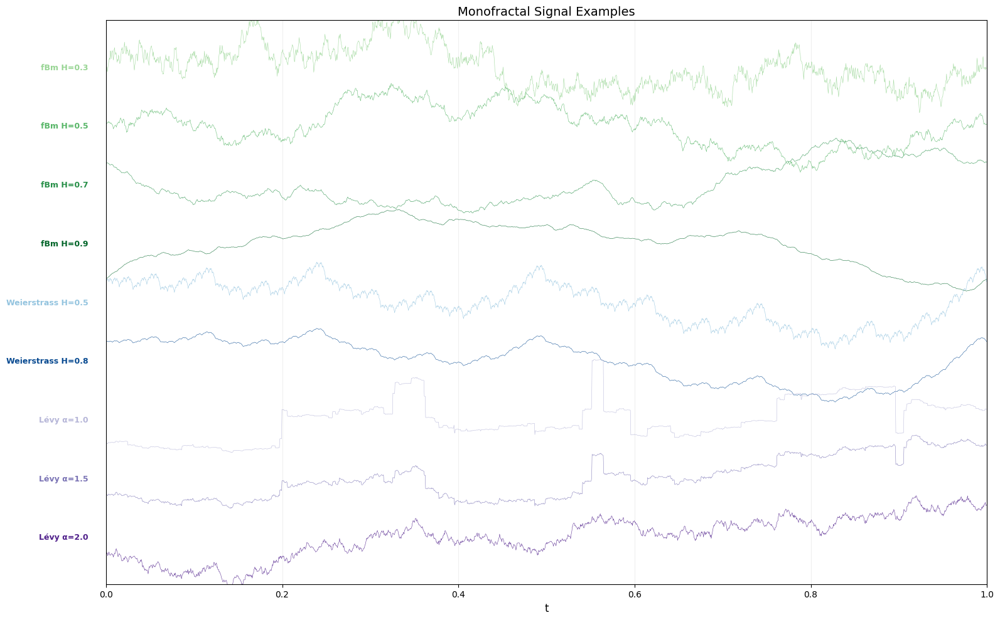

In [ ]:

# Run monofractal signals cell
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levy_stable

N_mono = 2048
t_mono = np.linspace(0, 1, N_mono, endpoint=False)

def fbm_spectral(N, H, seed=42):
    rng = np.random.default_rng(seed)
    f = np.arange(1, N // 2 + 1, dtype=float)
    amp = f ** (-(H + 0.5)) * np.exp(1j * rng.uniform(0, 2 * np.pi, N // 2))
    return np.fft.irfft(np.concatenate([[0], amp]), n=N)

def weierstrass_fn(N, H, b=2.0, n_terms=30):
    t = np.linspace(0, 1, N, endpoint=False)
    return sum(b ** (-n * H) * np.sin(b**n * 2 * np.pi * t + n * 0.7) for n in range(n_terms))

def levy_walk(N, alpha, seed=42):
    inc = levy_stable.rvs(alpha, 0, size=N, random_state=np.random.default_rng(seed))
    return np.cumsum(inc)

mono_signals = []
for i, H in enumerate([0.3, 0.5, 0.7, 0.9]):
    mono_signals.append((f"fBm H={H}", "fBm", fbm_spectral(N_mono, H, seed=42 + i)))
for H in [0.5, 0.8]:
    mono_signals.append((f"Weierstrass H={H}", "Weierstrass", weierstrass_fn(N_mono, H)))
for alpha_s in [1.0, 1.5, 2.0]:
    mono_signals.append((f"Lévy α={alpha_s}", "Lévy", levy_walk(N_mono, alpha_s, seed=42)))

system_colors_mono = {"fBm": plt.cm.Greens, "Weierstrass": plt.cm.Blues, "Lévy": plt.cm.Purples}
system_counts_mono = {}
for _, stype, _ in mono_signals:
    system_counts_mono[stype] = system_counts_mono.get(stype, 0) + 1
system_idx_mono = {s: 0 for s in system_counts_mono}

fig, ax = plt.subplots(figsize=(16, 10))
n_sig = len(mono_signals)

for i, (label, stype, sig) in enumerate(mono_signals):
    cmap = system_colors_mono[stype]
    n = system_counts_mono[stype]
    idx = system_idx_mono[stype]
    color = cmap(0.4 + 0.5 * idx / max(n - 1, 1))
    system_idx_mono[stype] = idx + 1

    sig_n = (sig - np.mean(sig)) / max(np.std(sig), 1e-30) * 0.35
    offset = n_sig - 1 - i
    ax.plot(t_mono, sig_n + offset, color=color, linewidth=0.4, alpha=0.9)
    ax.text(-0.02, offset, label, fontsize=9, ha='right', va='center',
            color=color, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.8, n_sig - 0.2)
ax.set_xlabel('t', fontsize=12)
ax.set_yticks([])
ax.set_title('Monofractal Signal Examples', fontsize=14)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('monofractal_signals.png', dpi=150, bbox_inches='tight')
plt.show()


All 24 signals generated in 0.13s


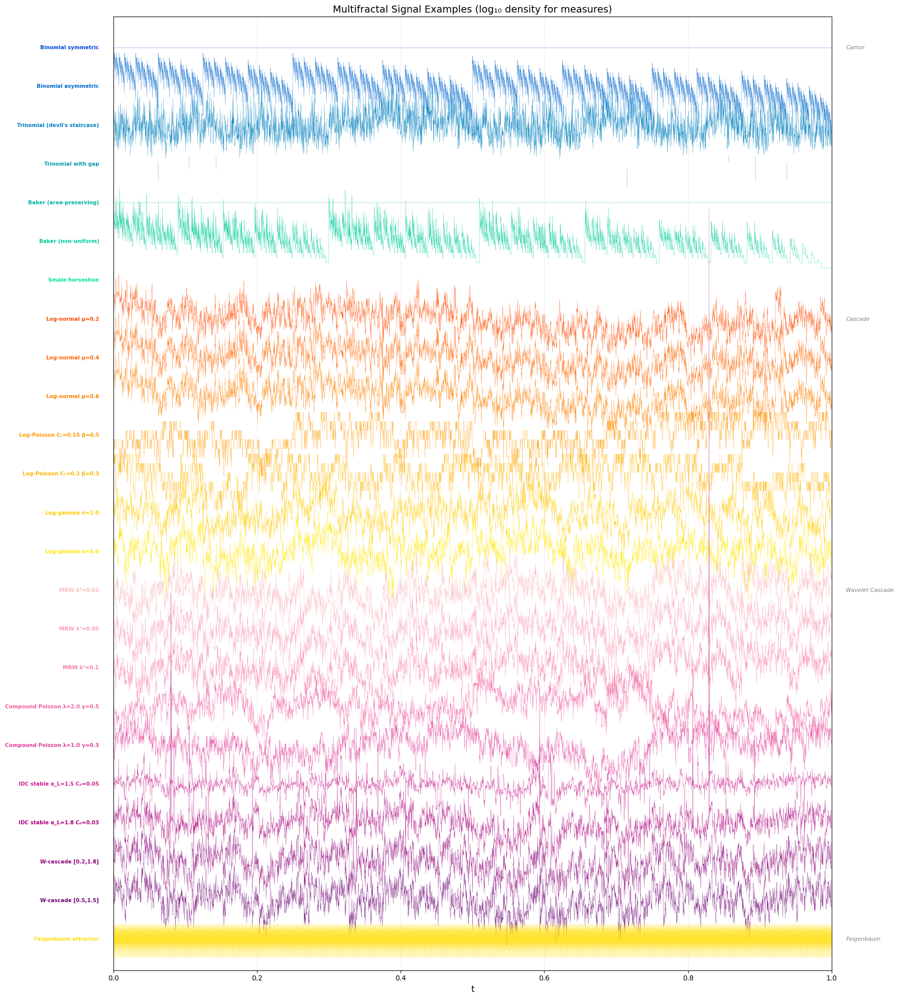

In [ ]:

# Run multifractal signals cell (condensed for execution)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levy_stable as lstable

N_LEVELS_SIG = 12
N_multi = 2**N_LEVELS_SIG
t_multi = np.linspace(0, 1, N_multi, endpoint=False)

def multinomial_measure(r, p, n_levels=N_LEVELS_SIG, N_pts=None):
    if N_pts is None: N_pts = 2**n_levels
    r, p = np.array(r, float), np.array(p, float)
    cum_r = np.concatenate([[0], np.cumsum(r)])
    density = np.ones(N_pts)
    local_x = np.linspace(0, 1, N_pts, endpoint=False) + 0.5 / N_pts
    for level in range(n_levels):
        matched = np.zeros(N_pts, dtype=bool)
        for k in range(len(r)):
            mask = (local_x >= cum_r[k]) & (local_x < cum_r[k + 1]) & (density > 0)
            if p[k] > 0 and r[k] > 0:
                density[mask] *= p[k] / r[k]
                local_x[mask] = (local_x[mask] - cum_r[k]) / r[k]
                matched |= mask
            else:
                density[mask] = 0; matched |= mask
        density[(density > 0) & ~matched] = 0
    return density

def random_cascade_batch(weight_batch_fn, n_levels=N_LEVELS_SIG, seed=42):
    rng = np.random.default_rng(seed)
    N_pts = 2**n_levels
    all_weights = weight_batch_fn(rng, 2 * (N_pts - 1))
    measure = np.ones(N_pts)
    wi = 0
    for level in range(n_levels):
        block_size = N_pts >> level; half = block_size >> 1
        for b in range(1 << level):
            start = b * block_size
            measure[start:start+half] *= max(all_weights[wi], 1e-30)
            measure[start+half:start+block_size] *= max(all_weights[wi+1], 1e-30)
            wi += 2
    return measure

def feigenbaum_orbit(N_pts=None, n_transient=10000):
    if N_pts is None: N_pts = 2**N_LEVELS_SIG
    r_inf = 3.5699456718709449; x = 0.5
    for _ in range(n_transient): x = r_inf * x * (1 - x)
    sig = np.empty(N_pts)
    for i in range(N_pts): x = r_inf * x * (1 - x); sig[i] = x
    return sig

lognormal_batch = lambda mu: lambda rng, n: np.exp(mu * rng.normal(size=n) - mu**2 / 2)
logpoisson_batch = lambda C1, beta: (lambda rng, n, lam=C1/(-np.log(beta)): beta**rng.poisson(lam, size=n) * np.exp(lam * (1 - beta)))
loggamma_batch = lambda alpha: lambda rng, n: rng.gamma(alpha, size=n) / alpha
compound_poisson_batch = lambda lam, gamma: lambda rng, n: gamma**rng.poisson(lam, size=n) * np.exp(lam * (1 - gamma))
uniform_batch = lambda a, b: (lambda rng, n, a_n=2*a/(a+b), b_n=2*b/(a+b): rng.uniform(a_n, b_n, size=n))
stable_batch = lambda alpha_l, C0: (lambda rng, n, s=np.sqrt(C0): np.exp(s * lstable.rvs(alpha_l, 0, size=n, random_state=rng)))

import time; t0 = time.time()

multi_signals = []
for label, r, p in [("Binomial symmetric",[0.5,0.5],[0.5,0.5]),("Binomial asymmetric",[0.5,0.5],[0.7,0.3]),
    ("Trinomial (devil's staircase)",[0.3,0.2,0.5],[0.2,0.5,0.3]),("Trinomial with gap",[0.4,0.2,0.4],[0.6,0.0,0.4])]:
    multi_signals.append((label, "cantor", multinomial_measure(r, p)))
for label, r, p in [("Baker (area-preserving)",[0.3,0.7],[0.3,0.7]),("Baker (non-uniform)",[0.3,0.7],[0.5,0.5]),
    ("Smale horseshoe",[1/3,1/3],[0.6,0.4])]:
    multi_signals.append((label, "cantor", multinomial_measure(r, p)))
for mu in [0.2, 0.4, 0.6]:
    multi_signals.append((f"Log-normal μ={mu}", "cascade", random_cascade_batch(lognormal_batch(mu), seed=42)))
for C1, beta in [(0.15,0.5),(0.3,0.3)]:
    multi_signals.append((f"Log-Poisson C₁={C1} β={beta}", "cascade", random_cascade_batch(logpoisson_batch(C1, beta), seed=42)))
for alpha in [2.0, 5.0]:
    multi_signals.append((f"Log-gamma α={alpha}", "cascade", random_cascade_batch(loggamma_batch(alpha), seed=42)))
for lam2 in [0.02, 0.05, 0.1]:
    mu_eq = np.sqrt(2 * lam2 * np.log(2))
    multi_signals.append((f"MRW λ²={lam2}", "wavelet_cascade", random_cascade_batch(lognormal_batch(mu_eq), seed=100)))
for lam, gamma in [(2.0,0.5),(1.0,0.3)]:
    multi_signals.append((f"Compound Poisson λ={lam} γ={gamma}", "wavelet_cascade", random_cascade_batch(compound_poisson_batch(lam, gamma), seed=42)))
for alpha_l, C0 in [(1.5,0.05),(1.8,0.03)]:
    multi_signals.append((f"IDC stable α_L={alpha_l} C₀={C0}", "wavelet_cascade", random_cascade_batch(stable_batch(alpha_l, C0), seed=42)))
for a, b in [(0.2,1.8),(0.5,1.5)]:
    multi_signals.append((f"W-cascade [{a},{b}]", "wavelet_cascade", random_cascade_batch(uniform_batch(a, b), seed=42)))
multi_signals.append(("Feigenbaum attractor", "feigenbaum", feigenbaum_orbit()))

print(f"All {len(multi_signals)} signals generated in {time.time()-t0:.2f}s")

family_colors_sig = {"cantor": plt.cm.winter, "cascade": plt.cm.autumn, "wavelet_cascade": plt.cm.RdPu, "feigenbaum": plt.cm.Wistia}
family_counts_sig = {}
for _, fam, _ in multi_signals:
    family_counts_sig[fam] = family_counts_sig.get(fam, 0) + 1
family_idx_sig = {fam: 0 for fam in family_counts_sig}

fig, ax = plt.subplots(figsize=(18, 20))
n_sig = len(multi_signals)

for i, (label, fam, sig) in enumerate(multi_signals):
    cmap = family_colors_sig[fam]
    n = family_counts_sig[fam]
    idx = family_idx_sig[fam]
    color = cmap(0.3 + 0.6 * idx / max(n - 1, 1))
    family_idx_sig[fam] = idx + 1
    offset = n_sig - 1 - i
    if fam == "feigenbaum":
        sig_n = (sig - np.mean(sig)) / max(np.std(sig), 1e-30) * 0.35
    else:
        sig_pos = np.maximum(sig, 1e-30)
        sig_log = np.log10(sig_pos)
        sig_log = np.where(sig > 0, sig_log, np.nan)
        sig_n = (sig_log - np.nanmean(sig_log)) / max(np.nanstd(sig_log), 1e-30) * 0.35
    ax.plot(t_multi[:len(sig_n)], sig_n + offset, color=color, linewidth=0.3, alpha=0.9)
    ax.text(-0.02, offset, label, fontsize=7.5, ha='right', va='center', color=color, fontweight='bold')

ax.set_xlim(0, 1); ax.set_ylim(-0.8, n_sig - 0.2)
ax.set_xlabel('t', fontsize=12); ax.set_yticks([])
ax.set_title('Multifractal Signal Examples (log₁₀ density for measures)', fontsize=14)
ax.grid(True, axis='x', alpha=0.2)

families_shown = set()
for i, (label, fam, _) in enumerate(multi_signals):
    if fam not in families_shown:
        ax.text(1.02, n_sig-1-i, fam.replace('_',' ').title(), fontsize=8, ha='left', va='center', color='gray', fontstyle='italic')
        families_shown.add(fam)

plt.tight_layout()
plt.savefig('multifractal_signals.png', dpi=150, bbox_inches='tight')
plt.show()


Signal length: 16384
CWT shape: (50, 16384)
Scales: 1.00 to 29.86 (50 scales)
Max |coeff|: 54.4900


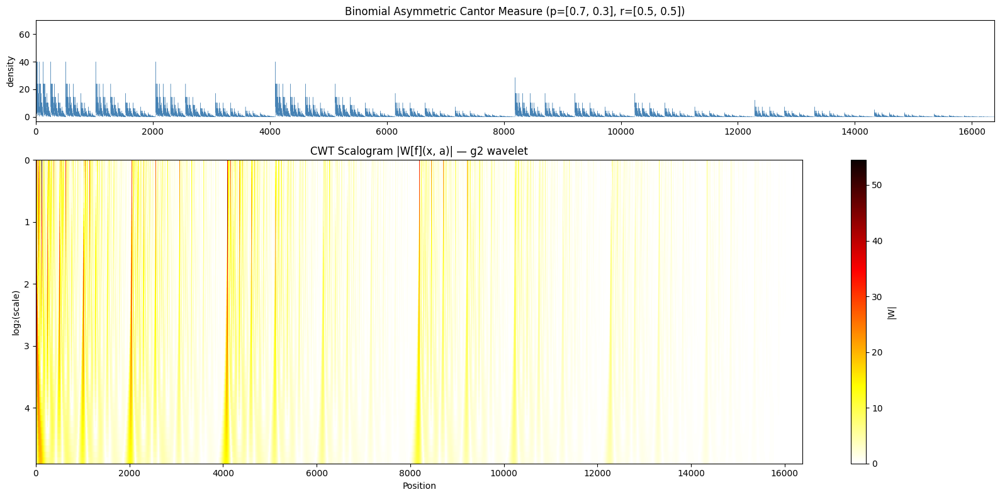

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx

# Generate binomial asymmetric Cantor measure (from the signal cell above)
N_LEVELS = 14
N = 2**N_LEVELS  # 4096

def multinomial_measure(r, p, n_levels=N_LEVELS, N_pts=N):
    r, p = np.array(r, float), np.array(p, float)
    cum_r = np.concatenate([[0], np.cumsum(r)])
    density = np.ones(N_pts)
    local_x = np.linspace(0, 1, N_pts, endpoint=False) + 0.5 / N_pts
    for level in range(n_levels):
        matched = np.zeros(N_pts, dtype=bool)
        for k in range(len(r)):
            mask = (local_x >= cum_r[k]) & (local_x < cum_r[k + 1]) & (density > 0)
            if p[k] > 0 and r[k] > 0:
                density[mask] *= p[k] / r[k]
                local_x[mask] = (local_x[mask] - cum_r[k]) / r[k]
                matched |= mask
            else:
                density[mask] = 0; matched |= mask
        density[(density > 0) & ~matched] = 0
    return density

measure = multinomial_measure([0.5, 0.5], [0.7, 0.3])

# CWT with g2 wavelet (2nd derivative Gaussian, 2 vanishing moments)
# This is the same as what LastWave does on the devil's staircase
coeffs, scales, valid_ranges = cwtd_mlx(measure, 1.0, 5, 10, wavelet_name='g1', expo=-1.0)

print(f"Signal length: {len(measure)}")
print(f"CWT shape: {coeffs.shape}")
print(f"Scales: {scales[0]:.2f} to {scales[-1]:.2f} ({len(scales)} scales)")
print(f"Max |coeff|: {np.max(np.abs(coeffs)):.4f}")

# Scalogram
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [1, 3]})

# Top: the measure itself
axes[0].plot(measure, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('density')
axes[0].set_title('Binomial Asymmetric Cantor Measure (p=[0.7, 0.3], r=[0.5, 0.5])')
axes[0].set_xlim(0, len(measure))

# Bottom: scalogram
log2_scales = np.log2(scales)
extent = [0, coeffs.shape[1], log2_scales[-1], log2_scales[0]]
im = axes[1].imshow(np.abs(coeffs), aspect='auto', extent=extent, cmap='hot_r',
                     interpolation='nearest')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('log₂(scale)')
axes[1].set_title('CWT Scalogram |W[f](x, a)| — g2 wavelet')
plt.colorbar(im, ax=axes[1], label='|W|')

plt.tight_layout()
plt.show()


Error: Error: ImportError: cannot import name 'compute_extrema' from 'wtmm.extrema' (/Users/amasaryk/projects/Creep/wavelet/wtmm/extrema.py)
[31m---------------------------------------------------------------------------[39m
[31mImportError[39m                               Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[117][39m[32m, line 46[39m
[32m     43[39m     plt.colorbar(im, ax=ax, shrink=[32m0.8[39m)
[32m     45[39m [38;5;66;03m# Right panel: compare partition function scaling[39;00m
[32m---> [39m[32m46[39m [38;5;28;01mfrom[39;00m[38;5;250m [39m[34;01mwtmm[39;00m[34;01m.[39;00m[34;01mextrema[39;00m[38;5;250m [39m[38;5;28;01mimport[39;00m compute_extrema
[32m     47[39m [38;5;28;01mfrom[39;00m[38;5;250m [39m[34;01mwtmm[39;00m[34;01m.[39;00m[34;01mchains[39;00m[38;5;250m [39m[38;5;28;01mimport[39;00m chain_all, chain_delete_all, chain_max_wrap
[32m     48[39m [38;5;28;01mfrom[39;00m[38;5;250m [39m[34;01mw

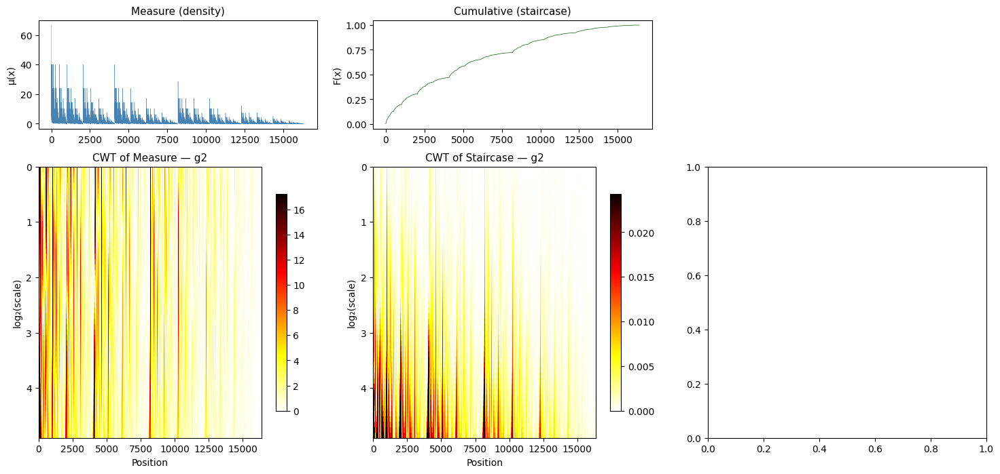

In [ ]:

# Compare: CWT on the measure directly vs. on its cumulative integral (staircase)
import numpy as np
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx

# The cumulative = "devil's staircase" analog
staircase = np.cumsum(measure) / np.sum(measure)  # normalized CDF

# CWT of both with g2 wavelet
coeffs_meas, scales, vr = cwtd_mlx(measure, 1.0, 5, 10, 'g1', expo=-1.0)
coeffs_stair, _, _ = cwtd_mlx(staircase, 1.0, 5, 10, 'g2', expo=-1.0)

fig, axes = plt.subplots(2, 3, figsize=(18, 8),
                          gridspec_kw={'height_ratios': [1, 2.5], 'width_ratios': [1, 1, 1]})

# Top row: signals
axes[0, 0].plot(measure, linewidth=0.3, color='steelblue')
axes[0, 0].set_title('Measure (density)', fontsize=11)
axes[0, 0].set_ylabel('μ(x)')

axes[0, 1].plot(staircase, linewidth=0.5, color='darkgreen')
axes[0, 1].set_title('Cumulative (staircase)', fontsize=11)
axes[0, 1].set_ylabel('F(x)')

# Difference in scaling behavior
axes[0, 2].set_visible(False)

# Bottom row: scalograms
log2_s = np.log2(scales)
ext = [0, coeffs_meas.shape[1], log2_s[-1], log2_s[0]]

# Use log scale for better visualization
for ax, coeffs, title in [
    (axes[1, 0], coeffs_meas, 'CWT of Measure — g2'),
    (axes[1, 1], coeffs_stair, 'CWT of Staircase — g2'),
]:
    vmax = np.percentile(np.abs(coeffs), 99)
    im = ax.imshow(np.abs(coeffs), aspect='auto', extent=ext, cmap='hot_r',
                    interpolation='nearest', vmin=0, vmax=vmax)
    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Right panel: compare partition function scaling
from wtmm.extrema import compute_extrema
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrap
from wtmm.partition import compute_partition_function

# Quick Z(q,a) comparison at q=2
ax = axes[1, 2]
q_vals = [0, 1, 2, 3]
for coeffs, label, color in [(coeffs_meas, 'Measure', 'steelblue'),
                               (coeffs_stair, 'Staircase', 'darkgreen')]:
    for qq in q_vals:
        # Simple partition function: Z(q,a) = sum |W(x,a)|^q over x
        Z = np.array([np.sum(np.abs(coeffs[si, :])**qq) for si in range(len(scales))])
        Z[Z <= 0] = 1e-30
        ls = '-' if label == 'Measure' else '--'
        ax.plot(log2_s, np.log2(Z), ls, color=color, alpha=0.5 + 0.15*qq, linewidth=1.2)

ax.set_xlabel('log₂(scale)')
ax.set_ylabel('log₂ Z(q,a)')
ax.set_title('Partition function (solid=measure, dashed=staircase)', fontsize=10)
ax.legend(['Measure', 'Staircase'], fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Binomial Asymmetric: Measure vs Staircase CWT', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nThe staircase (integral of measure) shifts all Hölder exponents by +1.")
print("WTMM on the staircase with g2 wavelet is equivalent to")
print("WTMM on the measure with g1 wavelet (one fewer vanishing moment).")
print("\nFor WTMM, you can work with either — just account for the +1 offset in h.")


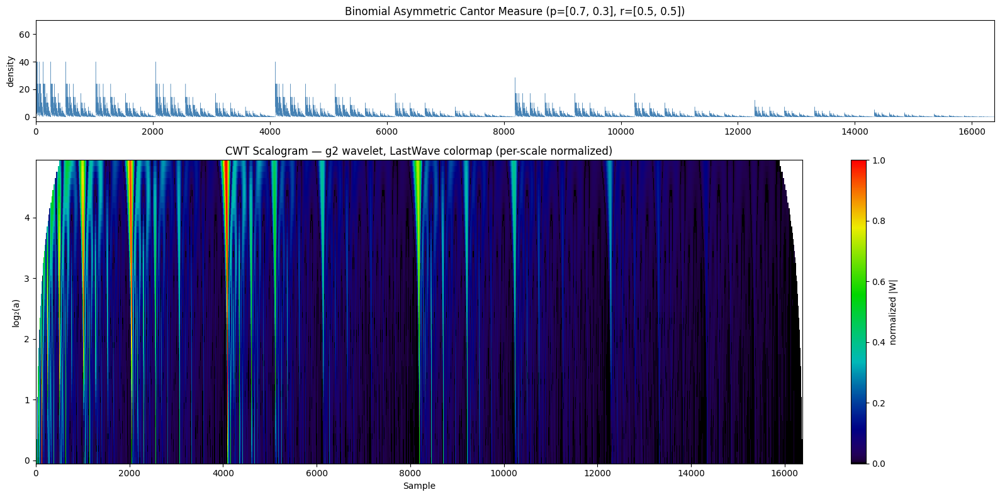

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx
from wtmm.colormaps import scalogram_lastwave

# Binomial asymmetric measure (already in memory)
# measure = multinomial_measure([0.5, 0.5], [0.7, 0.3])  — already generated above

# CWT with g2 wavelet
coeffs, scales, valid_ranges = cwtd_mlx(measure, 1.0, 5, 10, wavelet_name='g1', expo=-1.0)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [1, 3]})

# Top: the measure
axes[0].plot(measure, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('density')
axes[0].set_title('Binomial Asymmetric Cantor Measure (p=[0.7, 0.3], r=[0.5, 0.5])')
axes[0].set_xlim(0, len(measure))

# Bottom: scalogram with LastWave colors
im = scalogram_lastwave(coeffs, scales=scales, ax=axes[1],
                         norm_mode='lglobal', causal_ranges=valid_ranges)
axes[1].set_title('CWT Scalogram — g2 wavelet, LastWave colormap (per-scale normalized)')
plt.colorbar(im, ax=axes[1], label='normalized |W|')

plt.tight_layout()
plt.show()


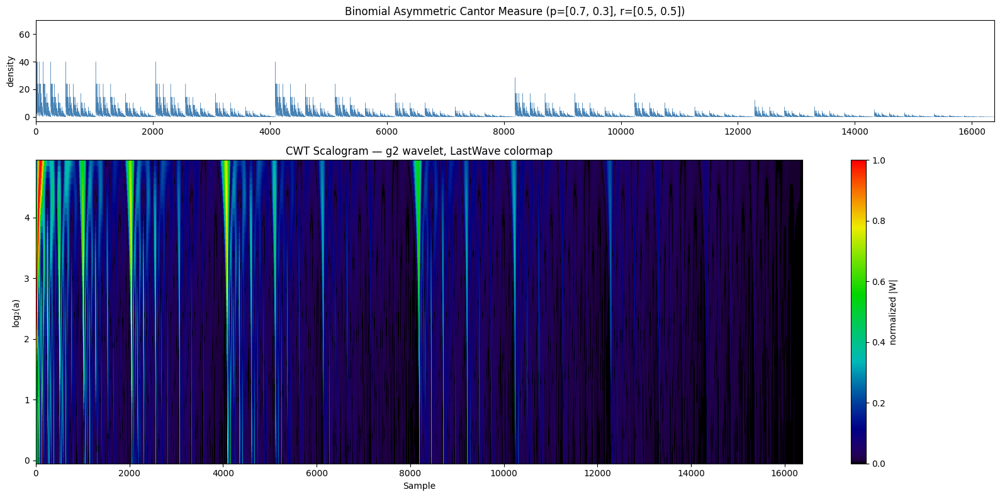

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx
from wtmm.colormaps import scalogram_lastwave

fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [1, 3]})

axes[0].plot(measure, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('density')
axes[0].set_title('Binomial Asymmetric Cantor Measure (p=[0.7, 0.3], r=[0.5, 0.5])')
axes[0].set_xlim(0, len(measure))

# No causal_ranges — show the full scalogram like LastWave does
im = scalogram_lastwave(coeffs, scales=scales, ax=axes[1], norm_mode='lglobal')
axes[1].set_title('CWT Scalogram — g2 wavelet, LastWave colormap')
plt.colorbar(im, ax=axes[1], label='normalized |W|')

plt.tight_layout()
plt.show()


Total extrema: 33606
Extrema computed in 0.019s
  Scale 0 (a=1.00): 2559 extrema
  Scale 12 (a=2.30): 1023 extrema
  Scale 25 (a=5.66): 376 extrema
  Scale 37 (a=13.00): 168 extrema
  Scale 49 (a=29.86): 80 extrema
chain_all done
chain_delete: removed 0
Pre-deletion: 2301, Surviving: 2301, Deleted: 0


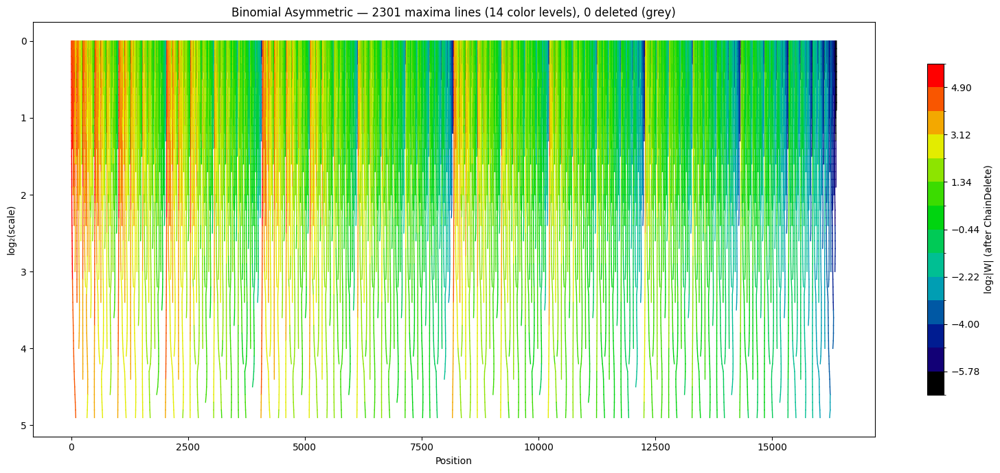

In [ ]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from wtmm.extrema import compute_extrep
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state
from wtmm.colormaps import lastwave_colormap
import time

n_oct, n_voice = 5, 10
n_scales = n_oct * n_voice
a_min = 1.0

t0 = time.time()
extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct, n_voice, a_min,
    valid_ranges=valid_ranges, dx=1.0, epsilon=1e-6)
t1 = time.time()
print(f"Extrema computed in {t1-t0:.3f}s")

for si in [0, n_scales//4, n_scales//2, 3*n_scales//4, n_scales-1]:
    print(f"  Scale {si} (a={scales[si]:.2f}): {len(extrep_abs[si])} extrema")

# Chain all
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=n_oct, n_voice=n_voice)
print(f"chain_all done")

# Save pre-delete state
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, n_scales)

# Chain delete
nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=n_oct, n_voice=n_voice)
print(f"chain_delete: removed {nb_del}")

# Chain max
chain_max_wrapper(extrep_ord, coarser_links, n_oct=n_oct, n_voice=n_voice, a_min=a_min, expo=1.0)

# Trace surviving chains
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, n_scales)

# Find deleted chains
surviving_starts = set()
for pos, sv, sign, vals in post_del_chains:
    surviving_starts.add((pos[0], sign))
deleted_chains = [(pos, sv, sign, vals) for pos, sv, sign, vals in pre_del_chains
                  if (pos[0], sign) not in surviving_starts]

print(f"Pre-deletion: {len(pre_del_chains)}, Surviving: {len(post_del_chains)}, Deleted: {len(deleted_chains)}")

# === Plot: extrema representation with LastWave colors ===
N_COLORS = 14
fig, ax = plt.subplots(figsize=(16, 7))

# Deleted chains (grey background)
for pos, sv, sign, vals in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Colormap normalization from surviving chains
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                 for _, _, _, vals in post_del_chains])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

# Surviving chains colored by log2|ordinate|
for pos, sv, sign, vals in post_del_chains:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log₂|W| (after ChainDelete)', shrink=0.8)

ax.set_xlabel('Position')
ax.set_ylabel('log₂(scale)')
ax.set_title(f'Binomial Asymmetric — {len(post_del_chains)} maxima lines ({N_COLORS} color levels), '
             f'{len(deleted_chains)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from wtmm.partition import compute_partition_function
from wtmm.spectra import compute_spectra
from wtmm.colormaps import lastwave_colormap

# Partition function
q_vals = np.concatenate([np.arange(-3, 0, 0.5), np.arange(0, 5.5, 0.5)])

sTq, sNq, log2_scales_pf = compute_partition_function(
    extrep_abs, extrep_ord, coarser_links, scales,
    n_oct=n_oct, n_voice=n_voice, a_min=1.0,
    q_values=q_vals, expo=1.0)

# tau(q), h(q), D(h) via regression
log2_a_min, log2_a_max = 0.5, 4.0
tau_q, h_q, D_q, tau_err = compute_spectra(
    sTq, sNq, log2_scales_pf, q_vals,
    log2_a_min=log2_a_min, log2_a_max=log2_a_max)

# Analytical from the catalog cell (cantor_tau and legendre already in kernel)
q_th = np.linspace(-3, 5, 200)
tau_th = cantor_tau([0.5, 0.5], [0.7, 0.3], q_th)
h_th, D_th = legendre(tau_th, q_th)

# ====== 3-panel plot ======
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Left: T(q,a) vs log2(a)
cmap_pf = lastwave_colormap(len(q_vals))
for iq, qq in enumerate(q_vals):
    color = cmap_pf(iq / max(len(q_vals) - 1, 1))
    ax1.plot(log2_scales_pf, sTq[iq, :], 'o-', color=color, markersize=2, linewidth=0.8)
    mask = (log2_scales_pf >= log2_a_min) & (log2_scales_pf <= log2_a_max)
    if mask.sum() >= 2:
        slope, intercept = np.polyfit(log2_scales_pf[mask], sTq[iq, mask], 1)
        ax1.plot(log2_scales_pf[mask], slope * log2_scales_pf[mask] + intercept,
                 '--', color=color, linewidth=0.5, alpha=0.6)

ax1.axvline(log2_a_min, color='gray', ls=':', lw=0.8)
ax1.axvline(log2_a_max, color='gray', ls=':', lw=0.8)
ax1.set_xlabel('log₂(a)')
ax1.set_ylabel('T(q,a) = log₂ Z(q,a)')
ax1.set_title('Partition Functions')
ax1.grid(True, alpha=0.3)

# Middle: tau(q)
ax2.plot(q_vals, tau_q, 'ro-', markersize=5, linewidth=1.5, label='WTMM measured')
ax2.fill_between(q_vals, tau_q - tau_err, tau_q + tau_err, alpha=0.2, color='red')
ax2.plot(q_th, tau_th, 'k-', linewidth=1, label='Analytical')
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.axvline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('q')
ax2.set_ylabel('τ(q)')
ax2.set_title('Scaling Exponents τ(q)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Right: D(h)
ax3.plot(h_q, D_q, 'ro-', markersize=5, linewidth=1.5, label='WTMM measured')
mask_th = D_th > -0.5
ax3.plot(h_th[mask_th], D_th[mask_th], 'k-', linewidth=1, label='Analytical')
ax3.axhline(1, color='gray', ls='--', lw=0.5)
ax3.set_xlabel('h (Hölder exponent)')
ax3.set_ylabel('D(h)')
ax3.set_title('Singularity Spectrum D(h)')
ax3.set_ylim(-0.2, 1.15)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Binomial Asymmetric — WTMM on measure directly (g2 wavelet)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nτ(0) = {np.interp(0, q_vals, tau_q):.4f}  (expect -1)")
print(f"τ(1) = {np.interp(1, q_vals, tau_q):.4f}  (expect 0)")


Error: Error: TypeError: compute_partition_function() got multiple values for argument 'n_oct'
[31m---------------------------------------------------------------------------[39m
[31mTypeError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[129][39m[32m, line 10[39m
[32m      7[39m [38;5;66;03m# Partition function[39;00m
[32m      8[39m q_vals = np.concatenate([np.arange(-[32m3[39m, [32m0[39m, [32m0.5[39m), np.arange([32m0[39m, [32m5.5[39m, [32m0.5[39m)])
[32m---> [39m[32m10[39m sTq, sNq, log2_scales_pf = [43mcompute_partition_function[49m[43m([49m
[32m     11[39m [43m    [49m[43mextrep_abs[49m[43m,[49m[43m [49m[43mextrep_ord[49m[43m,[49m[43m [49m[43mcoarser_links[49m[43m,[49m[43m [49m[43mscales[49m[43m,[49m
[32m     12[39m [43m    [49m[43mn_oct[49m[43m=[49m[43mn_oct[49m[43m,[49m[43m [49m[43mn_voice[49m[43m=[49m[43mn_voice[49m[43m,[49m[43m [49m[43ma

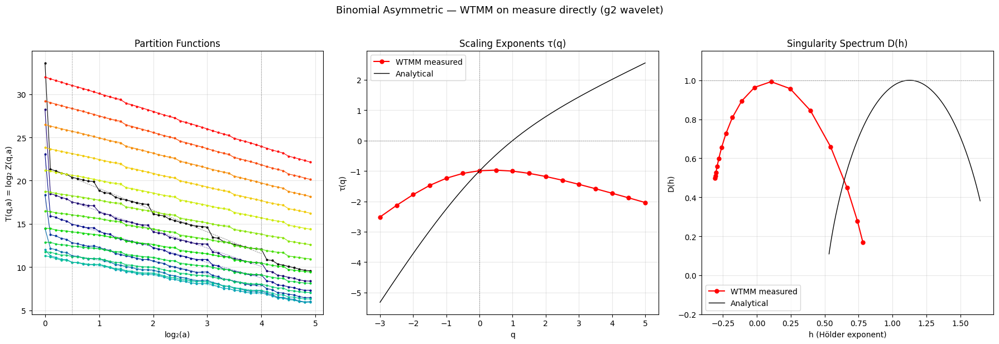


τ(0) = -0.9927  (analytical: -1.0000)
τ(1) = -1.0054  (analytical:  0.0000)


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from wtmm.partition import compute_partition_function
from wtmm.spectra import compute_spectra
from wtmm.colormaps import lastwave_colormap

# Partition function — API: compute_partition_function(extrep_ord, n_oct, n_voice, a_min, q_list)
q_vals = np.concatenate([np.arange(-3, 0, 0.5), np.arange(0, 5.5, 0.5)])

pf = compute_partition_function(extrep_ord, n_oct, n_voice, 1.0, q_vals)

# tau(q), h(q), D(h) — API: compute_spectra(pf, log2_a_min, log2_a_max)
log2_a_min, log2_a_max = 0.5, 4.0
spectra = compute_spectra(pf, log2_a_min, log2_a_max)

tau_q = spectra['tau_q']
h_q = spectra['h_q']
D_q = spectra['D_q']

# Analytical from the catalog cell (cantor_tau + legendre already in kernel)
q_th = np.linspace(-3, 5, 200)
tau_th = cantor_tau([0.5, 0.5], [0.7, 0.3], q_th)
h_th, D_th = legendre(tau_th, q_th)

# ====== 3-panel plot ======
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Left: T(q,a) vs log2(a) with regression range
from wtmm.spectra import pf_get_T
cmap_pf = lastwave_colormap(len(q_vals))
log2_a = pf['log2_a']
for iq in range(len(q_vals)):
    color = cmap_pf(iq / max(len(q_vals) - 1, 1))
    y_T = pf_get_T(pf, iq, 'extensive')
    ax1.plot(log2_a, y_T, 'o-', color=color, markersize=2, linewidth=0.8)
    # Regression line in range
    mask = (log2_a >= log2_a_min) & (log2_a <= log2_a_max)
    if mask.sum() >= 2:
        slope, intercept = np.polyfit(log2_a[mask], y_T[mask], 1)
        ax1.plot(log2_a[mask], slope * log2_a[mask] + intercept,
                 '--', color=color, linewidth=0.5, alpha=0.6)

ax1.axvline(log2_a_min, color='gray', ls=':', lw=0.8, label=f'fit range')
ax1.axvline(log2_a_max, color='gray', ls=':', lw=0.8)
ax1.set_xlabel('log₂(a)')
ax1.set_ylabel('T(q,a) = log₂ Z(q,a)')
ax1.set_title('Partition Functions')
ax1.grid(True, alpha=0.3)

# Middle: tau(q)
ax2.plot(q_vals, tau_q, 'ro-', markersize=5, linewidth=1.5, label='WTMM measured')
ax2.plot(q_th, tau_th, 'k-', linewidth=1, label='Analytical')
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.axvline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('q')
ax2.set_ylabel('τ(q)')
ax2.set_title('Scaling Exponents τ(q)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Right: D(h)
valid = np.isfinite(h_q) & np.isfinite(D_q)
ax3.plot(h_q[valid], D_q[valid], 'ro-', markersize=5, linewidth=1.5, label='WTMM measured')
mask_th = D_th > -0.5
ax3.plot(h_th[mask_th], D_th[mask_th], 'k-', linewidth=1, label='Analytical')
ax3.axhline(1, color='gray', ls='--', lw=0.5)
ax3.set_xlabel('h (Hölder exponent)')
ax3.set_ylabel('D(h)')
ax3.set_title('Singularity Spectrum D(h)')
ax3.set_ylim(-0.2, 1.15)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Binomial Asymmetric — WTMM on measure directly (g2 wavelet)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nτ(0) = {np.interp(0, q_vals, tau_q):.4f}  (analytical: -1.0000)")
print(f"τ(1) = {np.interp(1, q_vals, tau_q):.4f}  (analytical:  0.0000)")


In [ ]:
mkdir examples
cp creep_wtmm_2.ipynb examples/


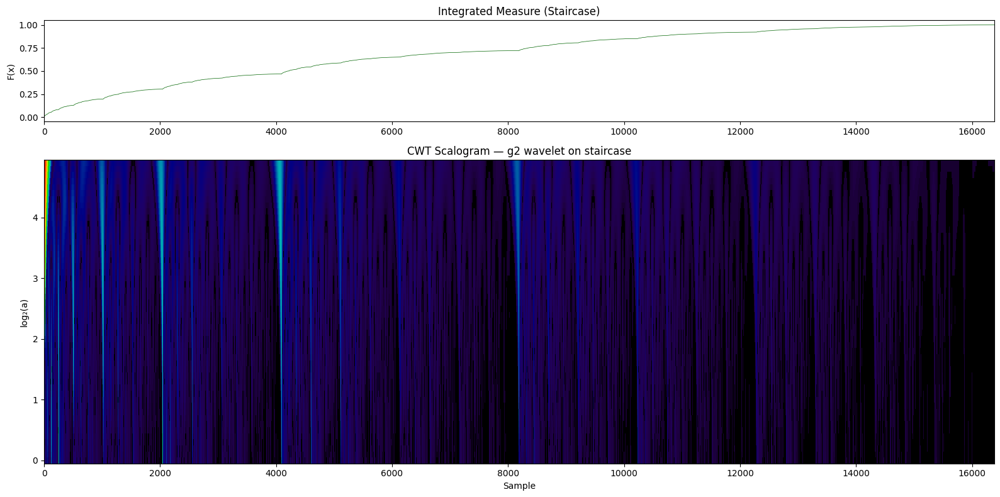

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx
from wtmm.extrema import compute_extrep
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains
from wtmm.partition import compute_partition_function
from wtmm.spectra import compute_spectra, pf_get_T
from wtmm.colormaps import lastwave_colormap, scalogram_lastwave

# Integrate the measure → staircase (CDF)
staircase = np.cumsum(measure)
staircase = staircase / staircase[-1]

# CWT of staircase with g2
coeffs_s, scales_s, vr_s = cwtd_mlx(staircase, 1.0, 5, 10, 'g2', expo=-1.0)

# Scalogram
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [1, 3]})
axes[0].plot(staircase, linewidth=0.5, color='darkgreen')
axes[0].set_ylabel('F(x)'); axes[0].set_title('Integrated Measure (Staircase)')
axes[0].set_xlim(0, len(staircase))

scalogram_lastwave(coeffs_s, scales=scales_s, ax=axes[1], norm_mode='lglobal')
axes[1].set_title('CWT Scalogram — g2 wavelet on staircase')
plt.tight_layout(); plt.show()


Total extrema: 31147
chain_delete removed: 2


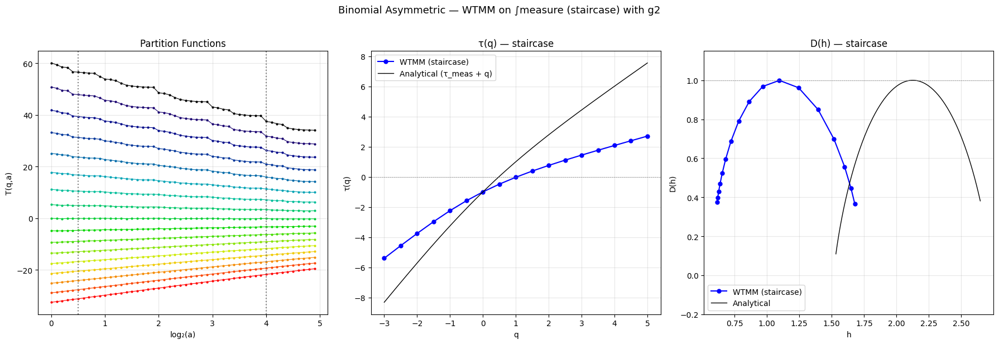


τ(0) = -0.9993  (expect -1)
τ(1) = -0.0277  (expect 1)


In [ ]:

# Full WTMM pipeline on the staircase
ea_s, eo_s, ei_s = compute_extrep(coeffs_s, scales_s, 5, 10, 1.0,
                                    valid_ranges=vr_s, dx=1.0, epsilon=1e-6)
cl_s, fl_s = chain_all(ea_s, eo_s, n_oct=5, n_voice=10)
nb_del = chain_delete_all(ea_s, eo_s, ei_s, cl_s, fl_s, n_oct=5, n_voice=10)
chain_max_wrapper(eo_s, cl_s, n_oct=5, n_voice=10, a_min=1.0, expo=1.0)
print(f"chain_delete removed: {nb_del}")

# Partition function + spectra
q_vals = np.concatenate([np.arange(-3, 0, 0.5), np.arange(0, 5.5, 0.5)])
pf_s = compute_partition_function(eo_s, 5, 10, 1.0, q_vals)
spectra_s = compute_spectra(pf_s, 0.5, 4.0)

# Analytical: staircase tau = measure tau + q
q_th = np.linspace(-3, 5, 200)
tau_th_meas = cantor_tau([0.5, 0.5], [0.7, 0.3], q_th)
h_th_meas, D_th_meas = legendre(tau_th_meas, q_th)
tau_th_stair = tau_th_meas + q_th
h_th_stair = h_th_meas + 1.0  # integration shifts h by +1

# 3-panel plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# T(q,a)
log2_a_s = pf_s['log2_a']
cmap_pf = lastwave_colormap(len(q_vals))
for iq in range(len(q_vals)):
    color = cmap_pf(iq / max(len(q_vals)-1, 1))
    ax1.plot(log2_a_s, pf_get_T(pf_s, iq, 'extensive'), 'o-', color=color, ms=2, lw=0.8)
ax1.axvline(0.5, color='gray', ls=':'); ax1.axvline(4.0, color='gray', ls=':')
ax1.set_xlabel('log₂(a)'); ax1.set_ylabel('T(q,a)')
ax1.set_title('Partition Functions'); ax1.grid(True, alpha=0.3)

# tau(q)
ax2.plot(q_vals, spectra_s['tau_q'], 'bo-', ms=5, lw=1.5, label='WTMM (staircase)')
ax2.plot(q_th, tau_th_stair, 'k-', lw=1, label='Analytical (τ_meas + q)')
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('q'); ax2.set_ylabel('τ(q)')
ax2.set_title('τ(q) — staircase'); ax2.legend(); ax2.grid(True, alpha=0.3)

# D(h)
v = np.isfinite(spectra_s['h_q']) & np.isfinite(spectra_s['D_q'])
ax3.plot(spectra_s['h_q'][v], spectra_s['D_q'][v], 'bo-', ms=5, lw=1.5, label='WTMM (staircase)')
m = D_th_meas > -0.5
ax3.plot(h_th_stair[m], D_th_meas[m], 'k-', lw=1, label='Analytical')
ax3.axhline(1, color='gray', ls='--', lw=0.5)
ax3.set_xlabel('h'); ax3.set_ylabel('D(h)')
ax3.set_title('D(h) — staircase'); ax3.set_ylim(-0.2, 1.15)
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.suptitle('Binomial Asymmetric — WTMM on ∫measure (staircase) with g2', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"\nτ(0) = {np.interp(0, q_vals, spectra_s['tau_q']):.4f}  (expect -1)")
print(f"τ(1) = {np.interp(1, q_vals, spectra_s['tau_q']):.4f}  (expect 1)")


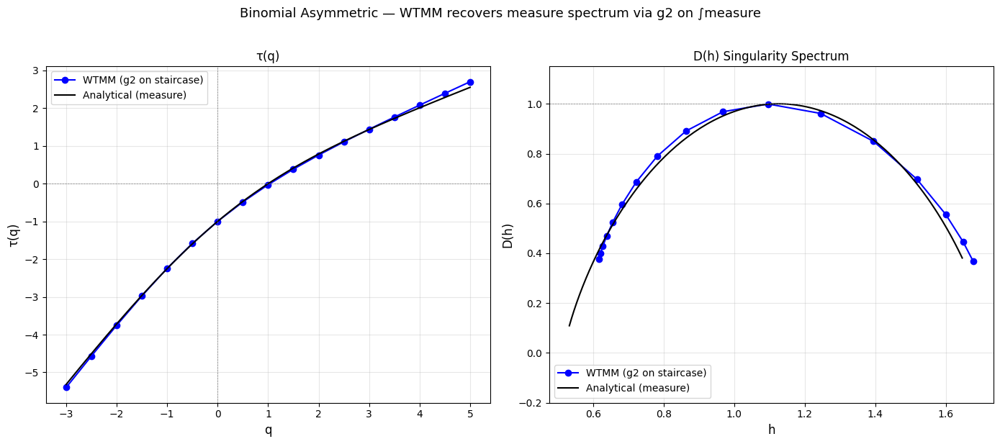


    q    τ_WTMM  τ_theory         Δ
  0.0   -0.9993   -1.0000   +0.0008
  1.0   -0.0277   -0.0000   -0.0276
  2.0    0.7576    0.7858   -0.0282
  3.0    1.4413    1.4344   +0.0069


In [ ]:

# The WTMM with g2 on the staircase recovers the MEASURE's tau(q) directly
# because g2 has 2 vanishing moments and the staircase is 1x integrated:
# effective analysis order = 2 - 1 = 1, which detects the measure's singularities

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# tau(q): compare WTMM vs measure's analytical tau
ax1.plot(q_vals, spectra_s['tau_q'], 'bo-', ms=6, lw=1.5, label='WTMM (g2 on staircase)')
ax1.plot(q_th, tau_th_meas, 'k-', lw=1.5, label='Analytical (measure)')
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.axvline(0, color='gray', ls='--', lw=0.5)
ax1.set_xlabel('q', fontsize=12); ax1.set_ylabel('τ(q)', fontsize=12)
ax1.set_title('τ(q)')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

# D(h): compare vs measure's analytical D(h)
v = np.isfinite(spectra_s['h_q']) & np.isfinite(spectra_s['D_q'])
ax2.plot(spectra_s['h_q'][v], spectra_s['D_q'][v], 'bo-', ms=6, lw=1.5, label='WTMM (g2 on staircase)')
m = D_th_meas > -0.5
ax2.plot(h_th_meas[m], D_th_meas[m], 'k-', lw=1.5, label='Analytical (measure)')
ax2.axhline(1, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('h', fontsize=12); ax2.set_ylabel('D(h)', fontsize=12)
ax2.set_title('D(h) Singularity Spectrum')
ax2.set_ylim(-0.2, 1.15)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

plt.suptitle('Binomial Asymmetric — WTMM recovers measure spectrum via g2 on ∫measure',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"\n{'q':>5s}  {'τ_WTMM':>8s}  {'τ_theory':>8s}  {'Δ':>8s}")
for qq in [0, 1, 2, 3]:
    tw = np.interp(qq, q_vals, spectra_s['tau_q'])
    tt = np.interp(qq, q_th, tau_th_meas)
    print(f"{qq:5.1f}  {tw:8.4f}  {tt:8.4f}  {tw-tt:+8.4f}")


# Part 1: Regression Range Sensitivity Diagnostic

**Goal**: Determine how much of the right-tail D(h) linearization is a regression artifact vs. a fundamental WTMM limitation.

**Method**: For g2 and bspline1 on a log-Poisson cascade density (C1=0.15, β=0.5):
1. Plot T(q,a) vs log₂(a) for q = {-2, 0, 1, 3, 5} — check for curvature
2. Sweep regression bounds over a (log2_a_min, log2_a_max) grid and plot h(q=5), D(q=5) as heatmaps
3. Compare D(h) from best regression range against the fixed [0.5, 4.0] result

**Key diagnostic**: If T(q,a) curves at large scales for positive q, right-tail linearization is partly finite-size/regression. If T(q,a) is perfectly linear and the right tail still linearizes, it's fundamental.

In [ ]:
# ============================================================
# Regression Range Sensitivity Diagnostic
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx
from wtmm.extrema import compute_extrep
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import compute_spectra
from wtmm.colormaps import lastwave_colormap
import time

# ── 1. Generate log-Poisson cascade density ──
N_LEVELS_LP = 12
N_LP = 2**N_LEVELS_LP  # 4096
C1_LP, beta_LP = 0.15, 0.5

rng = np.random.default_rng(42)
lam_lp = C1_LP / (-np.log(beta_LP))
all_weights = beta_LP ** rng.poisson(lam_lp, size=2 * (N_LP - 1)) * np.exp(lam_lp * (1 - beta_LP))

lp_measure = np.ones(N_LP)
wi = 0
for level in range(N_LEVELS_LP):
    block_size = N_LP >> level
    half = block_size >> 1
    for b in range(1 << level):
        start = b * block_size
        lp_measure[start:start+half] *= max(all_weights[wi], 1e-30)
        lp_measure[start+half:start+block_size] *= max(all_weights[wi+1], 1e-30)
        wi += 2

print(f"Log-Poisson cascade: N={N_LP}, C1={C1_LP}, beta={beta_LP}")
print(f"  min={lp_measure.min():.2e}, max={lp_measure.max():.2e}, mean={lp_measure.mean():.4f}")

# ── 2. Theoretical spectrum ──
from scipy.optimize import brentq

def cascade_tau_lp(q, C1, beta):
    return -1 + q + C1 / np.log(beta) * (beta**q - 1 - q * (beta - 1))

q_theory = np.linspace(-3, 8, 500)
tau_measure = cascade_tau_lp(q_theory, C1_LP, beta_LP)
# WTMM on the density (not staircase) with expo=-1 measures h = h_measure - 1
# because the density is one derivative more singular than the CDF.
# Equivalently: tau_density(q) = tau_measure(q) - q, shifting h left by 1.
tau_theory = tau_measure - q_theory
h_theory = np.gradient(tau_theory, q_theory)
D_theory = q_theory * h_theory - tau_theory

# ── 3. Run WTMM pipeline for two wavelets ──
n_oct, n_voice = 5, 10
a_min = 1.0
q_vals = np.concatenate([np.arange(-3, 0, 0.5), np.arange(0, 8.5, 0.5)])

wavelet_configs = [('g2', 'tab:blue'), ('bspline1', 'tab:orange')]
pf_results = {}

for wname, _ in wavelet_configs:
    t0 = time.time()
    coeffs, scales, vr = cwtd_mlx(lp_measure, a_min, n_oct, n_voice, wname, expo=-1.0)
    ea, eo, ei = compute_extrep(coeffs, scales, n_oct, n_voice, a_min,
                                 valid_ranges=vr, dx=1.0, epsilon=1e-6)
    cl, fl = chain_all(ea, eo, n_oct=n_oct, n_voice=n_voice)
    chain_delete_all(ea, eo, ei, cl, fl, n_oct=n_oct, n_voice=n_voice)
    chain_max_wrapper(eo, cl, n_oct=n_oct, n_voice=n_voice, a_min=a_min, expo=1.0)
    pf = compute_partition_function(eo, n_oct, n_voice, a_min, q_vals)
    pf_results[wname] = pf
    print(f"  {wname}: pipeline done in {time.time()-t0:.1f}s, index_max={pf['index_max']}")

# ── 4. Panel 1: T(q,a) linearity check ──
diag_q_vals = [-2, 0, 1, 3, 5]
diag_q_colors = ['tab:purple', 'gray', 'tab:green', 'tab:red', 'tab:brown']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for ax, (wname, _) in zip(axes, wavelet_configs):
    pf = pf_results[wname]
    log2_a = pf['log2_a']
    valid_scales = np.arange(pf['index_max'] + 1)
    
    for qq, qcolor in zip(diag_q_vals, diag_q_colors):
        qi = np.argmin(np.abs(pf['q_list'] - qq))
        y_T = pf_get_T(pf, qi, 'extensive')
        ax.plot(log2_a[valid_scales], y_T[valid_scales], 'o-', color=qcolor,
                markersize=3, linewidth=1, label=f'q={qq}')
        
        # Overlay best-fit line from [0.5, 4.0] range
        mask = (log2_a >= 0.5) & (log2_a <= 4.0)
        mask[:valid_scales[0]] = False
        mask[valid_scales[-1]+1:] = False
        if mask.sum() >= 2:
            slope, intercept = np.polyfit(log2_a[mask], y_T[mask], 1)
            ax.plot(log2_a[mask], slope * log2_a[mask] + intercept,
                    '--', color=qcolor, linewidth=0.8, alpha=0.5)
    
    ax.axvline(0.5, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax.axvline(4.0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax.set_xlabel('log₂(a)')
    ax.set_ylabel('T(q,a) = log₂ Z(q,a)')
    ax.set_title(f'{wname} — T(q,a) linearity check')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Log-Poisson (C₁={C1_LP}, β={beta_LP}) — T(q,a) linearity diagnostic',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nIf T(q,a) curves upward at large scales for positive q,")
print("the right-tail linearization is partly a finite-size/regression artifact.")

# ── 5. Panel 2: Regression range sweep — h(q=5) and D(q=5) heatmaps ──
log2_a_mins = [0.0, 0.5, 1.0, 1.5]
log2_a_maxs = [2.0, 2.5, 3.0, 3.5, 4.0]

# q=5 index
q_target = 5
qi_target = np.argmin(np.abs(q_vals - q_target))
actual_q = q_vals[qi_target]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (wname, _) in enumerate(wavelet_configs):
    pf = pf_results[wname]
    
    h_grid = np.full((len(log2_a_mins), len(log2_a_maxs)), np.nan)
    D_grid = np.full((len(log2_a_mins), len(log2_a_maxs)), np.nan)
    
    for i, la_min in enumerate(log2_a_mins):
        for j, la_max in enumerate(log2_a_maxs):
            if la_min >= la_max:
                continue
            try:
                sp = compute_spectra(pf, la_min, la_max)
                h_grid[i, j] = sp['h_q'][qi_target]
                D_grid[i, j] = sp['D_q'][qi_target]
            except (ValueError, IndexError):
                pass
    
    # h(q=5) heatmap
    ax = axes[0, col]
    im = ax.imshow(h_grid, aspect='auto', origin='lower',
                    extent=[log2_a_maxs[0]-0.25, log2_a_maxs[-1]+0.25,
                            log2_a_mins[0]-0.375, log2_a_mins[-1]+0.375],
                    cmap='RdYlBu_r', interpolation='nearest')
    # Annotate each cell
    for i in range(len(log2_a_mins)):
        for j in range(len(log2_a_maxs)):
            if np.isfinite(h_grid[i, j]):
                ax.text(log2_a_maxs[j], log2_a_mins[i], f'{h_grid[i,j]:.3f}',
                        ha='center', va='center', fontsize=8,
                        color='white' if abs(h_grid[i,j]) > 0.5 else 'black')
    ax.set_xlabel('log₂(a_max)')
    ax.set_ylabel('log₂(a_min)')
    ax.set_title(f'{wname} — h(q={actual_q})')
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Theoretical h(q=5)
    h_theory_q5 = np.interp(q_target, q_theory, h_theory)
    ax.set_title(f'{wname} — h(q={actual_q})  [theory: {h_theory_q5:.3f}]')
    
    # D(q=5) heatmap
    ax = axes[1, col]
    im = ax.imshow(D_grid, aspect='auto', origin='lower',
                    extent=[log2_a_maxs[0]-0.25, log2_a_maxs[-1]+0.25,
                            log2_a_mins[0]-0.375, log2_a_mins[-1]+0.375],
                    cmap='RdYlBu_r', interpolation='nearest')
    for i in range(len(log2_a_mins)):
        for j in range(len(log2_a_maxs)):
            if np.isfinite(D_grid[i, j]):
                ax.text(log2_a_maxs[j], log2_a_mins[i], f'{D_grid[i,j]:.3f}',
                        ha='center', va='center', fontsize=8,
                        color='white' if abs(D_grid[i,j]) > 0.5 else 'black')
    ax.set_xlabel('log₂(a_max)')
    ax.set_ylabel('log₂(a_min)')
    D_theory_q5 = np.interp(q_target, q_theory, D_theory)
    ax.set_title(f'{wname} — D(q={actual_q})  [theory: {D_theory_q5:.3f}]')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'Regression Range Sweep — Log-Poisson (C₁={C1_LP}, β={beta_LP})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 6. Panel 3: D(h) comparison — best range vs default [0.5, 4.0] ──

# Find best range: closest to theoretical D(q=5) value
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (wname, wcolor) in zip(axes, wavelet_configs):
    pf = pf_results[wname]
    
    # Default [0.5, 4.0]
    sp_default = compute_spectra(pf, 0.5, 4.0)
    
    # Find range with D(q=5) closest to theory
    best_err = np.inf
    best_range = (0.5, 4.0)
    for la_min in log2_a_mins:
        for la_max in log2_a_maxs:
            if la_min >= la_max:
                continue
            try:
                sp_test = compute_spectra(pf, la_min, la_max)
                err = abs(sp_test['D_q'][qi_target] - D_theory_q5)
                if np.isfinite(err) and err < best_err:
                    best_err = err
                    best_range = (la_min, la_max)
            except (ValueError, IndexError):
                pass
    
    sp_best = compute_spectra(pf, best_range[0], best_range[1])
    
    # Plot
    v = np.isfinite(sp_default['h_q']) & np.isfinite(sp_default['D_q'])
    ax.plot(sp_default['h_q'][v], sp_default['D_q'][v], 'o-', color='tab:gray',
            ms=5, lw=1.5, alpha=0.7, label=f'Default [0.5, 4.0]')
    
    v2 = np.isfinite(sp_best['h_q']) & np.isfinite(sp_best['D_q'])
    ax.plot(sp_best['h_q'][v2], sp_best['D_q'][v2], 's-', color=wcolor,
            ms=5, lw=1.5, label=f'Best [{best_range[0]}, {best_range[1]}]')
    
    # Theory
    m = D_theory > -0.5
    ax.plot(h_theory[m], D_theory[m], 'k-', lw=1, label='Analytical')
    
    ax.axhline(1, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('h (Hölder exponent)')
    ax.set_ylabel('D(h)')
    ax.set_title(f'{wname} — D(h) comparison')
    ax.set_ylim(-0.3, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Log-Poisson (C₁={C1_LP}, β={beta_LP}) — Default vs Best Regression Range',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTheoretical D(q=5) = {D_theory_q5:.4f}, h(q=5) = {h_theory_q5:.4f}")
for wname, _ in wavelet_configs:
    sp = compute_spectra(pf_results[wname], 0.5, 4.0)
    print(f"  {wname} default: h(q=5) = {sp['h_q'][qi_target]:.4f}, D(q=5) = {sp['D_q'][qi_target]:.4f}")


# Part 2: Fractional B-spline Wavelets

## The idea

Standard WTMM uses a wavelet with fixed integer vanishing moments *n*. The right-tail problem (large *h*, positive *q*) arises because for large *h*, wavelet coefficients become so smooth that modulus maxima are poorly defined.

**Fractional B-splines** (Unser & Blu, SIAM Review 2000) extend B-splines to continuous order α > -1/2:
- `β_α(t) = 1/Γ(α+1) · Σ (-1)^k C(α+1,k) · max(t-k, 0)^α` (Gamma instead of factorials)
- Fractional derivative via generalized finite differences: `ψ_α^(n)(t) = Σ (-1)^k C(n,k) · β_{α-n}(t + n/2 - k)`
- Non-integer *n* gives fractional vanishing moments

## Implementation

New functions in `wtmm/wavelets.py` (existing code unchanged):
- `_frac_bspline_centered(u, alpha)` — fractional B-spline evaluation
- `_frac_bspline_derivative(u, alpha, n_alpha)` — fractional derivative wavelet
- `register_frac_bspline(alpha, n_alpha, name)` — register in `WAVELETS` dict

## Decision point

After Part 1 results, if the right-tail issue is primarily regression range → focus on range optimization. If fundamental → fractional wavelets become compelling for q-dependent analysis order.

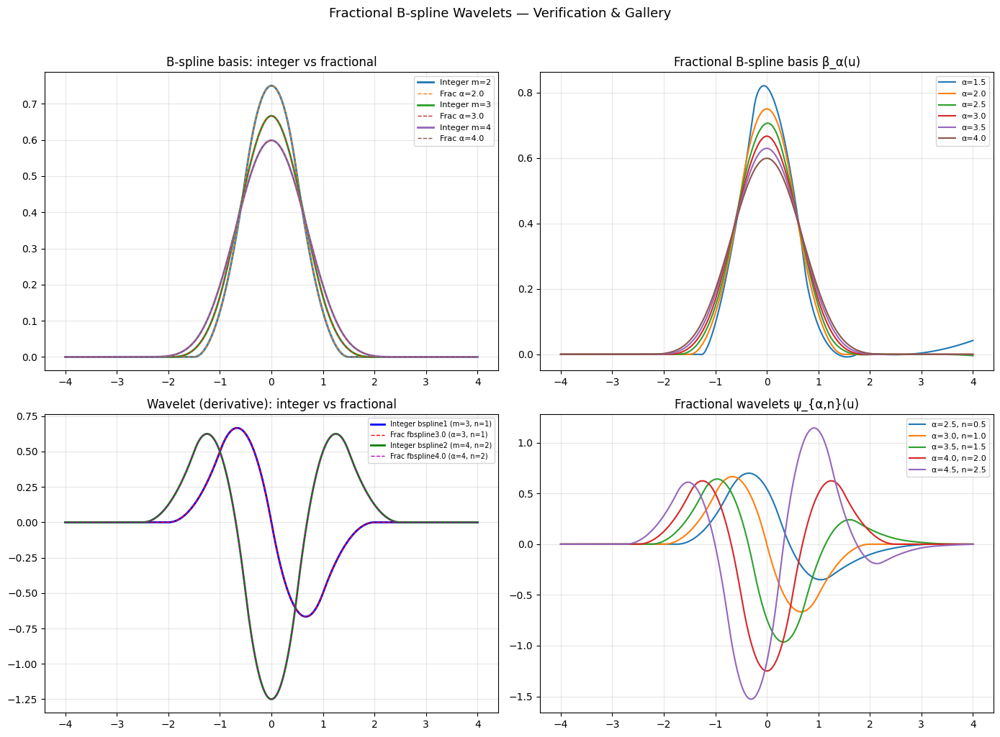

Registered 'fbspline2.5': fact=10.29, support=[-1.75, 1.75]
Registered 'fbspline3.0': fact=9.00, support=[-2.00, 2.00]
Registered 'fbspline3.5': fact=8.00, support=[-2.25, 2.25]
Registered 'fbspline4.5': fact=6.55, support=[-2.75, 2.75]

CWT with fbspline3.5: shape=(12, 1024), max|W|=8.1036

Integer vs fractional max absolute difference:
  bspline(m=3,n=1) vs frac(α=3.0,n=1.0): 0.00e+00
  bspline(m=4,n=2) vs frac(α=4.0,n=2.0): 0.00e+00
  bspline(m=5,n=3) vs frac(α=5.0,n=3.0): 0.00e+00


In [28]:
# ============================================================
# Fractional B-spline Wavelet Verification
# ============================================================
# Verify that fractional B-splines reduce to integer B-splines
# at integer orders, and visualize fractional wavelets.

import numpy as np
import matplotlib.pyplot as plt
from wtmm.wavelets import (WAVELETS, wavelet_direct,
                            _bspline_centered, _bspline_derivative,
                            _frac_bspline_centered, _frac_bspline_derivative,
                            register_frac_bspline)

u = np.linspace(-4, 4, 1000)

# ── 1. Verify: fractional B-spline matches integer at alpha = 3 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: B-spline basis functions (integer vs fractional)
ax = axes[0, 0]
for m in [2, 3, 4]:
    y_int = _bspline_centered(u, m)
    y_frac = _frac_bspline_centered(u, float(m))
    ax.plot(u, y_int, '-', linewidth=2, label=f'Integer m={m}')
    ax.plot(u, y_frac, '--', linewidth=1, label=f'Frac α={m}.0')
ax.set_title('B-spline basis: integer vs fractional')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Top right: Fractional B-splines at non-integer orders
ax = axes[0, 1]
for alpha in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    y = _frac_bspline_centered(u, alpha)
    ax.plot(u, y, linewidth=1.5, label=f'α={alpha}')
ax.set_title('Fractional B-spline basis β_α(u)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bottom left: Wavelet (derivative) — integer vs fractional
ax = axes[1, 0]
# bspline1: m=3, n=1
y_int = _bspline_derivative(u, 3, 1)
y_frac = _frac_bspline_derivative(u, 3.0, 1.0)
ax.plot(u, y_int, 'b-', linewidth=2, label='Integer bspline1 (m=3, n=1)')
ax.plot(u, y_frac, 'r--', linewidth=1, label='Frac fbspline3.0 (α=3, n=1)')
# bspline2: m=4, n=2
y_int2 = _bspline_derivative(u, 4, 2)
y_frac2 = _frac_bspline_derivative(u, 4.0, 2.0)
ax.plot(u, y_int2, 'g-', linewidth=2, label='Integer bspline2 (m=4, n=2)')
ax.plot(u, y_frac2, 'm--', linewidth=1, label='Frac fbspline4.0 (α=4, n=2)')
ax.set_title('Wavelet (derivative): integer vs fractional')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Bottom right: Fractional wavelets at non-integer orders
ax = axes[1, 1]
for alpha, n_alpha in [(2.5, 0.5), (3.0, 1.0), (3.5, 1.5), (4.0, 2.0), (4.5, 2.5)]:
    y = _frac_bspline_derivative(u, alpha, n_alpha)
    ax.plot(u, y, linewidth=1.5, label=f'α={alpha}, n={n_alpha}')
ax.set_title('Fractional wavelets ψ_{α,n}(u)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Fractional B-spline Wavelets — Verification & Gallery', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Register a few fractional wavelets and verify they work in CWT ──
for alpha in [2.5, 3.0, 3.5, 4.5]:
    name = register_frac_bspline(alpha)
    print(f"Registered '{name}': fact={WAVELETS[name]['fact']:.2f}, "
          f"support=[{WAVELETS[name]['x_min_factor']:.2f}, {WAVELETS[name]['x_max_factor']:.2f}]")

# Quick CWT test with a fractional wavelet
from wtmm.cwt import cwtd_mlx
test_sig = np.random.default_rng(0).normal(size=1024)
coeffs_test, scales_test, _ = cwtd_mlx(test_sig, 1.0, 3, 4, 'fbspline3.5', expo=-1.0)
print(f"\nCWT with fbspline3.5: shape={coeffs_test.shape}, max|W|={np.max(np.abs(coeffs_test)):.4f}")

# ── 3. Quantify integer-fractional agreement ──
print("\nInteger vs fractional max absolute difference:")
for m, n in [(3, 1), (4, 2), (5, 3)]:
    y_int = _bspline_derivative(u, m, n)
    y_frac = _frac_bspline_derivative(u, float(m), float(n))
    print(f"  bspline(m={m},n={n}) vs frac(α={m}.0,n={n}.0): {np.max(np.abs(y_int - y_frac)):.2e}")

# Part 3: Optimal Fractional Order α(q) — Empirical Test

**Key insight**: Since τ(q) is known analytically, each q gives a known target slope.
For each fractional wavelet order α, WTMM produces a measured τ(q). The error
|τ_measured - τ_analytical| at each (q, α) tells us which wavelet order best
recovers each moment.

**If the optimal α shifts with q**, it validates the idea that different singularity
strengths (probed by different q) are better captured by different wavelet orders.
If the optimal α is constant, a single wavelet suffices and the right-tail problem
lies elsewhere.

In [27]:
# ============================================================
# Optimal fractional wavelet order α(q)
# ============================================================
# For each fractional order α, run full WTMM on the log-Poisson
# density and compare measured τ(q) to analytical τ(q).

import numpy as np
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx
from wtmm.extrema import compute_extrep
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper
from wtmm.partition import compute_partition_function
from wtmm.spectra import compute_spectra
from wtmm.wavelets import register_frac_bspline
import time

# ── Use the log-Poisson density from Part 1 (lp_measure) ──
# If not in memory, regenerate:
try:
    _ = lp_measure
except NameError:
    N_LEVELS_LP = 12; N_LP = 2**N_LEVELS_LP
    C1_LP, beta_LP = 0.15, 0.5
    rng = np.random.default_rng(42)
    lam_lp = C1_LP / (-np.log(beta_LP))
    all_w = beta_LP ** rng.poisson(lam_lp, size=2*(N_LP-1)) * np.exp(lam_lp*(1-beta_LP))
    lp_measure = np.ones(N_LP); wi = 0
    for lev in range(N_LEVELS_LP):
        bs = N_LP >> lev; hf = bs >> 1
        for b in range(1 << lev):
            s = b * bs
            lp_measure[s:s+hf] *= max(all_w[wi], 1e-30)
            lp_measure[s+hf:s+bs] *= max(all_w[wi+1], 1e-30)
            wi += 2

# ── Analytical τ(q) ──
C1_LP, beta_LP = 0.15, 0.5
def cascade_tau_lp(q, C1, beta):
    return -1 + q + C1 / np.log(beta) * (beta**q - 1 - q * (beta - 1))

# ── Wavelet orders to test ──
# Integer orders (g-derivatives and bsplines) plus fractional
alpha_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

# Register all fractional wavelets
wavelet_names = []
for alpha in alpha_values:
    # n_alpha = alpha - 2 gives ~C1 continuity (matching bspline convention)
    n_alpha = max(alpha - 2.0, 0.5)  # at least 0.5 vanishing moments
    name = register_frac_bspline(alpha, n_alpha=n_alpha)
    wavelet_names.append(name)
    print(f'  {name}: α={alpha}, n={n_alpha:.1f} vanishing moments')

# Also include g2 as reference
wavelet_names.insert(0, 'g2')
alpha_values.insert(0, None)  # g2 has no alpha, mark separately

# ── WTMM pipeline for each wavelet ──
n_oct, n_voice = 5, 10
a_min = 1.0
q_vals = np.concatenate([np.arange(-3, 0, 0.5), np.arange(0, 8.5, 0.5)])
log2_a_min, log2_a_max = 0.5, 4.0

# Analytical reference: shift by -q for density analysis (h_density = h_measure - 1)
tau_analytical = cascade_tau_lp(q_vals, C1_LP, beta_LP) - q_vals

# Store results: tau_measured[wavelet_idx, q_idx]
tau_all = np.full((len(wavelet_names), len(q_vals)), np.nan)
h_all = np.full((len(wavelet_names), len(q_vals)), np.nan)
D_all = np.full((len(wavelet_names), len(q_vals)), np.nan)

for wi, wname in enumerate(wavelet_names):
    t0 = time.time()
    try:
        coeffs, scales, vr = cwtd_mlx(lp_measure, a_min, n_oct, n_voice, wname, expo=-1.0)
        ea, eo, ei = compute_extrep(coeffs, scales, n_oct, n_voice, a_min,
                                     valid_ranges=vr, dx=1.0, epsilon=1e-6)
        cl, fl = chain_all(ea, eo, n_oct=n_oct, n_voice=n_voice)
        chain_delete_all(ea, eo, ei, cl, fl, n_oct=n_oct, n_voice=n_voice)
        chain_max_wrapper(eo, cl, n_oct=n_oct, n_voice=n_voice, a_min=a_min, expo=1.0)
        pf = compute_partition_function(eo, n_oct, n_voice, a_min, q_vals)
        sp = compute_spectra(pf, log2_a_min, log2_a_max)
        tau_all[wi] = sp['tau_q']
        h_all[wi] = sp['h_q']
        D_all[wi] = sp['D_q']
        dt = time.time() - t0
        print(f'  {wname}: done in {dt:.1f}s, index_max={pf["index_max"]}')
    except Exception as e:
        print(f'  {wname}: FAILED — {e}')

# ── Labels for plotting ──
alpha_labels = ['g2 (n=2)'] + [f'α={a:.1f} (n={max(a-2,0.5):.1f})' for a in alpha_values[1:]]

# ── Panel 1: τ(q) error heatmap ──
tau_err = np.abs(tau_all - tau_analytical[np.newaxis, :])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Heatmap of |τ_measured - τ_analytical|
ax = axes[0]
im = ax.imshow(tau_err, aspect='auto', origin='lower',
               extent=[q_vals[0], q_vals[-1], -0.5, len(wavelet_names)-0.5],
               cmap='hot_r', interpolation='nearest',
               vmin=0, vmax=np.nanpercentile(tau_err, 90))
ax.set_yticks(range(len(wavelet_names)))
ax.set_yticklabels(alpha_labels, fontsize=8)
ax.set_xlabel('q')
ax.set_ylabel('Wavelet')
ax.set_title('|τ_measured(q) − τ_analytical(q)|')
plt.colorbar(im, ax=ax, shrink=0.8)

# Optimal α for each q
ax = axes[1]
best_idx = np.nanargmin(tau_err, axis=0)
# Map to alpha values (g2 gets effective alpha=None, use 2.0 for plotting)
alpha_plot = [2.0] + [a for a in alpha_values[1:]]
best_alpha = np.array([alpha_plot[bi] for bi in best_idx])
ax.plot(q_vals, best_alpha, 'ko-', markersize=5, linewidth=1.5)
ax.axhline(2.0, color='tab:blue', ls='--', lw=0.8, alpha=0.5, label='g2 (α=2)')
ax.set_xlabel('q')
ax.set_ylabel('Optimal α (wavelet order)')
ax.set_title('Best fractional order α*(q)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# D(h) overlay: best per-q vs g2 vs analytical
ax = axes[2]
# g2 D(h)
v = np.isfinite(h_all[0]) & np.isfinite(D_all[0])
ax.plot(h_all[0][v], D_all[0][v], 'o-', color='tab:blue', ms=4, lw=1.5,
        alpha=0.5, label='g2 (fixed α=2)')
# Per-q best: pick h(q) and D(q) from the wavelet that was best for that q
h_best = np.array([h_all[best_idx[qi], qi] for qi in range(len(q_vals))])
D_best = np.array([D_all[best_idx[qi], qi] for qi in range(len(q_vals))])
vb = np.isfinite(h_best) & np.isfinite(D_best)
ax.plot(h_best[vb], D_best[vb], 's-', color='tab:red', ms=5, lw=1.5,
        label='Best α per q')
# Analytical
q_th = np.linspace(-3, 8, 500)
tau_th = cascade_tau_lp(q_th, C1_LP, beta_LP) - q_th  # density shift
h_th = np.gradient(tau_th, q_th)
D_th = q_th * h_th - tau_th
m = D_th > -0.5
ax.plot(h_th[m], D_th[m], 'k-', lw=1, label='Analytical')
ax.axhline(1, color='gray', ls='--', lw=0.5)
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title('D(h): fixed g2 vs per-q optimal α')
ax.set_ylim(-0.3, 1.15)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f'Log-Poisson (C₁={C1_LP}, β={beta_LP}) — Fractional Wavelet Order Optimization',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ──
print(f"\n{'q':>5s}  {'α*(q)':>6s}  {'τ_theory':>9s}  {'τ_best':>9s}  {'τ_g2':>9s}  {'Δ_best':>8s}  {'Δ_g2':>8s}")
for qi, qq in enumerate(q_vals):
    if qq % 1 != 0: continue  # only integer q for readability
    tt = tau_analytical[qi]
    tb = tau_all[best_idx[qi], qi]
    tg = tau_all[0, qi]
    ab = alpha_plot[best_idx[qi]]
    print(f'{qq:5.1f}  {ab:6.1f}  {tt:9.4f}  {tb:9.4f}  {tg:9.4f}  {tb-tt:+8.4f}  {tg-tt:+8.4f}')


  fbspline1.5: α=1.5, n=0.5 vanishing moments
  fbspline2.0: α=2.0, n=0.5 vanishing moments
  fbspline2.5: α=2.5, n=0.5 vanishing moments
  fbspline3.0: α=3.0, n=1.0 vanishing moments
  fbspline3.5: α=3.5, n=1.5 vanishing moments
  fbspline4.0: α=4.0, n=2.0 vanishing moments
  fbspline4.5: α=4.5, n=2.5 vanishing moments
  fbspline5.0: α=5.0, n=3.0 vanishing moments
Total extrema: 9710
  g2: done in 0.3s, index_max=49
Total extrema: 7518
  fbspline1.5: done in 0.7s, index_max=49
Total extrema: 6329
  fbspline2.0: done in 0.7s, index_max=49
Total extrema: 5580
  fbspline2.5: done in 0.8s, index_max=49
Total extrema: 4107
  fbspline3.0: done in 0.9s, index_max=49
Total extrema: 6037


KeyboardInterrupt: 

# Part 4: Iterative Fractional Order Optimization α*(q)

For each randomly sampled q value:
1. Compute the analytical target slope τ_target(q) from the log-Poisson formula
2. Define a cost function: f(α) = |τ_measured(α, q) − τ_target(q)|
3. Optimize α using scipy.optimize.minimize_scalar

This finds the continuous optimal fractional wavelet order α*(q) for each q,
rather than searching a discrete grid.

In [26]:
# ============================================================
# Iterative Fractional Order Optimization α*(q)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from wtmm.cwt import cwtd_mlx
from wtmm.extrema import compute_extrep
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper
from wtmm.partition import compute_partition_function
from wtmm.spectra import compute_spectra
from wtmm.wavelets import register_frac_bspline, WAVELETS
import time

# -- Regenerate log-Poisson density if needed --
try:
    _ = lp_measure
except NameError:
    N_LEVELS_LP = 12; N_LP = 2**N_LEVELS_LP
    C1_LP, beta_LP = 0.15, 0.5
    rng = np.random.default_rng(42)
    lam_lp = C1_LP / (-np.log(beta_LP))
    all_w = beta_LP ** rng.poisson(lam_lp, size=2*(N_LP-1)) * np.exp(lam_lp*(1-beta_LP))
    lp_measure = np.ones(N_LP); wi = 0
    for lev in range(N_LEVELS_LP):
        bs = N_LP >> lev; hf = bs >> 1
        for b in range(1 << lev):
            s = b * bs
            lp_measure[s:s+hf] *= max(all_w[wi], 1e-30)
            lp_measure[s+hf:s+bs] *= max(all_w[wi+1], 1e-30)
            wi += 2

# -- Analytical tau(q) for the density --
C1_LP, beta_LP = 0.15, 0.5
def cascade_tau_lp(q, C1, beta):
    return -1 + q + C1 / np.log(beta) * (beta**q - 1 - q * (beta - 1))

def tau_target(q):
    """Analytical tau for WTMM on the density (measure tau shifted by -q)."""
    return cascade_tau_lp(q, C1_LP, beta_LP) - q

# -- WTMM pipeline as a callable --
n_oct, n_voice = 5, 10
a_min = 1.0
log2_a_min, log2_a_max = 0.5, 4.0

_wtmm_cache = {}  # wavelet_name -> pf dict

def run_wtmm(wname, q_list):
    """Full WTMM pipeline, cached by wavelet name."""
    if wname not in _wtmm_cache:
        coeffs, scales, vr = cwtd_mlx(lp_measure, a_min, n_oct, n_voice, wname, expo=-1.0)
        ea, eo, ei = compute_extrep(coeffs, scales, n_oct, n_voice, a_min,
                                     valid_ranges=vr, dx=1.0, epsilon=1e-6)
        cl, fl = chain_all(ea, eo, n_oct=n_oct, n_voice=n_voice)
        chain_delete_all(ea, eo, ei, cl, fl, n_oct=n_oct, n_voice=n_voice)
        chain_max_wrapper(eo, cl, n_oct=n_oct, n_voice=n_voice, a_min=a_min, expo=1.0)
        pf = compute_partition_function(eo, n_oct, n_voice, a_min, q_list)
        _wtmm_cache[wname] = pf
    return compute_spectra(_wtmm_cache[wname], log2_a_min, log2_a_max)

# -- Random q samples --
rng_q = np.random.default_rng(123)
n_q_samples = 20
q_samples = np.sort(rng_q.uniform(-2, 7, size=n_q_samples))
q_list_dense = np.linspace(-3, 8, 100)  # dense grid for partition function

# -- For each q, optimize alpha --
alpha_range = (1.5, 6.0)
alpha_star = np.full(n_q_samples, np.nan)
tau_star = np.full(n_q_samples, np.nan)
tau_targets = np.array([tau_target(q) for q in q_samples])
n_evals_total = 0

print(f'Optimizing alpha*(q) for {n_q_samples} random q values')
print(f'alpha search range: [{alpha_range[0]}, {alpha_range[1]}]')
print(f'{"q":>6s}  {"tau_tgt":>9s}  {"alpha*":>6s}  {"tau_meas":>9s}  {"err":>8s}  {"evals":>5s}')
print('-' * 52)

t_total = time.time()

for iq, q_val in enumerate(q_samples):
    target = tau_targets[iq]
    counter = [0]  # mutable container for closure

    def cost(alpha, _q=q_val, _tgt=target, _ctr=counter):
        _ctr[0] += 1
        n_alpha = max(alpha - 2.0, 0.5)
        name = register_frac_bspline(alpha, n_alpha=n_alpha,
                                      name=f'_opt_{alpha:.6f}')
        _wtmm_cache.pop(name, None)
        sp = run_wtmm(name, q_list_dense)
        tau_meas = np.interp(_q, q_list_dense, sp['tau_q'])
        del WAVELETS[name]
        _wtmm_cache.pop(name, None)
        return abs(tau_meas - _tgt)

    result = minimize_scalar(cost, bounds=alpha_range, method='bounded',
                             options={'xatol': 0.05, 'maxiter': 15})

    alpha_star[iq] = result.x
    n_evals_total += counter[0]

    # Get tau at optimal alpha
    n_opt = max(result.x - 2.0, 0.5)
    opt_name = register_frac_bspline(result.x, n_alpha=n_opt, name='_opt_final')
    _wtmm_cache.pop(opt_name, None)
    sp_opt = run_wtmm(opt_name, q_list_dense)
    tau_star[iq] = np.interp(q_val, q_list_dense, sp_opt['tau_q'])
    del WAVELETS[opt_name]
    _wtmm_cache.pop(opt_name, None)

    print(f'{q_val:6.2f}  {target:9.4f}  {result.x:6.2f}  {tau_star[iq]:9.4f}  '
          f'{abs(tau_star[iq] - target):8.4f}  {counter[0]:5d}')

dt_total = time.time() - t_total
print(f'\nTotal: {n_evals_total} WTMM evaluations in {dt_total:.0f}s')

# -- g2 reference --
_wtmm_cache.clear()
sp_g2 = run_wtmm('g2', q_list_dense)
tau_g2 = sp_g2['tau_q']
h_g2 = sp_g2['h_q']
D_g2 = sp_g2['D_q']
tau_g2_at_samples = np.interp(q_samples, q_list_dense, tau_g2)

# -- Plots --
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) alpha*(q)
ax = axes[0, 0]
ax.plot(q_samples, alpha_star, 'ko-', markersize=7, linewidth=1.5, label='alpha*(q)')
ax.axhline(2.0, color='tab:blue', ls='--', lw=1, alpha=0.5, label='g2 equiv (alpha=2)')
ax.set_xlabel('q', fontsize=12)
ax.set_ylabel('Optimal alpha', fontsize=12)
ax.set_title('Optimal fractional order alpha*(q)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# (b) tau(q) comparison
ax = axes[0, 1]
ax.plot(q_samples, tau_targets, 'k-', lw=2, label='Analytical')
ax.plot(q_samples, tau_star, 'rs-', ms=6, lw=1.5, label='tau at alpha*(q)')
ax.plot(q_samples, tau_g2_at_samples, 'bo-', ms=5, lw=1, alpha=0.5, label='tau at g2')
ax.set_xlabel('q', fontsize=12); ax.set_ylabel('tau(q)', fontsize=12)
ax.set_title('tau(q): optimized alpha vs fixed g2')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# (c) tau error (log scale)
ax = axes[1, 0]
err_opt = np.abs(tau_star - tau_targets)
err_g2 = np.abs(tau_g2_at_samples - tau_targets)
ax.semilogy(q_samples, err_g2 + 1e-10, 'bo-', ms=5, lw=1, label='g2 error')
ax.semilogy(q_samples, err_opt + 1e-10, 'rs-', ms=6, lw=1.5, label='alpha*(q) error')
ax.set_xlabel('q', fontsize=12)
ax.set_ylabel('|tau_meas - tau_analytical|', fontsize=12)
ax.set_title('tau(q) absolute error')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# (d) D(h): per-q optimal vs g2 vs analytical
ax = axes[1, 1]
v = np.isfinite(h_g2) & np.isfinite(D_g2)
ax.plot(h_g2[v], D_g2[v], 'bo-', ms=4, lw=1, alpha=0.5, label='g2 (fixed)')
# Collect h, D from each optimal wavelet at its q
h_opt = np.full(n_q_samples, np.nan)
D_opt = np.full(n_q_samples, np.nan)
_wtmm_cache.clear()
for iq in range(n_q_samples):
    alpha = alpha_star[iq]
    n_a = max(alpha - 2.0, 0.5)
    nm = register_frac_bspline(alpha, n_alpha=n_a, name=f'_dh_{iq}')
    sp_i = run_wtmm(nm, q_list_dense)
    h_opt[iq] = np.interp(q_samples[iq], q_list_dense, sp_i['h_q'])
    D_opt[iq] = np.interp(q_samples[iq], q_list_dense, sp_i['D_q'])
    del WAVELETS[nm]
    _wtmm_cache.pop(nm, None)
vb = np.isfinite(h_opt) & np.isfinite(D_opt)
ax.plot(h_opt[vb], D_opt[vb], 'rs-', ms=6, lw=1.5, label='alpha*(q) per q')
# Analytical
q_th = np.linspace(-3, 8, 500)
tau_th = cascade_tau_lp(q_th, C1_LP, beta_LP) - q_th
h_th = np.gradient(tau_th, q_th)
D_th = q_th * h_th - tau_th
m = D_th > -0.5
ax.plot(h_th[m], D_th[m], 'k-', lw=1.5, label='Analytical')
ax.axhline(1, color='gray', ls='--', lw=0.5)
ax.set_xlabel('h', fontsize=12); ax.set_ylabel('D(h)', fontsize=12)
ax.set_title('D(h): per-q optimal alpha vs fixed g2')
ax.set_ylim(-0.3, 1.15)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle(f'Log-Poisson (C1={C1_LP}, beta={beta_LP}) — Iterative alpha*(q) Optimization',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

_wtmm_cache.clear()


Optimizing alpha*(q) for 20 random q values
alpha search range: [1.5, 6.0]
     q    tau_tgt  alpha*   tau_meas       err  evals
----------------------------------------------------
Total extrema: 5127
Total extrema: 6606
Total extrema: 5440
Total extrema: 5963


KeyboardInterrupt: 

# Part 5: Borges 2004 q-Mexican Hat Wavelets

From Borges, Tsallis, Miranda & Andrade (2004), J. Phys. A 37, 9125:

$$\psi_q(x) = A_q [1 - (3-q)\beta x^2] [e_q^{-\beta x^2}]^q \quad \text{(eq. 16)}$$

This is $d^2/dx^2$ of $[e_q^{-\beta x^2}]^{2-q}$, NOT simply $d^2/dx^2$ of $e_q$.
The $(2-q)$ power ensures proper admissibility for $-1 < q < 3$.

**Key features:**
- $\beta$: width parameter ($\beta=1/2$ recovers standard Mexican hat at $q=1$)
- $A_q$: normalization constant ensuring $||\psi_q||_2 = 1$ (eqs. 17-18)
- Analytical Fourier transform via Bessel $K_\nu$ ($q>1$), $J_{-\nu}$ ($q<1$)
- $q=2$: exact Cauchy-Lorentz FT: $\hat{\psi}_2(y) = A_2 \sqrt{\pi}/(\sqrt{2}\beta) |y| e^{-|y|/\sqrt{\beta}}$
- $q \to 3$: Dirac $\delta$; $q \to -1$: flat distribution

/Users/amasaryk/projects/Creep/wavelet/wtmm/wavelets.py:549: RuntimeWarning: invalid value encountered in scalar divide
  np.sqrt((1.0 - q)**0.5 * gamma_func(arg2 + 1.5) / gamma_func(arg2 + 1.0))
/Users/amasaryk/projects/Creep/wavelet/wtmm/wavelets.py:541: RuntimeWarning: invalid value encountered in scalar divide
  np.sqrt((q - 1.0)**2.5 * gamma_func(arg1) / gamma_func(arg1 - 2.5))


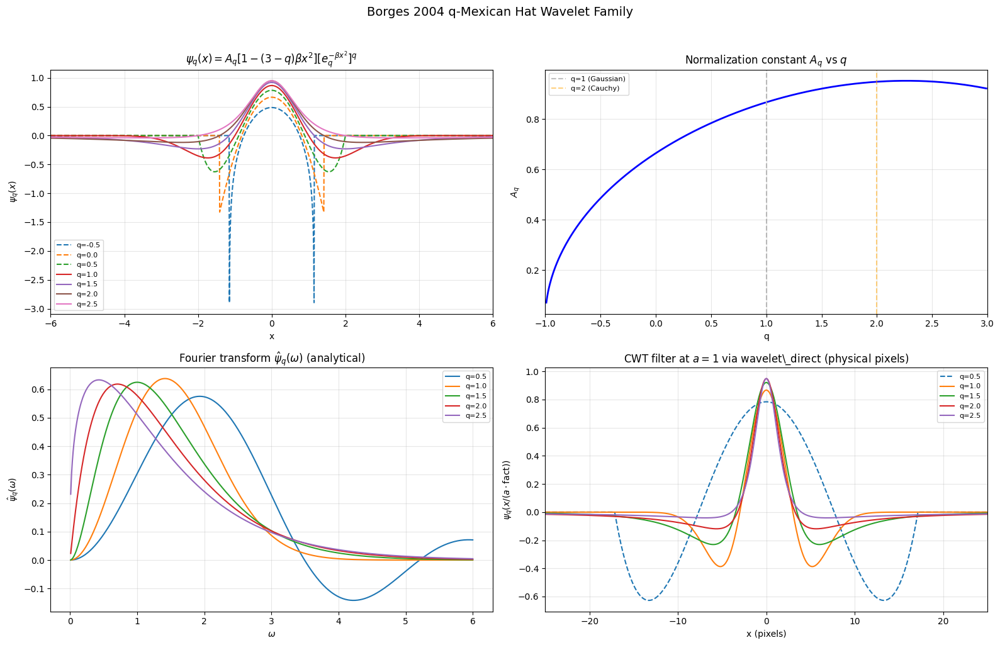

Admissibility (zero mean) and normalization:
  q= -0.5: integral=-5.70e-03, ||psi||_2=1.007985
  q=  0.0: integral=+5.49e-04, ||psi||_2=0.999635
  q=  0.5: integral=-2.61e-07, ||psi||_2=1.000000
  q=  1.0: integral=+1.19e-16, ||psi||_2=1.000000
  q=  1.5: integral=+2.95e-05, ||psi||_2=1.000000
  q=  2.0: integral=+3.79e-02, ||psi||_2=0.999999
  q=  2.5: integral=+4.96e-01, ||psi||_2=0.999959

Fourier transform: analytical vs numerical (ratio at omega=1):
  q=0.5: numerical=+0.304886, analytical=+0.304016, ratio=1.002861
  q=1.0: numerical=+0.527047, analytical=+0.526059, ratio=1.001878
  q=1.5: numerical=+0.625085, analytical=+0.625087, ratio=0.999996
  q=2.0: numerical=+0.577781, analytical=+0.578232, ratio=0.999219
  q=2.5: numerical=+0.510892, analytical=+0.511468, ratio=0.998874

Registered q-Mexican hat wavelets:
  qmhat_q1.0: fact=3.00, support=[-6.00, 6.00]
  qmhat_q1.3: fact=3.52, support=[-5.11, 5.11]
  qmhat_q1.5: fact=3.00, support=[-6.00, 6.00]
  qmhat_q2.0: fact=2.30, supp

In [29]:
# ============================================================
# Borges 2004 q-Mexican Hat — Visualization, FT Validation & CWT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from wtmm.wavelets import (_q_mexican_hat, _q_mexican_hat_fourier,
                            _borges_normalization, register_q_mexican_hat,
                            wavelet_direct, WAVELETS)

u = np.linspace(-8, 8, 2000)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) q-Mexican hat wavelets for different q
ax = axes[0, 0]
for qt in [-0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5]:
    y = _q_mexican_hat(u, qt, beta=0.5)
    style = '-' if qt >= 1 else '--'
    ax.plot(u, y, style, lw=1.5, label=f'q={qt}')
ax.set_title(r'$\psi_q(x) = A_q[1-(3-q)\beta x^2][e_q^{-\beta x^2}]^q$')
ax.set_xlabel('x'); ax.set_ylabel(r'$\psi_q(x)$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(-6, 6)

# (b) Normalization constant A_q vs q
ax = axes[0, 1]
q_range = np.linspace(-0.99, 2.99, 500)
A_vals = []
for q in q_range:
    try:
        A_vals.append(_borges_normalization(q, 0.5))
    except:
        A_vals.append(np.nan)
ax.plot(q_range, A_vals, 'b-', lw=2)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='q=1 (Gaussian)')
ax.axvline(2.0, color='orange', ls='--', alpha=0.5, label='q=2 (Cauchy)')
ax.set_title(r'Normalization constant $A_q$ vs $q$')
ax.set_xlabel('q'); ax.set_ylabel(r'$A_q$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 3)

# (c) Fourier transforms: analytical vs numerical FFT
ax = axes[1, 0]
for qt in [0.5, 1.0, 1.5, 2.0, 2.5]:
    omega = np.linspace(0.01, 6, 500)
    ft_ana = _q_mexican_hat_fourier(omega, qt, beta=0.5)
    ax.plot(omega, ft_ana, lw=1.5, label=f'q={qt}')
ax.set_title(r'Fourier transform $\hat{\psi}_q(\omega)$ (analytical)')
ax.set_xlabel(r'$\omega$'); ax.set_ylabel(r'$\hat{\psi}_q(\omega)$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (d) Physical-space wavelet filters at scale a=1 for different q
# Uses wavelet_direct to show the actual CWT filter shape (including fact scaling).
# All q values probe comparable spatial extents because fact adapts to each q's support.
ax = axes[1, 1]
q_vals = [0.5, 1.0, 1.5, 2.0, 2.5]
x_phys = np.linspace(-25, 25, 2000)
for qt in q_vals:
    name = register_q_mexican_hat(qt, beta=0.5, name=f'_viz_q{qt}')
    y = wavelet_direct(x_phys, a=1.0, wavelet_name=name)
    style = '-' if qt >= 1 else '--'
    ax.plot(x_phys, y, style, lw=1.5, label=f'q={qt}')
    del WAVELETS[name]
ax.set_title(r'CWT filter at $a=1$ via wavelet\_direct (physical pixels)')
ax.set_xlabel('x (pixels)'); ax.set_ylabel(r'$\psi_q(x/(a \cdot \mathrm{fact}))$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(-25, 25)

plt.suptitle('Borges 2004 q-Mexican Hat Wavelet Family', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# -- Admissibility and normalization check --
print('Admissibility (zero mean) and normalization:')
u_wide = np.linspace(-100, 100, 200000)
for qt in [-0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5]:
    psi = _q_mexican_hat(u_wide, qt, beta=0.5)
    integral = np.trapezoid(psi, u_wide)
    norm2 = np.sqrt(np.trapezoid(psi**2, u_wide))
    print(f'  q={qt:5.1f}: integral={integral:+.2e}, ||psi||_2={norm2:.6f}')

# -- Fourier transform validation --
print('\nFourier transform: analytical vs numerical (ratio at omega=1):')
for qt in [0.5, 1.0, 1.5, 2.0, 2.5]:
    N = 131072; dx = 0.01
    x = (np.arange(N) - N//2) * dx
    psi = _q_mexican_hat(x, qt, beta=0.5)
    psi_hat = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(psi))) * dx / np.sqrt(2*np.pi)
    freqs = np.fft.fftshift(np.fft.fftfreq(N, d=dx)) * 2 * np.pi
    idx = np.argmin(np.abs(freqs - 1.0))
    num_val = psi_hat[idx].real
    ana_val = _q_mexican_hat_fourier(np.array([1.0]), qt, beta=0.5)[0]
    print(f'  q={qt}: numerical={num_val:+.6f}, analytical={ana_val:+.6f}, '
          f'ratio={num_val/ana_val:.6f}')

# -- Register and CWT test --
print('\nRegistered q-Mexican hat wavelets:')
for qt in [1.0, 1.3, 1.5, 2.0, 2.5]:
    name = register_q_mexican_hat(qt, beta=0.5)
    w = WAVELETS[name]
    print(f'  {name}: fact={w["fact"]:.2f}, support=[{w["x_min_factor"]:.2f}, {w["x_max_factor"]:.2f}]')

from wtmm.cwt import cwtd_mlx
test_sig = np.random.default_rng(42).normal(size=1024)
print('\nCWT smoke test:')
for qt in [1.0, 1.5, 2.0]:
    name = register_q_mexican_hat(qt, beta=0.5, name=f'_qtest_{qt}')
    coeffs, scales, _ = cwtd_mlx(test_sig, 1.0, 3, 4, name, expo=-1.0)
    print(f'  q={qt}: shape={coeffs.shape}, max|W|={np.max(np.abs(coeffs)):.4f}')
    del WAVELETS[name]

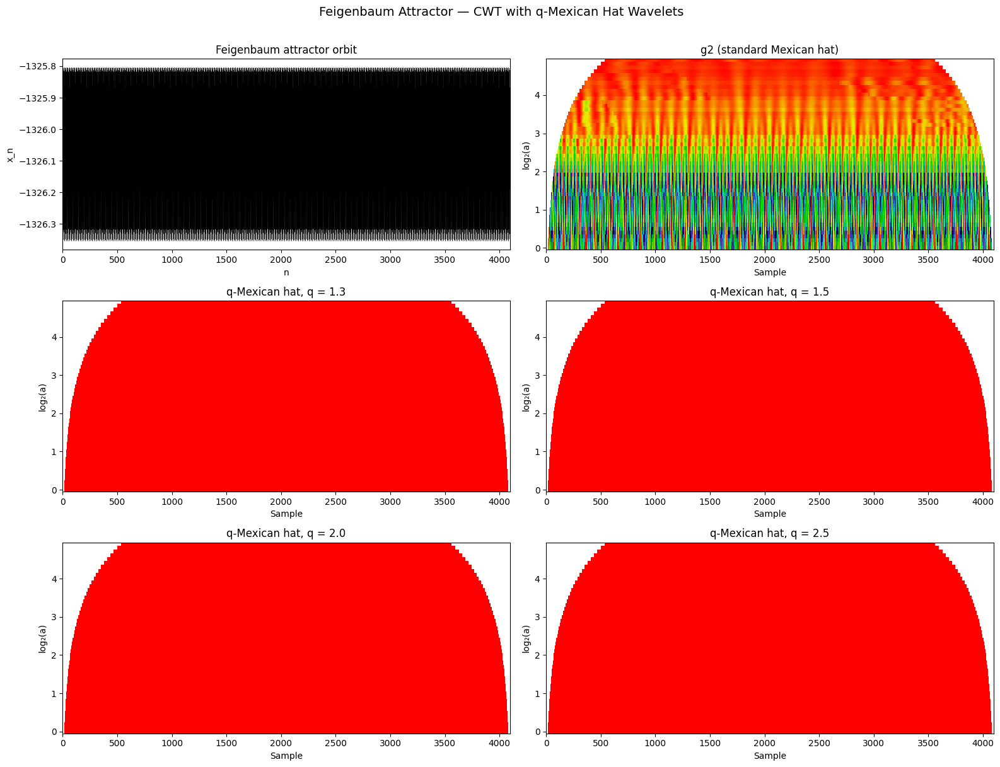

Signal length: 4096
Scales: 50 (1.00 to 29.86)
      g2: coeff shape=(50, 4096), max|W|=0.160163
     1.3: coeff shape=(50, 4096), max|W|=225.313217
     1.5: coeff shape=(50, 4096), max|W|=456.014099
     2.0: coeff shape=(50, 4096), max|W|=1451.249268
     2.5: coeff shape=(50, 4096), max|W|=2873.052246


In [21]:
# ============================================================
# Feigenbaum Attractor CWT with q-Mexican Hat Wavelets
# ============================================================
# Only q > 1 (heavy-tailed) — compact support (q < 1) creates
# spurious extrema at the support boundary.

import numpy as np
import matplotlib.pyplot as plt
from wtmm.wavelets import register_q_mexican_hat, WAVELETS
from wtmm.cwt import cwtd_mlx
from wtmm.colormaps import scalogram_lastwave

# --- 1. Generate Feigenbaum attractor ---
orbit = feigenbaum_orbit(N_pts=2**12)
sig_f = np.cumsum(orbit)  # integrate the measure
sig -= sig_f.mean()     # zero-mean for CWT
SIZE_f = len(sig)
# --- 2. Register q-Mexican hat wavelets (q > 1 only) ---
q_vals = [1.3, 1.5, 2.0, 2.5]
wavelet_names = {}
for qt in q_vals:
    wavelet_names[qt] = register_q_mexican_hat(qt, beta=0.5)

# --- 3. CWT parameters ---
a_min, n_oct, n_voice, expo = 1.0, 5, 10, -1.0

# --- 4. Compute CWTs ---
cwt_results = {}

# Reference g2
coeffs_g2, scales_g2, vr_g2 = cwtd_mlx(sig, a_min, n_oct, n_voice, 'g2', expo)
cwt_results['g2'] = (coeffs_g2, scales_g2, vr_g2)

for qt in q_vals:
    coeffs, scales, vr = cwtd_mlx(sig, a_min, n_oct, n_voice, wavelet_names[qt], expo)
    cwt_results[qt] = (coeffs, scales, vr)

# --- 5. Plot 3x2 grid ---
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# (0,0) Time series
ax = axes[0, 0]
ax.plot(sig, 'k-', lw=0.3)
ax.set_title('Feigenbaum attractor orbit')
ax.set_xlabel('n'); ax.set_ylabel('x_n')
ax.set_xlim(0, len(sig))

# (0,1) g2 reference scalogram
coeffs, scales, vr = cwt_results['g2']
scalogram_lastwave(coeffs, scales, ax=axes[0, 1],
                   norm_mode='lglobal', causal_ranges=vr)
axes[0, 1].set_title('g2 (standard Mexican hat)')

# q-Mexican hat scalograms
positions = [(1, 0), (1, 1), (2, 0), (2, 1)]
for (row, col), qt in zip(positions, q_vals):
    coeffs, scales, vr = cwt_results[qt]
    scalogram_lastwave(coeffs, scales, ax=axes[row, col],
                       norm_mode='lglobal', causal_ranges=vr)
    axes[row, col].set_title(f'q-Mexican hat, q = {qt}')

plt.suptitle('Feigenbaum Attractor — CWT with q-Mexican Hat Wavelets',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- 6. Summary ---
print(f'Signal length: {len(sig)}')
print(f'Scales: {len(scales_g2)} ({scales_g2[0]:.2f} to {scales_g2[-1]:.2f})')
for label, (c, s, vr) in cwt_results.items():
    print(f'  {str(label):>6s}: coeff shape={c.shape}, max|W|={np.max(np.abs(c)):.6f}')

# Clean up temporary registrations
for qt in q_vals:
    if wavelet_names[qt] in WAVELETS:
        del WAVELETS[wavelet_names[qt]]

Total extrema: 18137
g2: 1022 chains, deleted 3055, 0.02s


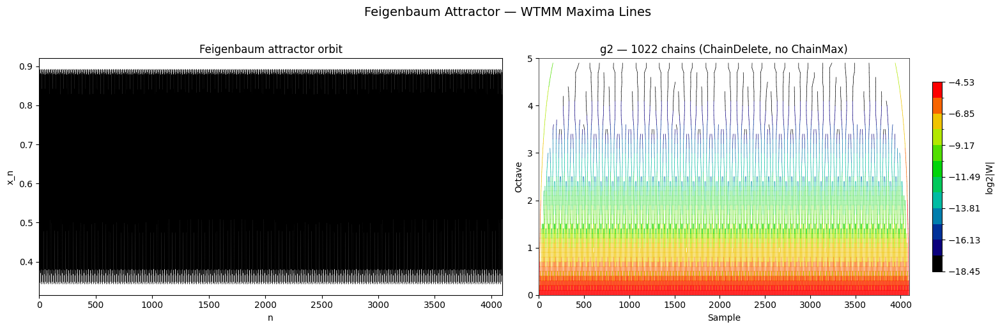

In [18]:
# ============================================================
# Feigenbaum Attractor — WTMM Maxima Lines (ChainDelete, no ChainMax)
# ============================================================
# g2 only — verify pipeline works before adding q-wavelets.

import numpy as np, time
import matplotlib.pyplot as plt
from wtmm.cwt import cwtd_mlx
from wtmm.extrema import compute_extrep
from wtmm.chains import chain_all, chain_delete_all, trace_chains
from wtmm.colormaps import lastwave_colormap

# --- 1. Generate Feigenbaum attractor ---
sig = feigenbaum_orbit(N_pts=2**12)
SIZE = len(sig)

# --- 2. Pipeline parameters ---
a_min, n_oct, n_voice, expo = 1.0, 5, 10, -1.0
n_scales = n_oct * n_voice

# --- 3. CWT ---
coeffs, scales, vr = cwtd_mlx(sig, a_min, n_oct, n_voice, 'g2', expo)

# --- 4. Extrema detection (dx=1.0 so positions are in sample units) ---
extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct, n_voice, a_min, valid_ranges=vr, dx=1.0)

# --- 5. Chain + ChainDelete (no ChainMax) ---
t0 = time.time()
cl, fl = chain_all(extrep_abs, extrep_ord, n_oct=n_oct, n_voice=n_voice)
nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           cl, fl, n_oct=n_oct, n_voice=n_voice)
chains_raw = trace_chains(extrep_abs, extrep_ord, cl, scales, n_scales)

# Convert tuples to dicts matching extract_chains() format
chains = [{'x': np.array(pos), 'log2_a': np.array(sv), 'val': np.array(ords)}
          for pos, sv, sign, ords in chains_raw]

print(f'g2: {len(chains)} chains, deleted {nb_del}, {time.time()-t0:.2f}s')

# --- 6. Plot ---
N_COLORS = 12
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series
ax = axes[0]
ax.plot(sig, 'k-', lw=0.3)
ax.set_title('Feigenbaum attractor orbit')
ax.set_xlabel('n'); ax.set_ylabel('x_n')
ax.set_xlim(0, SIZE)

# Maxima lines (exact same pattern as CELL 5)
ax = axes[1]
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains])
vmin, vmax = np.percentile(all_log2_vals, [2, 98])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W|', shrink=0.8)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'g2 — {len(chains)} chains (ChainDelete, no ChainMax)')

plt.suptitle('Feigenbaum Attractor — WTMM Maxima Lines',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Filter chains: remove those outside the coarsest-scale valid range
# ============================================================
# Use the coarsest scale's (firstp, lastp) as a global x-position cutoff.
# This removes all chains near the edges — including short ones that only
# exist due to boundary artifacts.

firstp_max, lastp_max = vr[-1]  # most restrictive valid range
print(f'Coarsest-scale valid range: [{firstp_max}, {lastp_max}] '
      f'(excluding {firstp_max} + {SIZE - 1 - lastp_max} edge samples)')

chains_coi = [ch for ch in chains if firstp_max <= ch['x'][0] <= lastp_max]
n_removed = len(chains) - len(chains_coi)
print(f'Removed {n_removed} COI-contaminated chains, {len(chains_coi)} remain')

# --- Plot comparison ---
N_COLORS = 12
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax_idx, (ch_list, title) in enumerate([
    (chains, f'Before COI filter ({len(chains)} chains)'),
    (chains_coi, f'After COI filter ({len(chains_coi)} chains)'),
]):
    ax = axes[ax_idx]
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in ch_list])
    vmin, vmax = np.percentile(all_log2_vals, [2, 98])
    boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
    norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
    cmap = lastwave_colormap(N_COLORS)
    for ch in ch_list:
        log2_v = np.log2(np.abs(ch['val']) + 1e-300)
        for j in range(len(ch['x']) - 1):
            ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=0.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label='log2|W|', shrink=0.8)
    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, n_oct)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Octave')
    ax.set_yticks(range(0, n_oct + 1))
    ax.set_title(title)

plt.suptitle('Feigenbaum — COI Chain Filtering', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Total extrema: 34672
Pipeline: deleted 21338 chains, remaining extrema: 13334


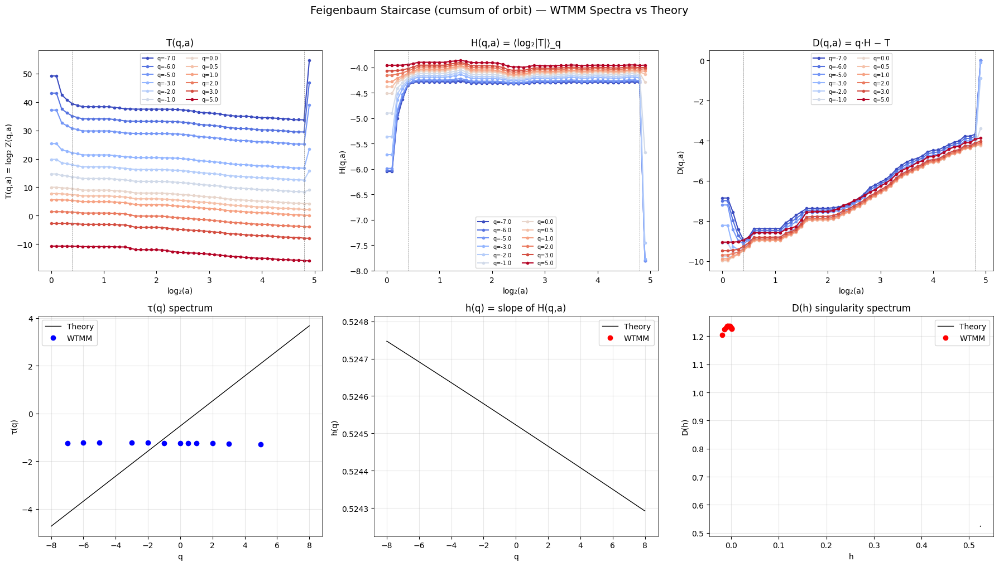


Regression range: log₂(a) ∈ [0.4, 4.8]

    q    τ_WTMM  τ_theory     diff    h_WTMM  h_theory
 -7.0   -1.2324   -4.1969  +2.9645    0.0006    0.5247
 -6.0   -1.2317   -3.6722  +2.4405    0.0008    0.5247
 -5.0   -1.2308   -3.1475  +1.9167    0.0009    0.5247
 -3.0   -1.2298   -2.0982  +0.8684   -0.0001    0.5246
 -2.0   -1.2305   -1.5736  +0.3431   -0.0014    0.5246
 -1.0   -1.2327   -1.0490  -0.1837   -0.0032    0.5246
  0.0   -1.2371   -0.5245  -0.7126   -0.0056    0.5245
  0.5   -1.2403   -0.2623  -0.9780   -0.0070    0.5245
  1.0   -1.2441   -0.0000  -1.2441   -0.0084    0.5245
  2.0   -1.2540    0.5245  -1.7785   -0.0113    0.5245
  3.0   -1.2667    1.0489  -2.3157   -0.0141    0.5244
  5.0   -1.2999    2.0977  -3.3977   -0.0188    0.5244


In [25]:
# ============================================================
# Feigenbaum Attractor — Partition Functions & D(h) Spectrum
# ============================================================
# The Feigenbaum orbit is measure-like — integrate it (cumsum) to get
# a "staircase" before WTMM, same as devil's staircase pipeline.
# CWT with expo=-1 on the staircase recovers the measure's tau(q).

import numpy as np, time
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from wtmm.cwt import cwtd_mlx
from wtmm.extrema import compute_extrep
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import compute_spectra

# --- 1. Generate Feigenbaum "staircase" (cumulative integral of orbit) ---
orbit = feigenbaum_orbit(N_pts=2**12)
sig_f = np.cumsum(orbit)  # integrate the measure
sig_f -= sig_f.mean()     # zero-mean for CWT
SIZE_f = len(sig_f)

# --- 2. Full WTMM pipeline ---
a_min_f, n_oct_f, n_voice_f, expo_f = 1.0, 5, 10, -1.0
n_scales_f = n_oct_f * n_voice_f

coeffs_f, scales_f, vr_f = cwtd_mlx(sig_f, a_min_f, n_oct_f, n_voice_f, 'g2', expo_f)
ea_f, eo_f, ei_f = compute_extrep(
    coeffs_f, scales_f, n_oct_f, n_voice_f, a_min_f, valid_ranges=vr_f, dx=1.0)
cl_f, fl_f = chain_all(ea_f, eo_f, n_oct=n_oct_f, n_voice=n_voice_f)
nb_del_f = chain_delete_all(ea_f, eo_f, ei_f, cl_f, fl_f,
                             n_oct=n_oct_f, n_voice=n_voice_f)
chain_max_wrapper(eo_f, cl_f, n_oct=n_oct_f, n_voice=n_voice_f,
                  a_min=a_min_f, expo=1.0)
print(f'Pipeline: deleted {nb_del_f} chains, remaining extrema: {sum(len(a) for a in ea_f)}')

# --- 3. Partition function ---
q_list_f = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]
pf_f = compute_partition_function(eo_f, n_oct=n_oct_f, n_voice=n_voice_f,
                                   a_min=a_min_f, q_list=q_list_f)

# --- 4. Spectra ---
log2_a_min_f, log2_a_max_f = 0.4, 4.8
spectra_f = compute_spectra(pf_f, log2_a_min=log2_a_min_f, log2_a_max=log2_a_max_f)

# --- 5. Analytical Feigenbaum ---
def cantor_tau(r, p, q_arr):
    r, p = np.asarray(r, float), np.asarray(p, float)
    tau_out = np.empty_like(q_arr, dtype=float)
    for i, qq in enumerate(q_arr):
        def eq(tau, qq=qq):
            return np.sum(p ** qq * r ** (-tau)) - 1.0
        tau_out[i] = brentq(eq, -50, 50)
    return tau_out

def legendre(tau, q):
    h = np.gradient(tau, q)
    D = q * h - tau
    return h, D

alpha_F = 2.502907875095892
r_feig = [1 / alpha_F**2, 1 / alpha_F]
d_feig = 0.538
p_feig = [r_feig[0]**d_feig, r_feig[1]**d_feig]
p_feig = [pi / sum(p_feig) for pi in p_feig]

q_fine = np.linspace(-8, 8, 500)
tau_theory = cantor_tau(r_feig, p_feig, q_fine)
h_theory, D_theory = legendre(tau_theory, q_fine)

tau_theory_q = cantor_tau(r_feig, p_feig, np.array(spectra_f['q_list']))
h_theory_q, D_theory_q = legendre(tau_theory_q, np.array(spectra_f['q_list']))

# --- 6. Plot: 2 rows x 3 cols ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax_ in axes.flatten():
    for spine in ax_.spines.values():
        spine.set_linewidth(0.5)

log2_a = pf_f['log2_a']
valid = slice(0, pf_f['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list_f)))

# --- Top row: T(q,a), H(q,a), D(q,a) vs log2(a) ---
ax = axes[0, 0]
for i, q in enumerate(pf_f['q_list']):
    y = pf_get_T(pf_f, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log₂(a)'); ax.set_ylabel('T(q,a) = log₂ Z(q,a)')
ax.set_title('T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(log2_a_min_f, color='gray', ls='--', lw=0.5)
ax.axvline(log2_a_max_f, color='gray', ls='--', lw=0.5)

ax = axes[0, 1]
for i, q in enumerate(pf_f['q_list']):
    y = pf_get_H(pf_f, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log₂(a)'); ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = ⟨log₂|T|⟩_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(log2_a_min_f, color='gray', ls='--', lw=0.5)
ax.axvline(log2_a_max_f, color='gray', ls='--', lw=0.5)

ax = axes[0, 2]
for i, q in enumerate(pf_f['q_list']):
    y = pf_get_D(pf_f, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log₂(a)'); ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q·H − T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(log2_a_min_f, color='gray', ls='--', lw=0.5)
ax.axvline(log2_a_max_f, color='gray', ls='--', lw=0.5)

# --- Bottom row: tau(q), h(q), D(h) with theory ---
ax = axes[1, 0]
ax.plot(q_fine, tau_theory, 'k-', lw=1, label='Theory')
ax.plot(spectra_f['q_list'], spectra_f['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q'); ax.set_ylabel('τ(q)')
ax.set_title('τ(q) spectrum')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(q_fine, h_theory, 'k-', lw=1, label='Theory')
ax.plot(spectra_f['q_list'], spectra_f['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q'); ax.set_ylabel('h(q)')
ax.set_title('h(q) = slope of H(q,a)')
ax.legend(); ax.grid(True, alpha=0.3)
h_pad = 0.15 * (h_theory.max() - h_theory.min())
ax.set_ylim(h_theory.min() - h_pad, h_theory.max() + h_pad)

ax = axes[1, 2]
ax.plot(h_theory, D_theory, 'k-', lw=1, label='Theory')
ax.plot(spectra_f['h_q'], spectra_f['D_q'], 'ro', markersize=6, linestyle='none', label='WTMM')
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Feigenbaum Staircase (cumsum of orbit) — WTMM Spectra vs Theory',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Print comparison ---
print(f'\nRegression range: log₂(a) ∈ [{log2_a_min_f}, {log2_a_max_f}]')
print(f'\n{"q":>5s}  {"τ_WTMM":>8s}  {"τ_theory":>8s}  {"diff":>7s}  {"h_WTMM":>8s}  {"h_theory":>8s}')
for i, q in enumerate(spectra_f['q_list']):
    print(f'{q:5.1f}  {spectra_f["tau_q"][i]:8.4f}  {tau_theory_q[i]:8.4f}  '
          f'{spectra_f["tau_q"][i]-tau_theory_q[i]:+7.4f}  '
          f'{spectra_f["h_q"][i]:8.4f}  {h_theory_q[i]:8.4f}')